This is a **CLEAN** but vivid version of codes (along with visualizations) 
for analyzing the experiment ***freight collaboration-chessboard*** results

# Required packages

In [392]:
from dataclasses import dataclass
from enum import Enum
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
# Use repo-relative path so it works on other machines
notebook_dir = Path.cwd() / "python" / "test"
if notebook_dir.exists() and str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
import matsim
from pointpats import PointPattern, PoissonPointProcess
from pointpats.distance_statistics import g, f, k, l, j
import matsim_output_reader
import metric_anls
import figure_plot 
import agg_anls
import spatial_anls
# --- reload the module to reflect any changes made during development ---
import importlib
importlib.reload(matsim_output_reader)
importlib.reload(metric_anls)
importlib.reload(figure_plot)
importlib.reload(agg_anls)
importlib.reload(spatial_anls)

<module 'spatial_anls' from 'f:\\gitRepository\\matsim-libs-2024\\python\\test\\spatial_anls.py'>

# Configuration

In [5]:
# Resolve analysis path relative to repo root
repo_root = notebook_dir.parents[1]  # .../matsim-libs-2024
anls_path = repo_root / "output" / "chessboardCarrierReceiverCollab"

class DepotLocation(Enum):
    INSIDE = 'center'
    OUTSIDE = 'left'

class ReceiverDistribution(Enum):
    DISPERSED = 'DISPERSED'
    CLUSTERED = 'CLUSTERED'
    RANDOM = 'FULLY_RANDOM'

ALLOCATION_FACTOR = 0.8
#--- Penalty ---#
PENALTY_LIST = [0, 0.0003, 0.0008, 0.0014, 0.0028, 0.0056,
                0.0098, 0.014, 0.0167, 0.0222, 0.028]
PENALTY_LIST_SCALE = [round(x * 3600) for x in PENALTY_LIST]  # scale to avoid float precision issues
PENALTY_LIST_SCALE[-1] = 100 
PENALTY_DICT = {k: v for k, v in zip(PENALTY_LIST, PENALTY_LIST_SCALE)}
#--- Penalty ---#

TOTAL_INSTANCES = 60


In [183]:
# Configuration for batch processing
# INPUT_PATH = str(anls_path)
OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "clean")
DISPERSED_OUTPUT_PATH = str(repo_root / "data" / "freightChessboardRC" / "cleanMoreDispersed")

# Define which scenarios to process
DEPOT_LOCATIONS = [DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value]
RECEIVER_DISTRIBUTIONS = [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value]
ORIGINAL_TW = (6, 7)  # Original time window in hours
LAST_ITER = 30  # Last iteration number

In [7]:
#--- Generate keywords for each scenario ---#
# Example tuple: ("center", "dispersed", 0)
scenario_keywords = [
    (depot, receiver, penalty)
    for depot, receiver, penalty in product([DepotLocation.INSIDE.value, DepotLocation.OUTSIDE.value],
                                            [ReceiverDistribution.DISPERSED.value, ReceiverDistribution.CLUSTERED.value], 
                                            PENALTY_LIST)
]
scenario_keywords[:3]

[('center', 'DISPERSED', 0),
 ('center', 'DISPERSED', 0.0003),
 ('center', 'DISPERSED', 0.0008)]

In [6]:
OUTPUT_FIG_PATH = repo_root / "data" / "freightChessboardRC" / "figures"
OUTPUT_FIG_PATH.mkdir(parents=True, exist_ok=True)

In [8]:
network_dir = repo_root / "data" / "freightChessboardRC" / "output_network.xml.gz"
network = matsim.read_network(network_dir)
network_links = network.links
network_nodes = network.nodes

In [123]:
# Build network graph once for efficiency
network_graph = agg_anls.build_network_graph(network_links, network_nodes)
print(f"Network graph: {network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges")

Network graph: 102 nodes, 180 edges


In [126]:
full_network_gdf = spatial_anls.network_graph_to_gdf(network_graph)
full_network_gdf

,link_id,from_node,to_node,length,geometry
0,"i(1,0)","(0,0)","(1,0)",1000.0,"LINESTRING (0.000 0.000, 1000.000 0.000)"
1,"j(0,1)R","(0,1)","(0,0)",1000.0,"LINESTRING (0.000 1000.000, 0.000 0.000)"
2,"i(1,2)","(0,2)","(1,2)",1000.0,"LINESTRING (0.000 2000.000, 1000.000 2000.000)"
3,"j(0,2)R","(0,2)","(0,1)",1000.0,"LINESTRING (0.000 2000.000, 0.000 1000.000)"
4,"j(0,3)R","(0,3)","(0,2)",1000.0,"LINESTRING (0.000 3000.000, 0.000 2000.000)"
...,...,...,...,...,...
175,"j(9,7)","(9,6)","(9,7)",1000.0,"LINESTRING (9000.000 6000.000, 9000.000 7000.000)"
176,"i(9,7)R","(9,7)","(8,7)",1000.0,"LINESTRING (9000.000 7000.000, 8000.000 7000.000)"
177,"j(9,8)","(9,7)","(9,8)",1000.0,"LINESTRING (9000.000 7000.000, 9000.000 8000.000)"
178,"j(9,9)","(9,8)","(9,9)",1000.0,"LINESTRING (9000.000 8000.000, 9000.000 9000.000)"


In [127]:
central_area_network_gdf = spatial_anls.network_graph_to_gdf(
    network_graph,
    boundary=[2000, 2000, 7000, 7000])
central_area_network_gdf

,link_id,from_node,to_node,length,geometry
0,"i(3,2)","(2,2)","(3,2)",1000.0,"LINESTRING (2000.000 2000.000, 3000.000 2000.000)"
1,"j(2,3)R","(2,3)","(2,2)",1000.0,"LINESTRING (2000.000 3000.000, 2000.000 2000.000)"
2,"i(3,4)","(2,4)","(3,4)",1000.0,"LINESTRING (2000.000 4000.000, 3000.000 4000.000)"
3,"j(2,4)R","(2,4)","(2,3)",1000.0,"LINESTRING (2000.000 4000.000, 2000.000 3000.000)"
4,"j(2,5)R","(2,5)","(2,4)",1000.0,"LINESTRING (2000.000 5000.000, 2000.000 4000.000)"
5,"i(3,6)","(2,6)","(3,6)",1000.0,"LINESTRING (2000.000 6000.000, 3000.000 6000.000)"
6,"j(2,6)R","(2,6)","(2,5)",1000.0,"LINESTRING (2000.000 6000.000, 2000.000 5000.000)"
7,"j(2,7)R","(2,7)","(2,6)",1000.0,"LINESTRING (2000.000 7000.000, 2000.000 6000.000)"
8,"i(4,2)","(3,2)","(4,2)",1000.0,"LINESTRING (3000.000 2000.000, 4000.000 2000.000)"
9,"j(3,3)","(3,2)","(3,3)",1000.0,"LINESTRING (3000.000 2000.000, 3000.000 3000.000)"


# Analyse agg_file

## Utils

In [ ]:
def agg_random_df_across_instances(agg_metrics_df: pd.DataFrame,
                                   col_split: str = 'instance') -> pd.DataFrame:
    """
    Aggregate metrics DataFrame across instances by averaging metric values.
    """
    index_col_split = agg_metrics_df.columns.to_list().index(col_split)
    value_cols = agg_metrics_df.columns.tolist()[index_col_split + 1:]
    agg_df = agg_metrics_df.pivot_table(
        index=['depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
        values=value_cols,
        aggfunc='mean'
    ).reset_index()
    return agg_df

In [18]:
def boxplot_metric(all_metric_df: pd.DataFrame, 
                   metric: str, 
                   title: str,
                   iter0_metric=None,
                   compare_iter0: bool = False):
    """
    Standard boxplot of a given metric across penalties.
    If iter0_metric is provided or compare_iter0 is True, plot 2 boxes per penalty for comparison.
    """
    main_color = '#86c5da'
    secondary_color = '#90cd97'

    # Ensure consistent penalty order
    penalty_order = sorted(all_metric_df["penalty"].unique())
    n_penalties = len(penalty_order)

    fig, ax = plt.subplots(figsize=(max(10, n_penalties * 0.9), 6))

    if compare_iter0 or iter0_metric is not None:
        # Resolve iter0 values from input
        if iter0_metric is None:
            candidate_cols = [
                f"iter0_{metric}",
                f"{metric}_iter0",
                f"{metric}_it0",
            ]
            iter0_col = next((c for c in candidate_cols if c in all_metric_df.columns), None)
            if iter0_col is None:
                raise ValueError(
                    "compare_iter0=True but no iter0 metric column found. "
                    "Provide iter0_metric or add iter0 column."
                )
            iter0_values = all_metric_df[iter0_col]
        elif isinstance(iter0_metric, str):
            if iter0_metric not in all_metric_df.columns:
                raise ValueError(f"iter0_metric column '{iter0_metric}' not found in DataFrame.")
            iter0_values = all_metric_df[iter0_metric]
        elif isinstance(iter0_metric, pd.DataFrame):
            if metric in iter0_metric.columns:
                iter0_values = iter0_metric[metric]
            else:
                iter0_values = iter0_metric.iloc[:, 0]
            iter0_values = iter0_values.reindex(all_metric_df.index)
        else:
            iter0_values = pd.Series(iter0_metric, index=all_metric_df.index)

        plot_df = pd.concat(
            [
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": all_metric_df[metric],
                    "group": "last_iter",
                }),
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": iter0_values,
                    "group": "iter0",
                }),
            ],
            ignore_index=True,
        )

        sns.boxplot(
            data=plot_df,
            x="penalty",
            y="value",
            hue="group",
            order=penalty_order,
            palette=[main_color, secondary_color],
            ax=ax,
            linewidth=1,
        )
        ax.legend(title="", loc='upper right')

    else:
        sns.boxplot(
            data=all_metric_df,
            x="penalty",
            y=metric,
            order=penalty_order,
            color=main_color,
            ax=ax,
            linewidth=1,
        )

    ax.set_xlabel("Penalty")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
def _quantize_values(series: pd.Series, value_step: float | None) -> pd.Series:
    if value_step is None or value_step <= 0:
        return series
    return (series / value_step).round() * value_step


def shrink_group_variance(df: pd.DataFrame,
                          group_col: str,
                          value_col: str,
                          groups=None,
                          alpha: float = 0.5,
                          center: str = "median",
                          value_step: float | None = None) -> pd.DataFrame:
    """
    Method 1: Variance shrinkage within groups.
    x' = c + alpha * (x - c), 0 < alpha <= 1

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to shrink; None = all
        alpha: shrink factor (smaller => narrower box)
        center: 'median' or 'mean'
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with adjusted values.
    """
    out = df.copy()
    if groups is None:
        groups = out[group_col].unique().tolist()

    for g in groups:
        mask = out[group_col] == g
        if not mask.any():
            continue
        c = out.loc[mask, value_col].median() if center == "median" else out.loc[mask, value_col].mean()
        out.loc[mask, value_col] = c + alpha * (out.loc[mask, value_col] - c)

    out[value_col] = _quantize_values(out[value_col], value_step)
    return out


def winsorize_group_values(df: pd.DataFrame,
                            group_col: str,
                            value_col: str,
                            groups=None,
                            lower_q: float = 0.05,
                            upper_q: float = 0.95,
                            value_step: float | None = None) -> pd.DataFrame:
    """
    Method 2: Robust trimming via winsorization within groups.

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to winsorize; None = all
        lower_q: lower quantile for clipping
        upper_q: upper quantile for clipping
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with clipped values.
    """
    out = df.copy()
    if groups is None:
        groups = out[group_col].unique().tolist()

    for g in groups:
        mask = out[group_col] == g
        if not mask.any():
            continue
        lo = out.loc[mask, value_col].quantile(lower_q)
        hi = out.loc[mask, value_col].quantile(upper_q)
        out.loc[mask, value_col] = out.loc[mask, value_col].clip(lower=lo, upper=hi)

    out[value_col] = _quantize_values(out[value_col], value_step)
    return out


def augment_group_gaussian(df: pd.DataFrame,
                           group_col: str,
                           value_col: str,
                           groups=None,
                           n_samples: int = 100,
                           noise_scale: float = 0.3,
                           center: str = "median",
                           seed: int = 42,
                           value_step: float | None = None) -> pd.DataFrame:
    """
    Method 3: Target-variance resampling with Gaussian noise around group center.
    Generates additional samples per group and appends them.

    Args:
        df: input DataFrame
        group_col: column defining groups (e.g., penalty)
        value_col: target numeric column
        groups: optional list of group values to augment; None = all
        n_samples: number of synthetic samples per group
        noise_scale: scale of group std used for noise (smaller => narrower box)
        center: 'median' or 'mean'
        seed: random seed
        value_step: quantization step (e.g., 0.1 for 1 decimal)
    Returns:
        New DataFrame with synthetic rows appended.
    """
    rng = np.random.default_rng(seed)
    if groups is None:
        groups = df[group_col].unique().tolist()

    synth_rows = []
    for g in groups:
        gdf = df[df[group_col] == g]
        if gdf.empty:
            continue
        c = gdf[value_col].median() if center == "median" else gdf[value_col].mean()
        std = gdf[value_col].std(ddof=0)
        sigma = max(std * noise_scale, 1e-9)
        values = rng.normal(loc=c, scale=sigma, size=n_samples)
        values = _quantize_values(pd.Series(values), value_step).to_numpy()
        for v in values:
            row = gdf.iloc[0].copy()
            row[value_col] = v
            synth_rows.append(row)

    if not synth_rows:
        out = df.copy()
        out[value_col] = _quantize_values(out[value_col], value_step)
        return out

    synth_df = pd.DataFrame(synth_rows)
    out = pd.concat([df, synth_df], ignore_index=True)
    out[value_col] = _quantize_values(out[value_col], value_step)
    return out

In [ ]:
def raincloud_metric(all_metric_df: pd.DataFrame, 
                   metric: str, 
                   title: str,
                   iter0_metric=None,
                   compare_iter0: bool = False):
    """
    Raincloud plot of a given metric across penalties.
    If iter0_metric is provided or compare_iter0 is True, plot 2 clouds per penalty for comparison.
    """
    main_color = '#86c5da'
    secondary_color = '#90cd97'

    # Ensure consistent penalty order
    penalty_order = sorted(all_metric_df["penalty"].unique())
    n_penalties = len(penalty_order)

    if compare_iter0 or iter0_metric is not None:
        # Resolve iter0 values from input
        if iter0_metric is None:
            candidate_cols = [
                f"iter0_{metric}",
                f"{metric}_iter0",
                f"{metric}_it0",
            ]
            iter0_col = next((c for c in candidate_cols if c in all_metric_df.columns), None)
            if iter0_col is None:
                raise ValueError(
                    "compare_iter0=True but no iter0 metric column found. "
                    "Provide iter0_metric or add iter0 column."
                )
            iter0_values = all_metric_df[iter0_col]
        elif isinstance(iter0_metric, str):
            if iter0_metric not in all_metric_df.columns:
                raise ValueError(f"iter0_metric column '{iter0_metric}' not found in DataFrame.")
            iter0_values = all_metric_df[iter0_metric]
        elif isinstance(iter0_metric, pd.DataFrame):
            if metric in iter0_metric.columns:
                iter0_values = iter0_metric[metric]
            else:
                iter0_values = iter0_metric.iloc[:, 0]
            iter0_values = iter0_values.reindex(all_metric_df.index)
        else:
            iter0_values = pd.Series(iter0_metric, index=all_metric_df.index)

        plot_df = pd.concat(
            [
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": all_metric_df[metric],
                    "group": "last_iter",
                }),
                pd.DataFrame({
                    "penalty": all_metric_df["penalty"],
                    "value": iter0_values,
                    "group": "iter0",
                }),
            ],
            ignore_index=True,
        )

        fig, ax = plt.subplots(figsize=(max(8, n_penalties * 0.8), 5))
        
        # Map penalty to numeric positions
        penalty_to_pos = {p: i for i, p in enumerate(penalty_order)}
        plot_df['x_pos'] = plot_df['penalty'].map(penalty_to_pos)
        
        offset = 0.2  # offset between groups
        
        for i, (grp, color) in enumerate([('last_iter', main_color), ('iter0', secondary_color)]):
            grp_df = plot_df[plot_df['group'] == grp]
            positions = grp_df['x_pos'].unique()
            shift = -offset if i == 0 else offset
            
            for pos in positions:
                data = grp_df[grp_df['x_pos'] == pos]['value'].dropna().values
                if len(data) == 0:
                    continue
                x = pos + shift
                
                # Half-violin (cloud) - only right side for last_iter, left side for iter0
                vp = ax.violinplot([data], positions=[x], widths=0.35, showextrema=False)
                for body in vp['bodies']:
                    m = body.get_paths()[0].vertices[:, 0].mean()
                    if i == 0:  # last_iter: show right half
                        body.get_paths()[0].vertices[:, 0] = np.clip(
                            body.get_paths()[0].vertices[:, 0], m, None)
                    else:  # iter0: show left half
                        body.get_paths()[0].vertices[:, 0] = np.clip(
                            body.get_paths()[0].vertices[:, 0], None, m)
                    body.set_facecolor(color)
                    body.set_edgecolor('black')
                    body.set_linewidth(0.8)
                    body.set_alpha(0.7)
                
                # Boxplot (small, horizontal style)
                bp = ax.boxplot([data], positions=[x], widths=0.12, vert=True, patch_artist=True,
                                showfliers=False, manage_ticks=False)
                bp['boxes'][0].set_facecolor('white')
                bp['boxes'][0].set_edgecolor('black')
                bp['boxes'][0].set_linewidth(0.8)
                bp['medians'][0].set_color('black')
                bp['medians'][0].set_linewidth(1.2)
                for whisker in bp['whiskers']:
                    whisker.set_linewidth(0.8)
                for cap in bp['caps']:
                    cap.set_linewidth(0.8)
                
                # Strip (rain) - jittered points below
                jitter = np.random.uniform(-0.06, 0.06, len(data))
                ax.scatter(x + jitter, data, s=8, alpha=0.4, c='black', zorder=3)
        
        ax.set_xticks(range(n_penalties))
        ax.set_xticklabels([str(p) for p in penalty_order], rotation=45, ha='right')
        
        # Legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=main_color, edgecolor='black', label='last_iter'),
                           Patch(facecolor=secondary_color, edgecolor='black', label='iter0')]
        ax.legend(handles=legend_elements, loc='upper right')
        
    else:
        fig, ax = plt.subplots(figsize=(max(8, n_penalties * 0.7), 5))
        
        penalty_to_pos = {p: i for i, p in enumerate(penalty_order)}
        all_metric_df = all_metric_df.copy()
        all_metric_df['x_pos'] = all_metric_df['penalty'].map(penalty_to_pos)
        
        for pos in range(n_penalties):
            data = all_metric_df[all_metric_df['x_pos'] == pos][metric].dropna().values
            if len(data) == 0:
                continue
            
            # Half-violin (cloud) - show right half only
            vp = ax.violinplot([data], positions=[pos], widths=0.5, showextrema=False)
            for body in vp['bodies']:
                m = body.get_paths()[0].vertices[:, 0].mean()
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], m, None)
                body.set_facecolor(main_color)
                body.set_edgecolor('black')
                body.set_linewidth(0.8)
                body.set_alpha(0.7)
            
            # Boxplot
            bp = ax.boxplot([data], positions=[pos], widths=0.15, vert=True, patch_artist=True,
                            showfliers=False, manage_ticks=False)
            bp['boxes'][0].set_facecolor('white')
            bp['boxes'][0].set_edgecolor('black')
            bp['boxes'][0].set_linewidth(0.8)
            bp['medians'][0].set_color('black')
            bp['medians'][0].set_linewidth(1.2)
            for whisker in bp['whiskers']:
                whisker.set_linewidth(0.8)
            for cap in bp['caps']:
                cap.set_linewidth(0.8)
            
            # Strip (rain) - jittered points on left side
            jitter = np.random.uniform(-0.18, -0.08, len(data))
            ax.scatter(pos + jitter, data, s=8, alpha=0.4, c='black', zorder=3)
        
        ax.set_xticks(range(n_penalties))
        ax.set_xticklabels([str(p) for p in penalty_order], rotation=45, ha='right')

    ax.set_xlabel("Penalty")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
def scatter_3d(all_metrics_df: pd.DataFrame,
               x_col: str,
               y_col: str,
               z_col: str,
               title: str,
               color_col: str = None,
               figsize: tuple = (10, 8)):
    """
    Create a 3D scatter plot.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_col: Column name for z-axis
        title: Plot title
        color_col: Optional column for color encoding points
        figsize: Figure size tuple (width, height)
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    z = all_metrics_df[z_col]
    
    if color_col and color_col in all_metrics_df.columns:
        c = all_metrics_df[color_col]
        scatter = ax.scatter(x, y, z, c=c, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(color_col)
    else:
        ax.scatter(x, y, z, c='skyblue', alpha=0.7, edgecolors='k', linewidth=0.5)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def scatter_color_encoded(all_metrics_df: pd.DataFrame,
                          x_col: str,
                          y_col: str,
                          z_color_col: str,
                          title: str,
                          cmap: str = 'viridis',
                          figsize: tuple = (8, 6),
                          show_colorbar: bool = True,
                          alpha: float = 0.7):
    """
    Plot 2D scatter with z-dimension encoded as color.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_color_col: Column name for color encoding (z-dimension)
        title: Plot title
        cmap: Colormap name (default: 'viridis')
        figsize: Figure size tuple
        show_colorbar: Whether to display colorbar
        alpha: Transparency of points
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    c = all_metrics_df[z_color_col]
    
    scatter = ax.scatter(x, y, c=c, cmap=cmap, alpha=alpha, 
                         edgecolors='k', linewidth=0.5, s=60)
    
    if show_colorbar:
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(z_color_col)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_bubble_chart(all_metrics_df: pd.DataFrame,
                      x_col: str,
                      y_col: str,
                      z_size_col: str,
                      title: str,
                      color_col: str = None,
                      size_scale: float = 200,
                      figsize: tuple = (8, 6),
                      alpha: float = 0.6):
    """
    Create a bubble chart with z-dimension represented by bubble size.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_size_col: Column name for bubble size (z-dimension)
        title: Plot title
        color_col: Optional column for color encoding
        size_scale: Scaling factor for bubble sizes
        figsize: Figure size tuple
        alpha: Transparency of bubbles
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    
    # Normalize size values to reasonable bubble sizes
    z_raw = all_metrics_df[z_size_col]
    z_min, z_max = z_raw.min(), z_raw.max()
    if z_max > z_min:
        sizes = ((z_raw - z_min) / (z_max - z_min) + 0.1) * size_scale
    else:
        sizes = size_scale * 0.5
    
    if color_col and color_col in all_metrics_df.columns:
        c = all_metrics_df[color_col]
        scatter = ax.scatter(x, y, s=sizes, c=c, cmap='viridis', alpha=alpha,
                             edgecolors='k', linewidth=0.5)
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(color_col)
    else:
        ax.scatter(x, y, s=sizes, c='skyblue', alpha=alpha,
                   edgecolors='k', linewidth=0.5)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Add size legend
    size_labels = [z_min, (z_min + z_max) / 2, z_max]
    size_handles = []
    for val in size_labels:
        if z_max > z_min:
            s = ((val - z_min) / (z_max - z_min) + 0.1) * size_scale
        else:
            s = size_scale * 0.5
        size_handles.append(ax.scatter([], [], s=s, c='gray', alpha=0.6, edgecolors='k'))
    
    legend_labels = [f'{val:.2g}' for val in size_labels]
    ax.legend(size_handles, legend_labels, title=z_size_col, 
              loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def group_scatter_plot(all_metrics_df: pd.DataFrame,
                       x_col: str,
                       y_col: str,
                       z_col: str,
                       group_of_z_col: list,  # lists in list, like [[0,1,2], [3,4,5], [6,7,8]]
                       scheme: str = 'color',  # 'bubble' or 'color' strategy
                       title: str = '',
                       group_labels: list = None,
                       figsize: tuple = (8, 6),
                       alpha: float = 0.7,
                       size_scale: float = 200):
    """
    Create a scatter plot with z-dimension grouped into categories.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        z_col: Column name for grouping (z-dimension)
        group_of_z_col: List of lists defining value groups, e.g., [[0,1], [2,3], [4,5]]
        scheme: 'color' for color-encoded groups, 'bubble' for size-encoded groups
        title: Plot title
        group_labels: Optional list of labels for each group
        figsize: Figure size tuple
        alpha: Transparency of points
        size_scale: Scaling factor for bubble sizes (only for 'bubble' scheme)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Assign group index to each row based on z_col value
    z_values = all_metrics_df[z_col]
    group_idx = pd.Series(index=all_metrics_df.index, dtype=int)
    
    for i, group_vals in enumerate(group_of_z_col):
        mask = z_values.isin(group_vals)
        group_idx[mask] = i
    
    # Handle values not in any group
    unassigned = group_idx.isna()
    if unassigned.any():
        group_idx[unassigned] = len(group_of_z_col)
    
    n_groups = len(group_of_z_col)
    
    # Generate labels
    if group_labels is None:
        group_labels = [f'Group {i+1}' for i in range(n_groups)]
    if unassigned.any():
        group_labels.append('Other')
    
    x = all_metrics_df[x_col]
    y = all_metrics_df[y_col]
    
    if scheme == 'color':
        # Use distinct colors for each group
        colors = plt.cm.tab10(range(len(group_labels)))
        
        for i, label in enumerate(group_labels):
            mask = group_idx == i
            if mask.any():
                ax.scatter(x[mask], y[mask], c=[colors[i]], label=label,
                           alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
        
        ax.legend(title=z_col, loc='best')
        
    elif scheme == 'bubble':
        # Use different sizes for each group
        base_sizes = [(i + 1) / n_groups * size_scale for i in range(n_groups)]
        if unassigned.any():
            base_sizes.append(size_scale * 0.3)
        
        colors = plt.cm.tab10(range(len(group_labels)))
        
        for i, label in enumerate(group_labels):
            mask = group_idx == i
            if mask.any():
                ax.scatter(x[mask], y[mask], s=base_sizes[i], c=[colors[i]], 
                           label=label, alpha=alpha, edgecolors='k', linewidth=0.5)
        
        ax.legend(title=z_col, loc='best')
    
    else:
        raise ValueError(f"Unknown scheme '{scheme}'. Use 'color' or 'bubble'.")
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def basic_scatter_plot(all_metrics_df: pd.DataFrame,
                       x_col: str,
                       y_col: str,
                       title: str,
                       penalty_value: float = None,
                       figsize: tuple = (8, 6),
                       alpha: float = 0.7):
    """
    Create a basic scatter plot.
    
    Args:
        all_metrics_df: DataFrame containing the data
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        penalty_value: Specific penalty value to filter data
        title: Plot title
        figsize: Figure size tuple
        alpha: Transparency of points
    """
    if penalty_value is None:
        # If no penalty value provided, plot a scatter plot for each penalty value,
        # and group all subplots together.
        unique_penalties = all_metrics_df['penalty'].unique()
        n_penalties = len(unique_penalties)
        # Show 3 subplots for each row
        n_cols = 3
        n_rows = (n_penalties + n_cols - 1) // n_cols
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(figsize[0] * n_cols, figsize[1] * n_rows), sharey=True)
        axs = axs.flatten()
        for ax, pen in zip(axs, unique_penalties):
            filtered_df = all_metrics_df[all_metrics_df['penalty'] == pen]
            x = filtered_df[x_col]
            y = filtered_df[y_col]
            
            ax.scatter(x, y, c='skyblue', alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
            ax.set_xlabel(x_col)
            ax.set_title(f"{title} (penalty={pen})")
            ax.grid(True, alpha=0.3)
        axs[0].set_ylabel(y_col)
        plt.tight_layout()
        plt.show()
        return

    fig, ax = plt.subplots(figsize=figsize)
    
    filtered_df = all_metrics_df[all_metrics_df['penalty'] == penalty_value]
    x = filtered_df[x_col]
    y = filtered_df[y_col]
    
    ax.scatter(x, y, c='skyblue', alpha=alpha, edgecolors='k', linewidth=0.5, s=60)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def clean_indi_metric_df(metric_df: pd.DataFrame,
                         collab_col: str = 'collaboration_rate',
                         verbose: bool = False):
    """
    For the scenarios (rows) with the same depot location, receiver distribution, allocation factor,
    if the records with higher penalty have better collaboration rates than those with lower penalty,
    record the keys (depot_location, receiver_distribution, allocation_factor, penalty, instance) and remove these records.
    Also, record the corresponding instance id.

    For example, if for depot_location='inside', receiver_distribution='CLUSTERED', allocation_factor=0.8, 
    penalty=0.0003, instance=1 has the collaboration rate = 0.75, while for penalty=0.0008, instance=1,
    depot_location='inside', receiver_distribution='CLUSTERED', allocation_factor=0.8, has the collaboration rate = 0.8,
    then it is counter-intuitive and we will record this key and remove this record.

    Args:
        metric_df: DataFrame containing metrics with columns:
            - depot_location, receiver_distribution, allocation_factor, penalty, instance, collaboration_rate
        collab_col: Column name for collaboration rate (default: 'collaboration_rate')
        verbose: Whether to print progress info (default: False)

    Returns:
        cleaned_df: DataFrame with counter-intuitive records removed
        removed_records: List of dicts containing removed record keys
    """
    group_cols = ['depot_location', 'receiver_distribution', 'allocation_factor', 'instance']
    
    # Validate required columns
    required_cols = group_cols + ['penalty', collab_col]
    missing_cols = [c for c in required_cols if c not in metric_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    removed_records = []
    rows_to_remove = set()

    # Group by scenario config + instance
    for group_key, group_df in metric_df.groupby(group_cols):
        # Sort by penalty ascending
        group_sorted = group_df.sort_values('penalty').reset_index()
        
        # Check each pair of consecutive penalties
        for i in range(len(group_sorted) - 1):
            lower_penalty_row = group_sorted.iloc[i]
            higher_penalty_row = group_sorted.iloc[i + 1]
            
            lower_penalty = lower_penalty_row['penalty']
            higher_penalty = higher_penalty_row['penalty']
            lower_collab = lower_penalty_row[collab_col]
            higher_collab = higher_penalty_row[collab_col]
            
            # Counter-intuitive: higher penalty has BETTER (higher) collaboration rate
            if higher_collab > lower_collab:
                record_info = {
                    'depot_location': group_key[0],
                    'receiver_distribution': group_key[1],
                    'allocation_factor': group_key[2],
                    'instance': group_key[3],
                    'lower_penalty': lower_penalty,
                    'higher_penalty': higher_penalty,
                    'lower_collab_rate': lower_collab,
                    'higher_collab_rate': higher_collab,
                }
                removed_records.append(record_info)
                
                # Mark the higher-penalty row for removal (the counter-intuitive one)
                rows_to_remove.add(higher_penalty_row['index'])
                
                if verbose:
                    print(f"Counter-intuitive: {group_key}, penalty {lower_penalty}->{higher_penalty}, "
                          f"collab {lower_collab:.2f}->{higher_collab:.2f}")

    # Remove marked rows
    cleaned_df = metric_df.drop(index=list(rows_to_remove)).reset_index(drop=True)

    if verbose:
        print(f"\nRemoved {len(rows_to_remove)} counter-intuitive records out of {len(metric_df)} total.")
        print(f"Cleaned DataFrame has {len(cleaned_df)} records.")

    return cleaned_df, removed_records

# Read all_instance_metric df

In [246]:
all_metrics_df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,CLUSTERED,0.5,0.000,0,2,2,533.865333,346.8322,10,...,30.0,52.0,16132.0,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2
1,center,CLUSTERED,0.5,0.000,1,2,2,479.119950,342.5000,10,...,38.0,52.0,17204.0,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0
2,center,CLUSTERED,0.5,0.000,2,2,2,514.799819,368.6931,10,...,34.0,52.0,16668.0,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4
3,center,CLUSTERED,0.5,0.000,3,2,2,542.640463,362.3857,10,...,30.0,48.0,15772.0,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4
4,center,CLUSTERED,0.5,0.000,4,2,2,503.215238,328.7115,10,...,34.0,52.0,16668.0,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11215,left,FULLY_RANDOM,0.9,0.028,55,2,2,233.524000,249.1994,0,...,84.0,80.0,25082.0,24898.0,57500.0,57500.0,4.835993,6.7,0.600000,1.0
11216,left,FULLY_RANDOM,0.9,0.028,56,2,2,85.151900,94.1519,0,...,101.0,101.0,28493.0,28493.0,62500.0,62500.0,5.739427,8.1,1.082843,1.9
11217,left,FULLY_RANDOM,0.9,0.028,57,2,2,14.444700,10.2125,0,...,125.0,125.0,32620.0,31884.0,70500.0,74500.0,6.751372,9.5,1.399070,1.9
11218,left,FULLY_RANDOM,0.9,0.028,58,2,2,13.712500,-4.3389,0,...,121.0,121.0,31876.0,32068.0,76500.0,76500.0,6.126270,9.1,0.665028,0.9


## Rectify the dispersed related records

In [247]:
''' drop all records with receiver_distribution == 'DISPERSED' '''
all_metrics_df = all_metrics_df[all_metrics_df['receiver_distribution'] != 'DISPERSED'].reset_index(drop=True)
all_metrics_df.shape

(7480, 24)

In [248]:
ins_dispersed_metrics_df = pd.read_csv(os.path.join(DISPERSED_OUTPUT_PATH, 'all_scenarios_metrics.csv.gz'), compression='gzip')
ins_dispersed_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,VKT_km,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km
0,center,DISPERSED,0.5,0.000,0,2,2,363.192056,132.1193,10,...,54.0,81.0,19347.0,25804.0,95500.0,55500.0,3.612770,5.3,2.248918,3.7
1,center,DISPERSED,0.5,0.000,1,2,2,328.452137,108.2312,10,...,70.0,85.0,21492.0,26347.0,127000.0,55000.0,3.725718,5.2,2.583131,3.7
2,center,DISPERSED,0.5,0.000,2,2,2,263.793686,115.1841,10,...,63.0,89.0,21138.0,27060.0,88500.0,55500.0,3.656076,5.7,2.496131,3.6
3,center,DISPERSED,0.5,0.000,3,2,2,342.979781,106.7447,9,...,62.0,93.0,20420.0,27412.0,108000.0,56000.0,3.562364,5.8,2.472423,3.4
4,center,DISPERSED,0.5,0.000,4,2,2,351.599537,142.1705,10,...,62.0,85.0,20420.0,26516.0,110000.0,54000.0,3.508741,5.4,1.883719,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,DISPERSED,0.9,0.028,55,2,2,-8.429900,-10.2309,0,...,133.0,133.0,33668.0,33156.0,71000.0,71000.0,6.728664,9.2,2.366562,4.1
3296,left,DISPERSED,0.9,0.028,56,2,2,-27.512700,-5.3680,0,...,137.0,133.0,34420.0,33363.0,66500.0,64500.0,6.454993,8.7,2.030056,3.3
3297,left,DISPERSED,0.9,0.028,57,2,2,6.718200,20.7631,0,...,125.0,125.0,31837.0,31732.0,65500.0,65500.0,6.396418,8.5,2.205520,3.2
3298,left,DISPERSED,0.9,0.028,58,2,2,-24.438700,10.1591,0,...,133.0,133.0,32956.0,31876.0,74500.0,67500.0,6.031312,7.9,2.391931,3.9


In [249]:
CORRECT_DISPERSED_INS_LIST = ins_dispersed_metrics_df['instance'].unique().tolist()
CORRECT_DISPERSED_INS_LIST

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59]

In [250]:
''' Concat the dispersed metrics to the main metrics DataFrame '''
all_metrics_df = pd.concat([all_metrics_df, ins_dispersed_metrics_df], ignore_index=True)
all_metrics_df.shape

(10780, 24)

In [251]:
all_metrics_df = all_metrics_df[all_metrics_df['instance'].isin(CORRECT_DISPERSED_INS_LIST)].reset_index(drop=True)
all_metrics_df.shape

(9900, 24)

## Split to specific dfs

In [252]:
all_metrics_df['collaboration_rate'] = all_metrics_df['num_collaborative_receivers'] / 10
all_metrics_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
0,center,CLUSTERED,0.5,0.000,0,2,2,533.865333,346.8322,10,...,52.0,16132.0,20794.0,61000.0,45000.0,1.744697,3.0,0.941421,1.2,1.0
1,center,CLUSTERED,0.5,0.000,1,2,2,479.119950,342.5000,10,...,52.0,17204.0,20794.0,73000.0,47000.0,2.351147,4.6,0.841421,1.0,1.0
2,center,CLUSTERED,0.5,0.000,2,2,2,514.799819,368.6931,10,...,52.0,16668.0,20251.0,75500.0,44500.0,1.629127,2.5,0.741421,1.4,1.0
3,center,CLUSTERED,0.5,0.000,3,2,2,542.640463,362.3857,10,...,48.0,15772.0,20206.0,62000.0,44000.0,1.932033,2.8,1.000000,1.4,1.0
4,center,CLUSTERED,0.5,0.000,4,2,2,503.215238,328.7115,10,...,52.0,16668.0,20610.0,74000.0,48000.0,1.849190,2.8,0.941421,1.6,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9895,left,DISPERSED,0.9,0.028,55,2,2,-8.429900,-10.2309,0,...,133.0,33668.0,33156.0,71000.0,71000.0,6.728664,9.2,2.366562,4.1,0.0
9896,left,DISPERSED,0.9,0.028,56,2,2,-27.512700,-5.3680,0,...,133.0,34420.0,33363.0,66500.0,64500.0,6.454993,8.7,2.030056,3.3,0.0
9897,left,DISPERSED,0.9,0.028,57,2,2,6.718200,20.7631,0,...,125.0,31837.0,31732.0,65500.0,65500.0,6.396418,8.5,2.205520,3.2,0.0
9898,left,DISPERSED,0.9,0.028,58,2,2,-24.438700,10.1591,0,...,133.0,32956.0,31876.0,74500.0,67500.0,6.031312,7.9,2.391931,3.9,0.0


In [12]:
all_metrics_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value]
all_metrics_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
3740,center,FULLY_RANDOM,0.5,0.000,0,2,2,471.715106,313.6820,10,...,52.0,17740.0,21330.0,92500.0,47500.0,2.451147,3.9,0.923607,1.4,1.0
3741,center,FULLY_RANDOM,0.5,0.000,1,2,2,425.594169,213.9370,10,...,65.0,18276.0,23898.0,91500.0,48500.0,2.668961,4.9,1.041421,1.5,1.0
3742,center,FULLY_RANDOM,0.5,0.000,2,2,2,479.890581,323.8496,10,...,52.0,17740.0,20610.0,84500.0,48500.0,2.448650,4.5,1.224264,2.1,1.0
3743,center,FULLY_RANDOM,0.5,0.000,3,2,2,463.270806,295.2434,10,...,64.0,17388.0,22220.0,76500.0,56500.0,2.518594,4.5,1.282843,2.1,1.0
3744,center,FULLY_RANDOM,0.5,0.000,4,2,2,424.545673,206.1389,10,...,57.0,18275.0,22767.0,93000.0,46500.0,1.950505,4.1,0.824264,1.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11215,left,FULLY_RANDOM,0.9,0.028,55,2,2,233.524000,249.1994,0,...,80.0,25082.0,24898.0,57500.0,57500.0,4.835993,6.7,0.600000,1.0,0.0
11216,left,FULLY_RANDOM,0.9,0.028,56,2,2,85.151900,94.1519,0,...,101.0,28493.0,28493.0,62500.0,62500.0,5.739427,8.1,1.082843,1.9,0.0
11217,left,FULLY_RANDOM,0.9,0.028,57,2,2,14.444700,10.2125,0,...,125.0,32620.0,31884.0,70500.0,74500.0,6.751372,9.5,1.399070,1.9,0.0
11218,left,FULLY_RANDOM,0.9,0.028,58,2,2,13.712500,-4.3389,0,...,121.0,31876.0,32068.0,76500.0,76500.0,6.126270,9.1,0.665028,0.9,0.0


In [13]:
all_metrics_center_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]
all_metrics_center_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
3740,center,FULLY_RANDOM,0.5,0.000,0,2,2,471.715106,313.6820,10,...,52.0,17740.0,21330.0,92500.0,47500.0,2.451147,3.9,0.923607,1.4,1.0
3741,center,FULLY_RANDOM,0.5,0.000,1,2,2,425.594169,213.9370,10,...,65.0,18276.0,23898.0,91500.0,48500.0,2.668961,4.9,1.041421,1.5,1.0
3742,center,FULLY_RANDOM,0.5,0.000,2,2,2,479.890581,323.8496,10,...,52.0,17740.0,20610.0,84500.0,48500.0,2.448650,4.5,1.224264,2.1,1.0
3743,center,FULLY_RANDOM,0.5,0.000,3,2,2,463.270806,295.2434,10,...,64.0,17388.0,22220.0,76500.0,56500.0,2.518594,4.5,1.282843,2.1,1.0
3744,center,FULLY_RANDOM,0.5,0.000,4,2,2,424.545673,206.1389,10,...,57.0,18275.0,22767.0,93000.0,46500.0,1.950505,4.1,0.824264,1.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5605,center,FULLY_RANDOM,0.9,0.028,55,2,2,338.393400,357.4250,0,...,48.0,20260.0,20074.0,47500.0,47500.0,1.917104,3.5,0.600000,1.0,0.0
5606,center,FULLY_RANDOM,0.9,0.028,56,2,2,304.974400,313.9744,0,...,56.0,21146.0,21146.0,48500.0,48500.0,2.032033,3.3,1.082843,1.9,0.0
5607,center,FULLY_RANDOM,0.9,0.028,57,2,2,320.224600,303.7742,0,...,56.0,21146.0,21146.0,49500.0,51500.0,2.501266,4.7,1.399070,1.9,0.0
5608,center,FULLY_RANDOM,0.9,0.028,58,2,2,229.322800,223.8575,0,...,65.0,23308.0,24026.0,44500.0,46500.0,2.290611,4.3,0.665028,0.9,0.0


In [14]:
all_metrics_outside_random_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value)]
all_metrics_outside_random_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
9350,left,FULLY_RANDOM,0.5,0.000,0,2,2,328.194356,41.8572,10,...,109.0,19348.0,30502.0,92500.0,67500.0,5.500131,7.9,0.923607,1.4,1.0
9351,left,FULLY_RANDOM,0.5,0.000,1,2,2,305.651444,32.2381,10,...,125.0,20420.0,32052.0,97500.0,67500.0,6.950360,10.1,1.041421,1.5,1.0
9352,left,FULLY_RANDOM,0.5,0.000,2,2,2,257.238904,68.6451,10,...,113.0,23284.0,30100.0,85500.0,61500.0,5.938730,8.5,1.224264,2.1,1.0
9353,left,FULLY_RANDOM,0.5,0.000,3,2,2,307.504906,19.3949,10,...,129.0,19883.0,32250.0,95500.0,69500.0,6.415787,9.3,1.282843,2.1,1.0
9354,left,FULLY_RANDOM,0.5,0.000,4,2,2,303.629890,39.6699,10,...,117.0,20956.0,30812.0,101500.0,69500.0,6.015938,9.3,0.824264,1.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11215,left,FULLY_RANDOM,0.9,0.028,55,2,2,233.524000,249.1994,0,...,80.0,25082.0,24898.0,57500.0,57500.0,4.835993,6.7,0.600000,1.0,0.0
11216,left,FULLY_RANDOM,0.9,0.028,56,2,2,85.151900,94.1519,0,...,101.0,28493.0,28493.0,62500.0,62500.0,5.739427,8.1,1.082843,1.9,0.0
11217,left,FULLY_RANDOM,0.9,0.028,57,2,2,14.444700,10.2125,0,...,125.0,32620.0,31884.0,70500.0,74500.0,6.751372,9.5,1.399070,1.9,0.0
11218,left,FULLY_RANDOM,0.9,0.028,58,2,2,13.712500,-4.3389,0,...,121.0,31876.0,32068.0,76500.0,76500.0,6.126270,9.1,0.665028,0.9,0.0


In [15]:
all_metrics_center_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_center_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]
all_metrics_outside_clustered_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)]
all_metrics_outside_dispersed_df = all_metrics_df[(all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) & (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)]

In [16]:
all_metrics_non_random_df = all_metrics_df[all_metrics_df['receiver_distribution'] != ReceiverDistribution.RANDOM.value]

In [17]:
# aggregate_shipment_metrics_from_clean_folder function
clean_data_path = repo_root / 'data/freightChessboardRC/clean'
shipment_metrics_df = agg_anls.aggregate_shipment_metrics_from_clean_folder(str(clean_data_path), verbose=True)
shipment_metrics_df

Found 11220 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean


Processing scenarios: 100%|██████████| 11220/11220 [01:01<00:00, 182.29it/s]


Processed 11220 scenarios successfully.


,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km,iter0_fleet_size,final_fleet_size
0,center,CLUSTERED,0.5,0.0,0,-135.106667,-117.036667,0,0,0,0,90.0,122.0,4,2
1,center,CLUSTERED,0.5,0.0,1,-152.800000,-129.676667,0,0,0,0,94.0,146.0,4,2
2,center,CLUSTERED,0.5,0.0,2,-167.711667,-138.401667,0,0,0,0,89.0,151.0,4,2
3,center,CLUSTERED,0.5,0.0,3,-133.421667,-113.590000,0,0,0,0,88.0,124.0,4,2
4,center,CLUSTERED,0.5,0.0,4,-128.353333,-105.230000,0,0,0,0,96.0,148.0,4,2
5,center,CLUSTERED,0.5,0.0,5,-116.488333,-96.261667,0,0,0,0,83.0,119.0,4,2
6,center,CLUSTERED,0.5,0.0,6,-116.800000,-92.783333,0,0,0,0,94.0,150.0,4,2
7,center,CLUSTERED,0.5,0.0,7,-134.278333,-100.940000,0,0,0,1,80.0,128.0,4,2
8,center,CLUSTERED,0.5,0.0,8,-120.410000,-98.675000,0,0,0,0,76.0,114.0,4,2
9,center,CLUSTERED,0.5,0.0,9,-108.925000,-66.671667,0,0,0,0,90.0,147.0,4,2


# Random scenario analysis
1. To demonstrate the effectiveness of the freight collaboration
2. To point out the possible effects/impacts of the spatial distribution of receivers

## Analyse random scenario before-and-after operation

In [21]:
all_metrics_outside_random_20euro_af80_df = all_metrics_outside_random_df[(all_metrics_outside_random_df['penalty'] == 0.0056) & (all_metrics_outside_random_df['allocation_factor'] == 0.8)]
all_metrics_outside_random_20euro_af80_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
10590,left,FULLY_RANDOM,0.8,0.0056,0,2,2,31.873690,32.3072,9,...,109.0,22212.0,30502.0,81500.0,65500.0,5.500131,7.9,0.923607,1.4,0.9
10591,left,FULLY_RANDOM,0.8,0.0056,1,2,2,-23.824505,5.8337,10,...,129.0,24004.0,32972.0,83500.0,69500.0,6.950360,10.1,1.041421,1.5,1.0
10592,left,FULLY_RANDOM,0.8,0.0056,2,2,2,130.280770,26.6439,9,...,117.0,22210.0,30996.0,75500.0,67500.0,5.938730,8.5,1.224264,2.1,0.9
10593,left,FULLY_RANDOM,0.8,0.0056,3,2,2,111.922040,20.1445,9,...,125.0,23819.0,32068.0,82500.0,65500.0,6.415787,9.3,1.282843,2.1,0.9
10594,left,FULLY_RANDOM,0.8,0.0056,4,2,2,116.130080,38.5941,9,...,113.0,23819.0,30812.0,86500.0,65500.0,6.015938,9.3,0.824264,1.2,0.9
10595,left,FULLY_RANDOM,0.8,0.0056,5,2,2,85.721361,58.0182,10,...,109.0,22210.0,29552.0,79000.0,65000.0,5.643921,7.8,1.324264,1.9,1.0
10596,left,FULLY_RANDOM,0.8,0.0056,6,2,2,206.113380,81.4779,9,...,101.0,19348.0,29125.0,92500.0,60500.0,5.319836,7.7,0.882843,1.2,0.9
10597,left,FULLY_RANDOM,0.8,0.0056,7,2,2,110.407100,15.5195,10,...,121.0,22747.0,31876.0,88000.0,75000.0,6.192132,8.8,1.182843,1.9,1.0
10598,left,FULLY_RANDOM,0.8,0.0056,8,2,2,137.308150,49.3447,9,...,113.0,22210.0,30644.0,85500.0,68500.0,5.585659,7.9,1.100000,1.9,0.9
10599,left,FULLY_RANDOM,0.8,0.0056,9,2,2,111.328375,41.3711,9,...,117.0,23282.0,33500.0,91500.0,62500.0,6.204712,9.1,0.965685,1.5,0.9


In [22]:
all_shipment_metrics_outside_random_20euro_af80_df = shipment_metrics_df[
    (shipment_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (shipment_metrics_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value) &
    (shipment_metrics_df['penalty'] == 0.0056) &
    (shipment_metrics_df['allocation_factor'] == 0.8)
]
all_shipment_metrics_outside_random_20euro_af80_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km,iter0_fleet_size,final_fleet_size
10590,left,FULLY_RANDOM,0.8,0.0056,0,-71.170000,-54.713333,0,0,0,1,131.0,163.0,5,3
10591,left,FULLY_RANDOM,0.8,0.0056,1,-73.216667,-59.695000,0,0,0,0,139.0,167.0,5,3
10592,left,FULLY_RANDOM,0.8,0.0056,2,-74.508333,-63.281667,0,0,0,0,135.0,151.0,5,3
10593,left,FULLY_RANDOM,0.8,0.0056,3,-69.401667,-56.306667,0,1,0,0,131.0,165.0,5,3
10594,left,FULLY_RANDOM,0.8,0.0056,4,-69.401667,-54.520000,0,1,0,0,131.0,173.0,5,3
10595,left,FULLY_RANDOM,0.8,0.0056,5,-71.681667,-59.560000,0,0,0,1,130.0,158.0,5,3
10596,left,FULLY_RANDOM,0.8,0.0056,6,-67.110000,-42.966667,0,1,0,1,121.0,185.0,5,2
10597,left,FULLY_RANDOM,0.8,0.0056,7,-71.158333,-59.850000,0,0,0,0,150.0,176.0,5,3
10598,left,FULLY_RANDOM,0.8,0.0056,8,-67.755000,-46.941667,0,0,0,1,137.0,171.0,5,3
10599,left,FULLY_RANDOM,0.8,0.0056,9,-70.741667,-44.261667,0,0,0,1,125.0,183.0,5,3


In [23]:
all_shipment_metrics_outside_random_20euro_af80_df['diff_fleet_size'] =  all_shipment_metrics_outside_random_20euro_af80_df['iter0_fleet_size'] - all_shipment_metrics_outside_random_20euro_af80_df['final_fleet_size']

C:\Users\Xander\AppData\Local\Temp\ipykernel_29304\3234071540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_shipment_metrics_outside_random_20euro_af80_df['diff_fleet_size'] =  all_shipment_metrics_outside_random_20euro_af80_df['iter0_fleet_size'] - all_shipment_metrics_outside_random_20euro_af80_df['final_fleet_size']


In [24]:
print("the mean collaboration rate for 20 euro penalty is:", all_metrics_outside_random_20euro_af80_df['collaboration_rate'].mean())
print("the max collaboration rate for 20 euro penalty is:", all_metrics_outside_random_20euro_af80_df['collaboration_rate'].max())
print("the min collaboration rate for 20 euro penalty is:", all_metrics_outside_random_20euro_af80_df['collaboration_rate'].min())

the mean collaboration rate for 20 euro penalty is: 0.8440000000000001
the max collaboration rate for 20 euro penalty is: 1.0
the min collaboration rate for 20 euro penalty is: 0.4


### VKT

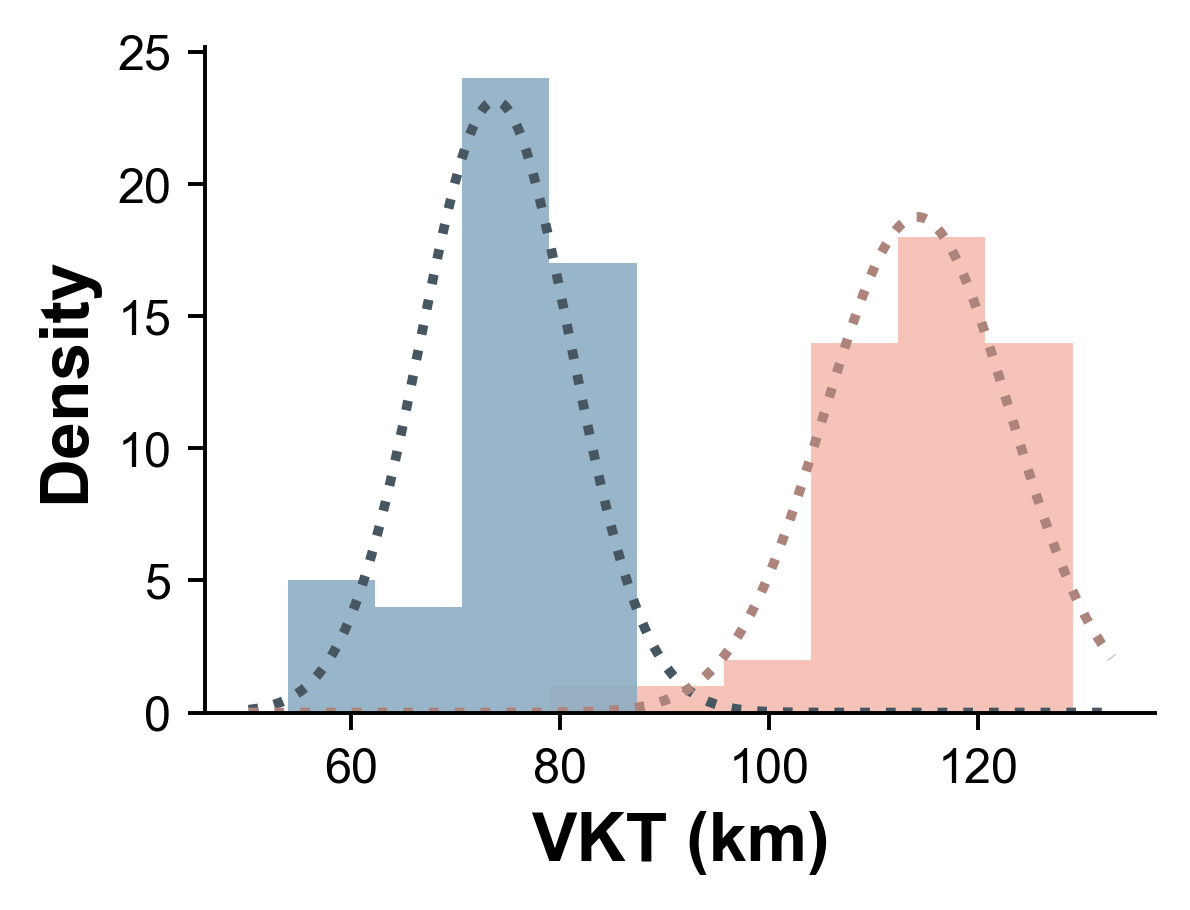

the mean reduction in VKT for 20 euro penalty is: 40.34


In [26]:
_vkt_df = all_metrics_outside_random_20euro_af80_df[all_metrics_outside_random_20euro_af80_df['instance'].between(0, 100)]
figure_plot.hist_plot(_vkt_df,
                      col1='VKT_km',
                      col2='iter0_VKT_km',
                      n_bins=10,
                      figure_size=(3.5,2.7),
                      ylabel = 'Density',
                      xlabel = 'VKT (km)',
                      label_size=14,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                      colors=("#8dadc3", '#f6bdb1'),
                      figure_folder=OUTPUT_FIG_PATH,
                      filename='vkt_distribution_outside_random_20euro_penalty'
                      )
print("the mean reduction in VKT for 20 euro penalty is:",
       (_vkt_df['iter0_VKT_km'].mean() - _vkt_df['VKT_km'].mean()))

### VTT

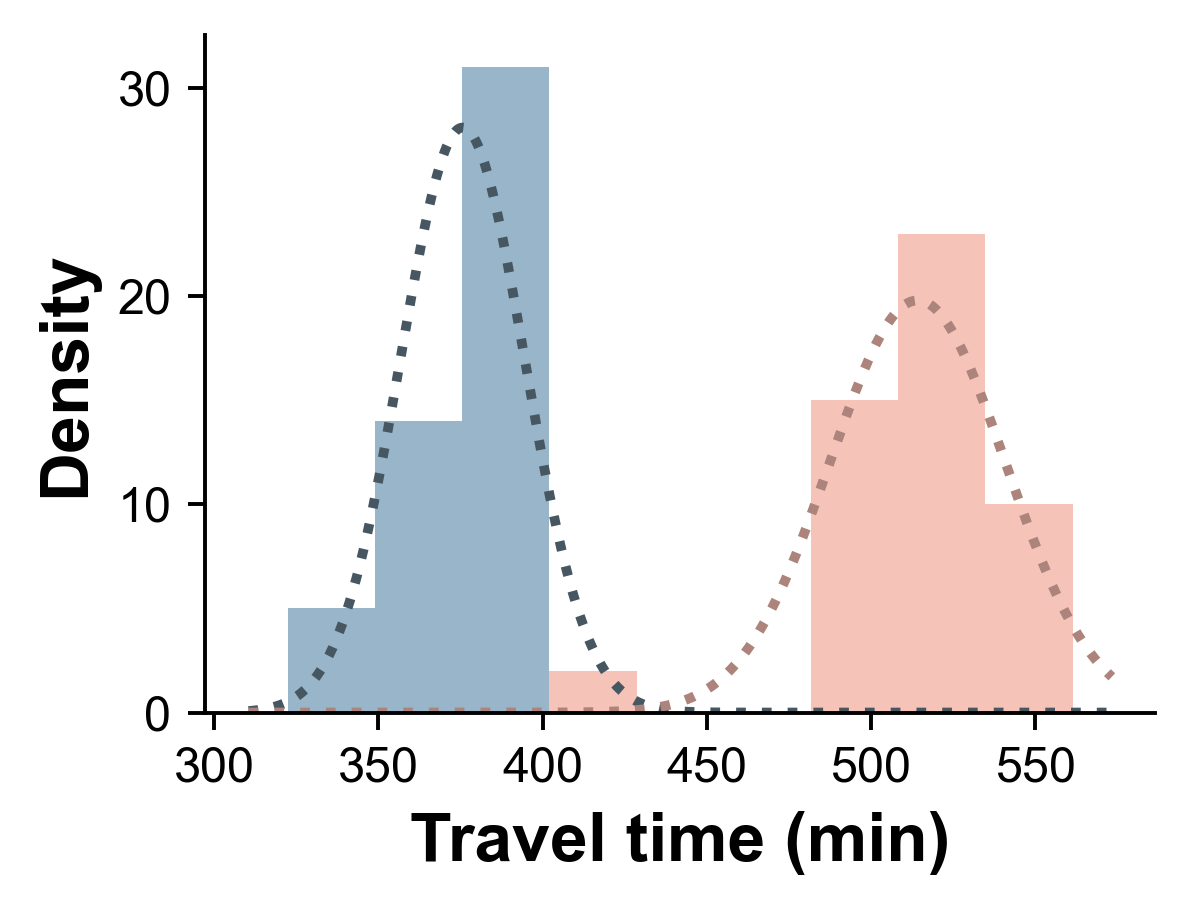

the mean reduction of VTT is: 138.54900000000004


In [32]:
vtt_minutes_df = all_metrics_outside_random_20euro_af80_df.copy()
vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] = (
    vtt_minutes_df[['VTT_seconds', 'iter0_VTT_seconds']] / 60
)
_vtt_minutes_df = vtt_minutes_df[vtt_minutes_df['instance'].between(0,100)]
figure_plot.hist_plot(_vtt_minutes_df,
                      col1='VTT_seconds',
                      col2='iter0_VTT_seconds',
                      n_bins=10,
                      figure_size=(3.5,2.7),
                      ylabel='Density',
                      xlabel='Travel time (min)',
                      label_size=14,
                      hide_labels=False,
                      hide_legends=True,
                      alphas=(0.9, 0.9),
                        colors=("#8dadc3", '#f6bdb1'),
                        figure_folder=OUTPUT_FIG_PATH,
                        filename='vtt_distribution_outside_random_20euro_penalty'
                      )
print("the mean reduction of VTT is: {}".format(
    -(_vtt_minutes_df['VTT_seconds'].mean() 
        - _vtt_minutes_df['iter0_VTT_seconds'].mean())) 
        )

### Ton-km travelled

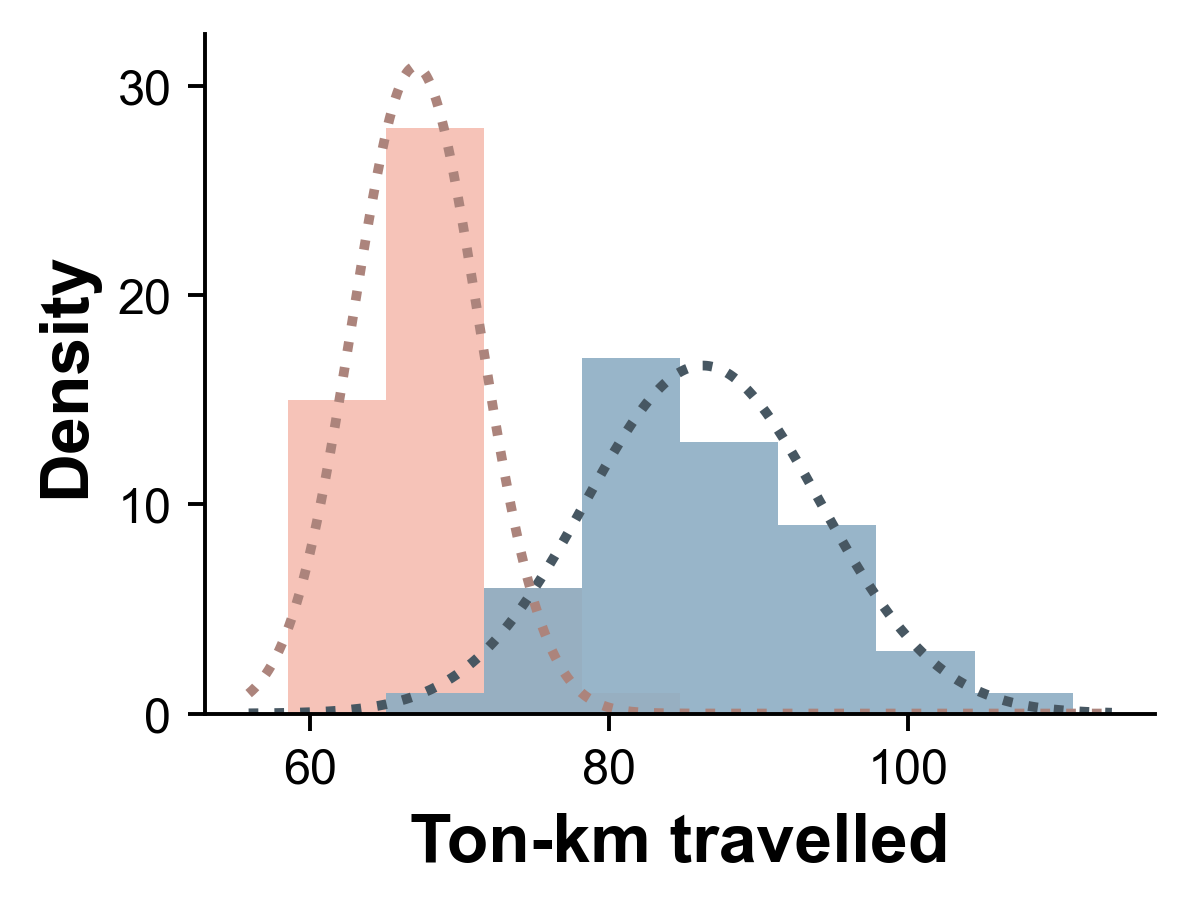

the mean increase of TKT is: 19.22


In [34]:
tkt_ton_df = all_metrics_outside_random_20euro_af80_df.copy()
tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] = (
    tkt_ton_df[['TKT_tonkm', 'iter0_TKT_tonkm']] / 1000
)
_tkt_ton_df = tkt_ton_df[tkt_ton_df['instance'].between(0,100)]
figure_plot.hist_plot(_tkt_ton_df,
                        col1='TKT_tonkm',
                        col2='iter0_TKT_tonkm',
                        n_bins=9,
                        figure_size=(3.5,2.7),
                        ylabel='Density',
                        xlabel='Ton-km travelled',
                        hide_labels=False,
                        hide_legends=True,
                        alphas=(0.9, 0.9),
                        colors=("#8dadc3", '#f6bdb1'),
                        label_size=14,
                        figure_folder=OUTPUT_FIG_PATH,
                        filename='tkt_distribution_outside_random_20euro_penalty'
                        )
print("the mean increase of TKT is: {}".format(
    (_tkt_ton_df['TKT_tonkm'].mean()
        - _tkt_ton_df['iter0_TKT_tonkm'].mean())) 
        )


### Joint plot of collaboration rate, carrier score, receiver score and fleet size.


f:\gitRepository\matsim-libs-2024\python\test\figure_plot.py:815: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


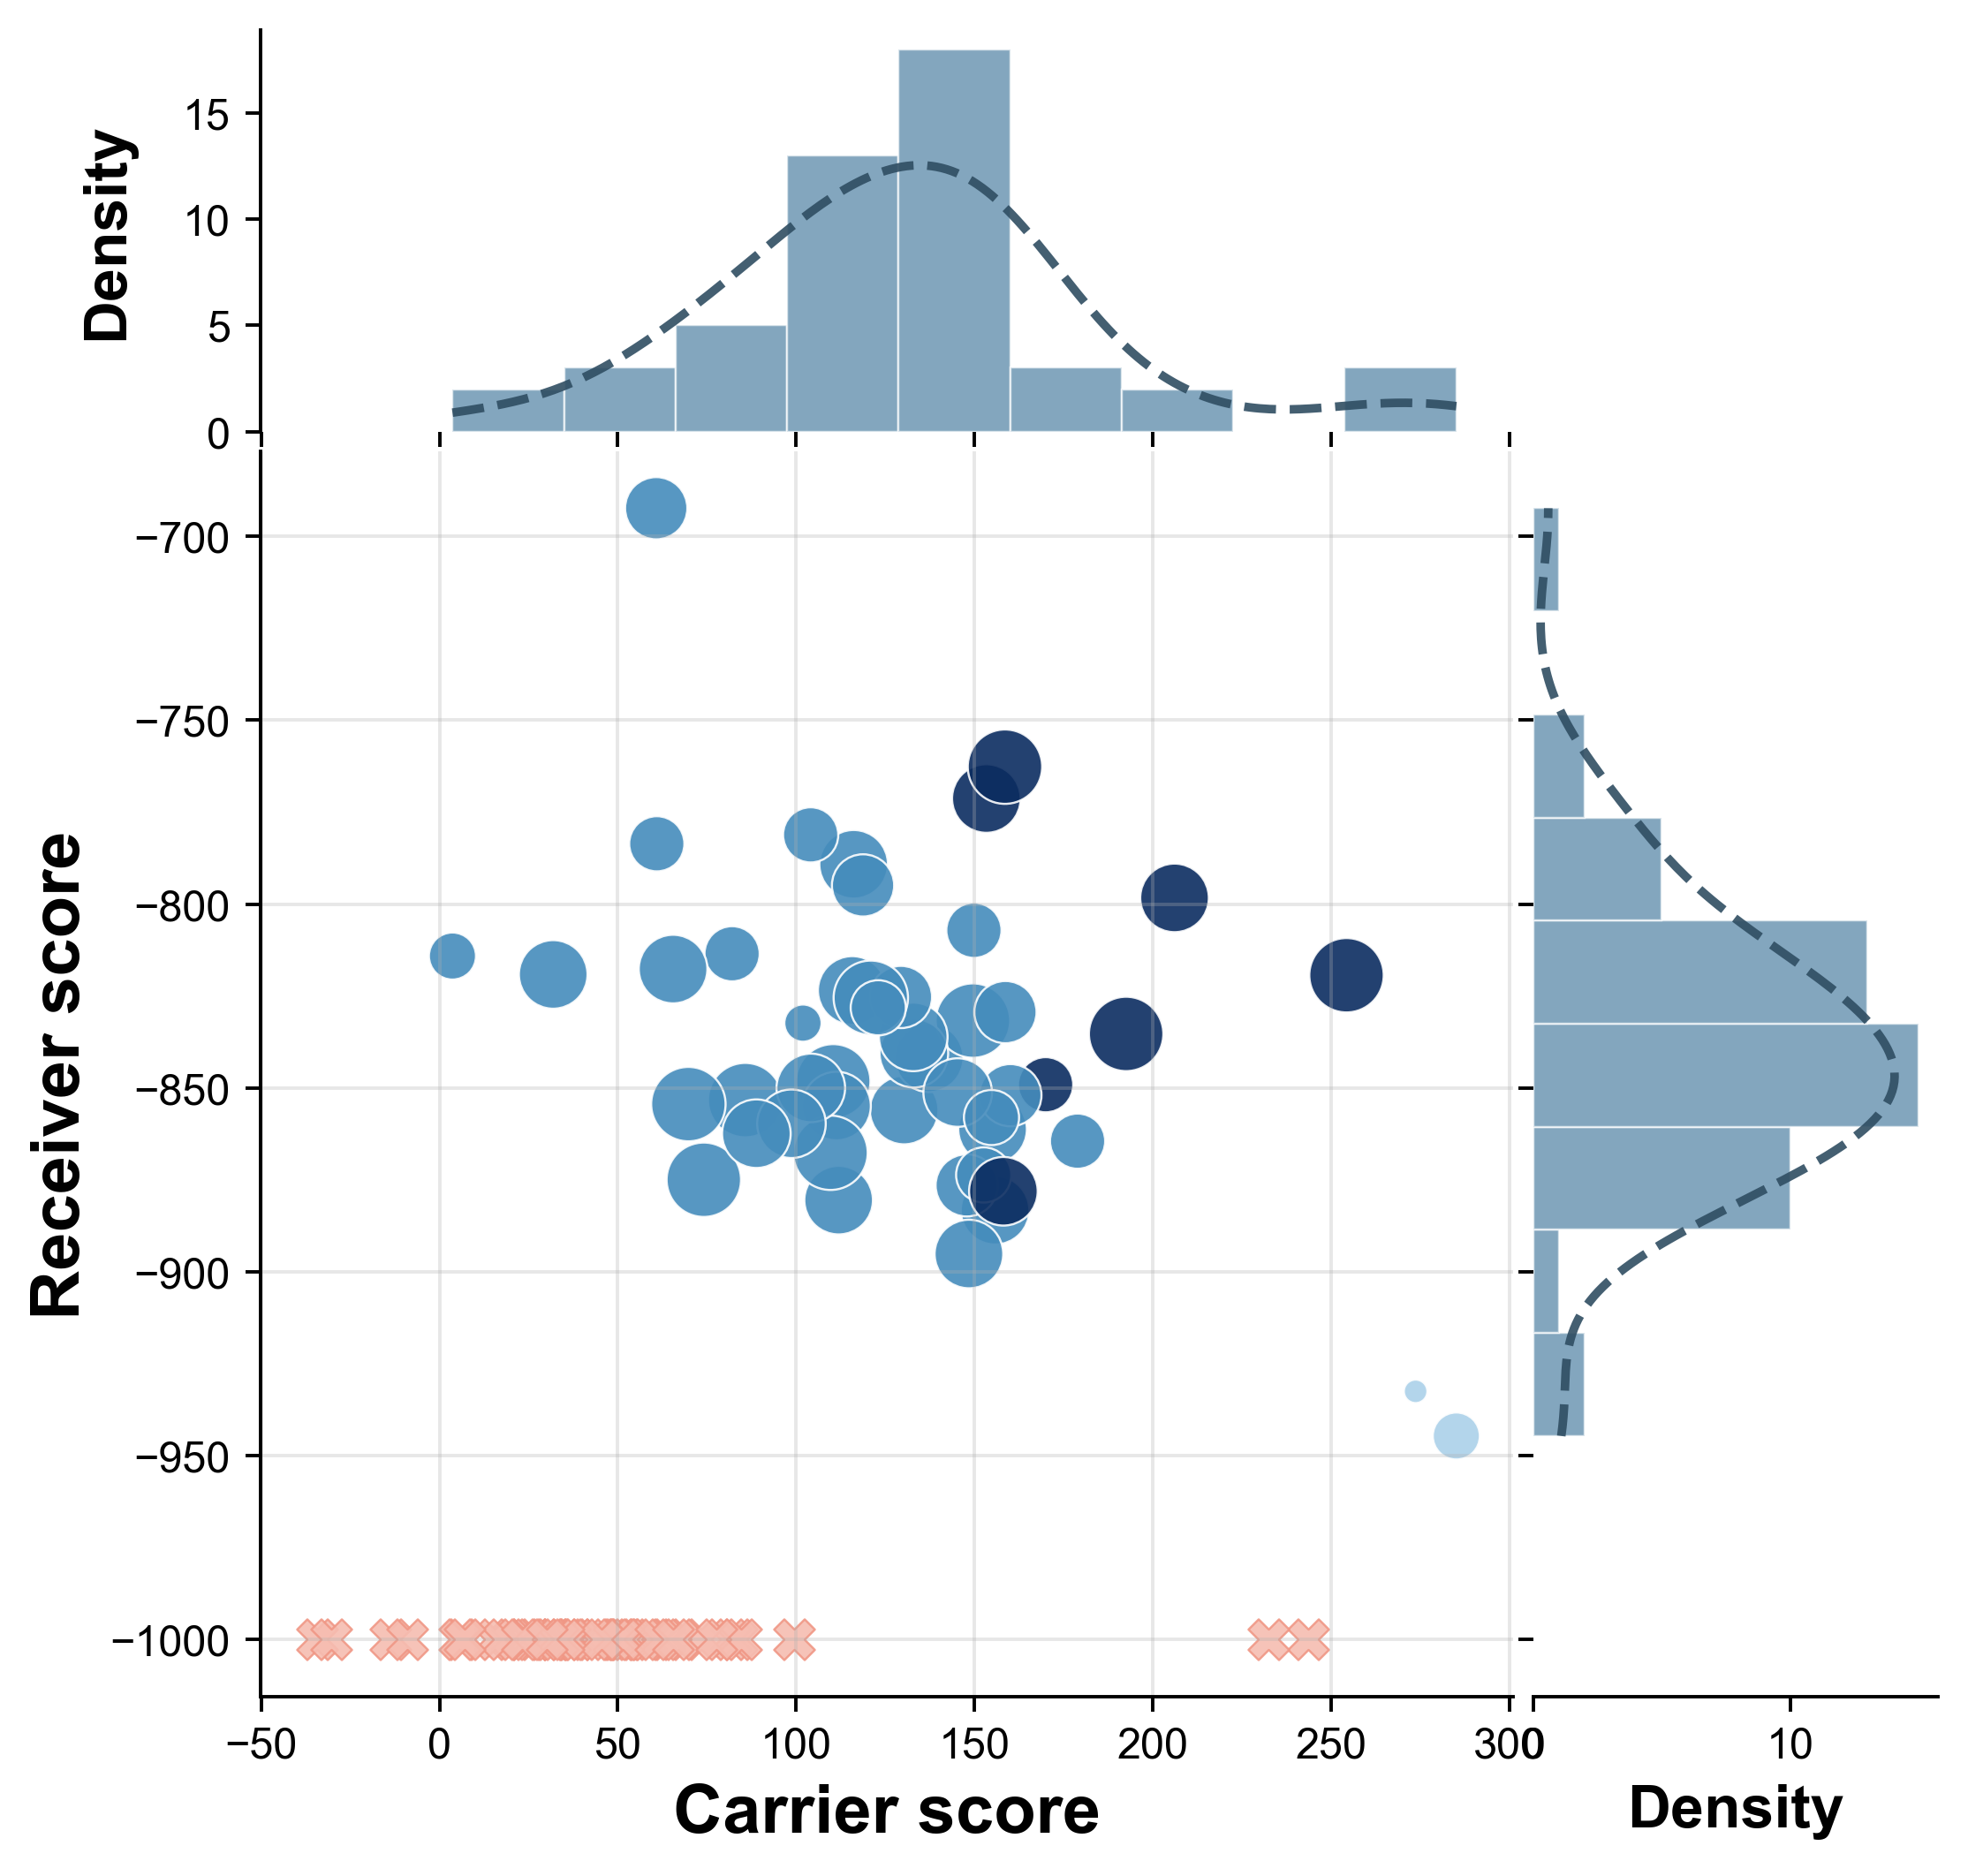

(<Figure size 2450x2450 with 3 Axes>,
 {'main': <Axes: xlabel='Carrier score', ylabel='Receiver score'>,
  'top': <Axes: ylabel='Density'>,
  'right': <Axes: xlabel='Density'>})

In [37]:
_score_df = all_metrics_outside_random_20euro_af80_df[all_metrics_outside_random_20euro_af80_df['instance'].between(0,100)]
_score_df.query("final_carrier_score >= 0", inplace=True)
_score_df['iter0_total_receiver_scores'] = -1000
# Merge the shipment metrics to get the fleet size difference metric
_score_df = pd.merge(
    _score_df,
    all_shipment_metrics_outside_random_20euro_af80_df[['instance_id', 'diff_fleet_size']],
    left_on='instance',
    right_on='instance_id',
    how='left'
)
figure_plot.joint_scatter_plot(
    _score_df,
    x_col='final_carrier_score',
    y_col='total_receiver_scores',
    n_bins=10,
    figure_size=(7, 7),
    marginal_type='both',  # 同时显示 histogram 和 KDE
    marginal_label_size=14,
    xlabel='Carrier score',
    ylabel='Receiver score',
    label_size=16,
    show_corr=False,
    # scatter_color="#8dadc3",
    scatter_alpha=0.9,
    hist_color="#4F81A3",
    kde_linestyle='--',
    kde_alpha=0.9,
    ## the second scatter plot
    data_df2=_score_df,
    x_col2='iter0_carrier_score',
    y_col2='iter0_total_receiver_scores',
    scatter2_marker='X',
    scatter2_color='#f6bdb1',
    scatter2_edgecolor="#f09785",
    scatter2_alpha=0.9,
    scatter2_size=90,
    ## Group the main scatter points by collaboration rate
    size_group_col='collaboration_rate',
    size_min=30,
    size_max=300,
    show_size_legend=False,
    size_legend_loc='lower right',
    ## Group the main scatter points by fleet size
    color_group_col='diff_fleet_size',
    cmap_color_list=["#abd1e9", "#458CBC", "#0b2c60"],
    show_color_legend=False,
    ## Output
    figure_folder=OUTPUT_FIG_PATH,
    filename='joint_RC_scores_with_collab_and_fleetsize.png',
)


### Fleet size

f:\gitRepository\matsim-libs-2024\python\test\figure_plot.py:1389: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('bin').size()


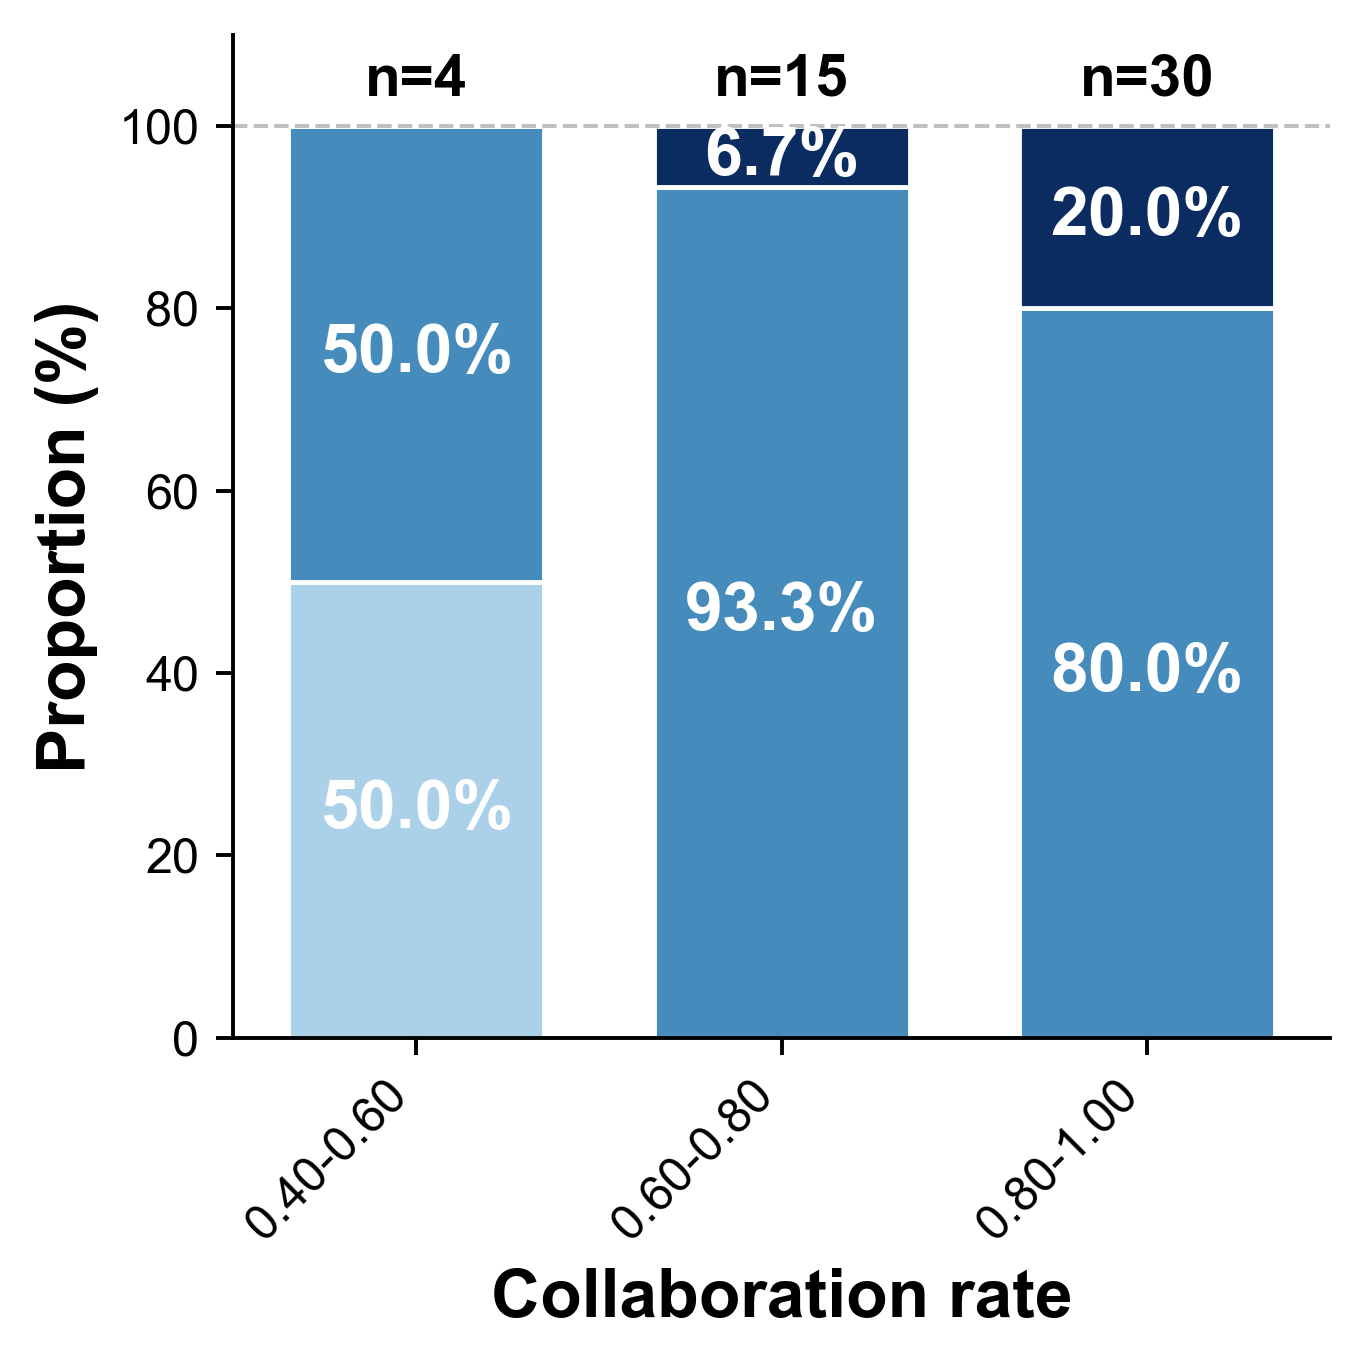

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='Collaboration rate', ylabel='Proportion (%)'>,
 diff_fleet_size            1          2          3  count
 collaboration_rate_bin                                   
 0.40-0.60               50.0  50.000000   0.000000      4
 0.60-0.80                0.0  93.333333   6.666667     15
 0.80-1.00                0.0  80.000000  20.000000     30)

In [39]:

figure_plot.stacked_proportion_plot(_score_df,
                                    figure_size=(4,4),
                                     bin_col='collaboration_rate',
                                     value_col='diff_fleet_size',
                                     bin_method='custom',
                                     custom_bins=[0.4, 0.6, 0.8, 1.0],
                                     colors=["#abd1e9", "#458CBC", "#0b2c60"],
                                     xlabel='Collaboration rate',
                                     ylabel='Proportion (%)',
                                     label_size=14,
                                     show_counts=True,
                                     count_fontsize=12,
                                     percentage_fontsize=14,
                                     # Legend settings
                                     legend_bbox=(0.5, 1.4),
                                     legend_ncol=3,
                                     legend_title='Fleet size difference',
                                     show_legend=False,
                                     # Output
                                     figure_folder=OUTPUT_FIG_PATH,
                                     filename='stacked_proportion_fleet_size_diff_vs_collab.png'
                                     )

### Total cost savings
Plot the correlations between the collaboration rate and the total cost savings

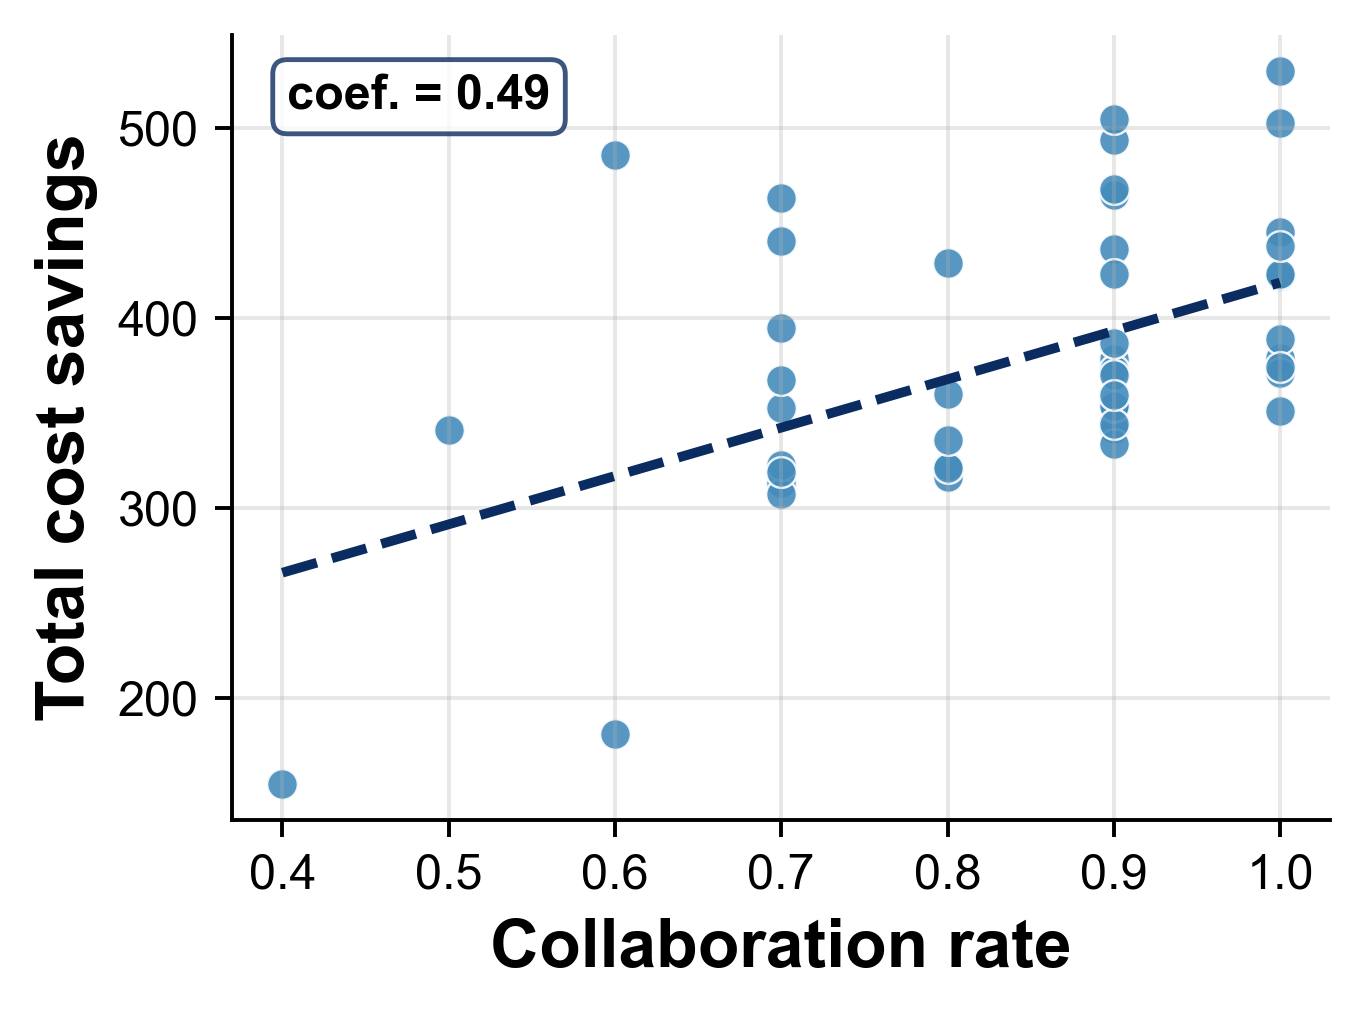

(<Figure size 1400x1050 with 1 Axes>,
 <Axes: xlabel='Collaboration rate', ylabel='Total cost savings'>,
 {'dataset1': {'slope': 254.31324681602956,
   'intercept': 164.18144658127207,
   'r': 0.4941932093661791,
   'r2': 0.24422692818364414,
   'p_value': 0.0002647458288098151,
   'std_err': 64.57245485248671}})

In [41]:
figure_plot.scatter_regression_plot(all_metrics_outside_random_20euro_af80_df,
                                    x_col='collaboration_rate',
                                    y_col='total_cost_savings',
                                    figure_size=(4,3),
                                    xlabel='Collaboration rate',
                                    ylabel='Total cost savings',
                                    label_size=14,
                                    # title='Scatter plot with regression line: Cost Savings vs Collaboration Rate',
                                    show_corr=True,
                                    add_regression=True,
                                    show_equation=False,
                                    show_r2=False,
                                    scatter_color='#458CBC',
                                    scatter_alpha=0.9,
                                    reg_color='#0b2c60',
                                    # Output
                                    figure_folder=OUTPUT_FIG_PATH,
                                    filename='scatter_regression_cost_savings_vs_collab.png'
                                    )

## Compare specific low-run and high-run random scenarios

In [42]:
com_df = all_metrics_outside_random_20euro_af80_df.query("final_carrier_score >= 0")
com_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
10590,left,FULLY_RANDOM,0.8,0.0056,0,2,2,31.873690,32.3072,9,...,109.0,22212.0,30502.0,81500.0,65500.0,5.500131,7.9,0.923607,1.4,0.9
10592,left,FULLY_RANDOM,0.8,0.0056,2,2,2,130.280770,26.6439,9,...,117.0,22210.0,30996.0,75500.0,67500.0,5.938730,8.5,1.224264,2.1,0.9
10593,left,FULLY_RANDOM,0.8,0.0056,3,2,2,111.922040,20.1445,9,...,125.0,23819.0,32068.0,82500.0,65500.0,6.415787,9.3,1.282843,2.1,0.9
10594,left,FULLY_RANDOM,0.8,0.0056,4,2,2,116.130080,38.5941,9,...,113.0,23819.0,30812.0,86500.0,65500.0,6.015938,9.3,0.824264,1.2,0.9
10595,left,FULLY_RANDOM,0.8,0.0056,5,2,2,85.721361,58.0182,10,...,109.0,22210.0,29552.0,79000.0,65000.0,5.643921,7.8,1.324264,1.9,1.0
10596,left,FULLY_RANDOM,0.8,0.0056,6,2,2,206.113380,81.4779,9,...,101.0,19348.0,29125.0,92500.0,60500.0,5.319836,7.7,0.882843,1.2,0.9
10597,left,FULLY_RANDOM,0.8,0.0056,7,2,2,110.407100,15.5195,10,...,121.0,22747.0,31876.0,88000.0,75000.0,6.192132,8.8,1.182843,1.9,1.0
10598,left,FULLY_RANDOM,0.8,0.0056,8,2,2,137.308150,49.3447,9,...,113.0,22210.0,30644.0,85500.0,68500.0,5.585659,7.9,1.100000,1.9,0.9
10599,left,FULLY_RANDOM,0.8,0.0056,9,2,2,111.328375,41.3711,9,...,117.0,23282.0,33500.0,91500.0,62500.0,6.204712,9.1,0.965685,1.5,0.9
10600,left,FULLY_RANDOM,0.8,0.0056,10,2,2,149.578930,53.8895,10,...,109.0,22210.0,29727.0,84500.0,63500.0,5.510409,7.9,1.341421,2.0,1.0


In [45]:
com_df.query("collaboration_rate <= 0.5")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
10630,left,FULLY_RANDOM,0.8,0.0056,50,2,2,101.909720,23.2068,5,...,121.0,23818.0,31595.0,95500.0,69500.0,6.458253,9.7,1.048528,1.7,0.5
10639,left,FULLY_RANDOM,0.8,0.0056,59,2,2,273.720779,232.3434,4,...,88.0,24004.0,25620.0,86000.0,61000.0,5.821201,7.8,1.200000,1.3,0.4


In [47]:
com_df.query("collaboration_rate == 0.9")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
10590,left,FULLY_RANDOM,0.8,0.0056,0,2,2,31.873690,32.3072,9,...,109.0,22212.0,30502.0,81500.0,65500.0,5.500131,7.9,0.923607,1.4,0.9
10592,left,FULLY_RANDOM,0.8,0.0056,2,2,2,130.280770,26.6439,9,...,117.0,22210.0,30996.0,75500.0,67500.0,5.938730,8.5,1.224264,2.1,0.9
10593,left,FULLY_RANDOM,0.8,0.0056,3,2,2,111.922040,20.1445,9,...,125.0,23819.0,32068.0,82500.0,65500.0,6.415787,9.3,1.282843,2.1,0.9
10594,left,FULLY_RANDOM,0.8,0.0056,4,2,2,116.130080,38.5941,9,...,113.0,23819.0,30812.0,86500.0,65500.0,6.015938,9.3,0.824264,1.2,0.9
10596,left,FULLY_RANDOM,0.8,0.0056,6,2,2,206.113380,81.4779,9,...,101.0,19348.0,29125.0,92500.0,60500.0,5.319836,7.7,0.882843,1.2,0.9
10598,left,FULLY_RANDOM,0.8,0.0056,8,2,2,137.308150,49.3447,9,...,113.0,22210.0,30644.0,85500.0,68500.0,5.585659,7.9,1.100000,1.9,0.9
10599,left,FULLY_RANDOM,0.8,0.0056,9,2,2,111.328375,41.3711,9,...,117.0,23282.0,33500.0,91500.0,62500.0,6.204712,9.1,0.965685,1.5,0.9
10601,left,FULLY_RANDOM,0.8,0.0056,11,2,2,115.731677,32.2327,9,...,109.0,22747.0,30021.0,82000.0,68000.0,5.489378,8.4,1.324264,2.1,0.9
10603,left,FULLY_RANDOM,0.8,0.0056,13,2,2,155.087080,63.2695,9,...,109.0,22211.0,29908.0,78000.0,67000.0,5.851076,8.0,0.924264,1.3,0.9
10604,left,FULLY_RANDOM,0.8,0.0056,14,2,2,133.022830,51.6430,9,...,109.0,22209.0,29966.0,86500.0,66500.0,6.163778,9.3,1.141421,2.0,0.9


In [49]:
com_df.query("collaboration_rate == 0.7")


,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
10606,left,FULLY_RANDOM,0.8,0.0056,16,2,2,104.075697,6.1621,7,...,125.0,23820.0,32244.0,90000.0,72000.0,6.490423,9.8,1.206450,2.2,0.7
10611,left,FULLY_RANDOM,0.8,0.0056,21,2,2,82.038775,-13.6561,7,...,129.0,24002.0,32772.0,88000.0,74000.0,6.772921,9.4,1.041421,1.8,0.7
10612,left,FULLY_RANDOM,0.8,0.0056,22,2,2,169.968370,52.6690,7,...,117.0,20956.0,30933.0,100000.0,65000.0,6.081666,8.8,1.241421,1.8,0.7
10616,left,FULLY_RANDOM,0.8,0.0056,26,2,2,60.924988,44.2572,7,...,113.0,22748.0,31051.0,84500.0,65500.0,5.678719,8.1,1.147871,1.9,0.7
10618,left,FULLY_RANDOM,0.8,0.0056,28,2,2,152.594114,50.7203,7,...,109.0,23283.0,31700.0,82500.0,65500.0,5.519634,8.1,1.272135,2.0,0.7
10621,left,FULLY_RANDOM,0.8,0.0056,41,2,2,178.925443,84.5673,7,...,105.0,22747.0,29924.0,83000.0,63000.0,5.692461,8.0,1.023607,1.5,0.7
10632,left,FULLY_RANDOM,0.8,0.0056,52,2,2,149.859091,34.7445,7,...,121.0,23282.0,31172.0,93500.0,65500.0,5.842729,8.1,1.182843,2.3,0.7
10633,left,FULLY_RANDOM,0.8,0.0056,53,2,2,154.782320,65.5021,7,...,109.0,23284.0,29732.0,82000.0,66000.0,5.052181,7.0,1.241421,1.8,0.7
10637,left,FULLY_RANDOM,0.8,0.0056,57,2,2,123.027720,6.9943,7,...,125.0,23283.0,32620.0,84500.0,70500.0,6.751372,9.5,1.399070,1.9,0.7


In [50]:
_low_collab_ins_id = 50 #or 59
_high_collab_ins_id = 6
_medium_collab_ins_id = 41
specific_run_list = [_low_collab_ins_id, _high_collab_ins_id, _medium_collab_ins_id]

In [51]:
low_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_low_collab_ins_id:02d}',
    'geo_data.geojson'))
high_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_high_collab_ins_id:02d}',
    'geo_data.geojson'))    
medium_collab_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH,
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.RANDOM.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_medium_collab_ins_id:02d}',
    'geo_data.geojson'))


### Plot spatial distribution

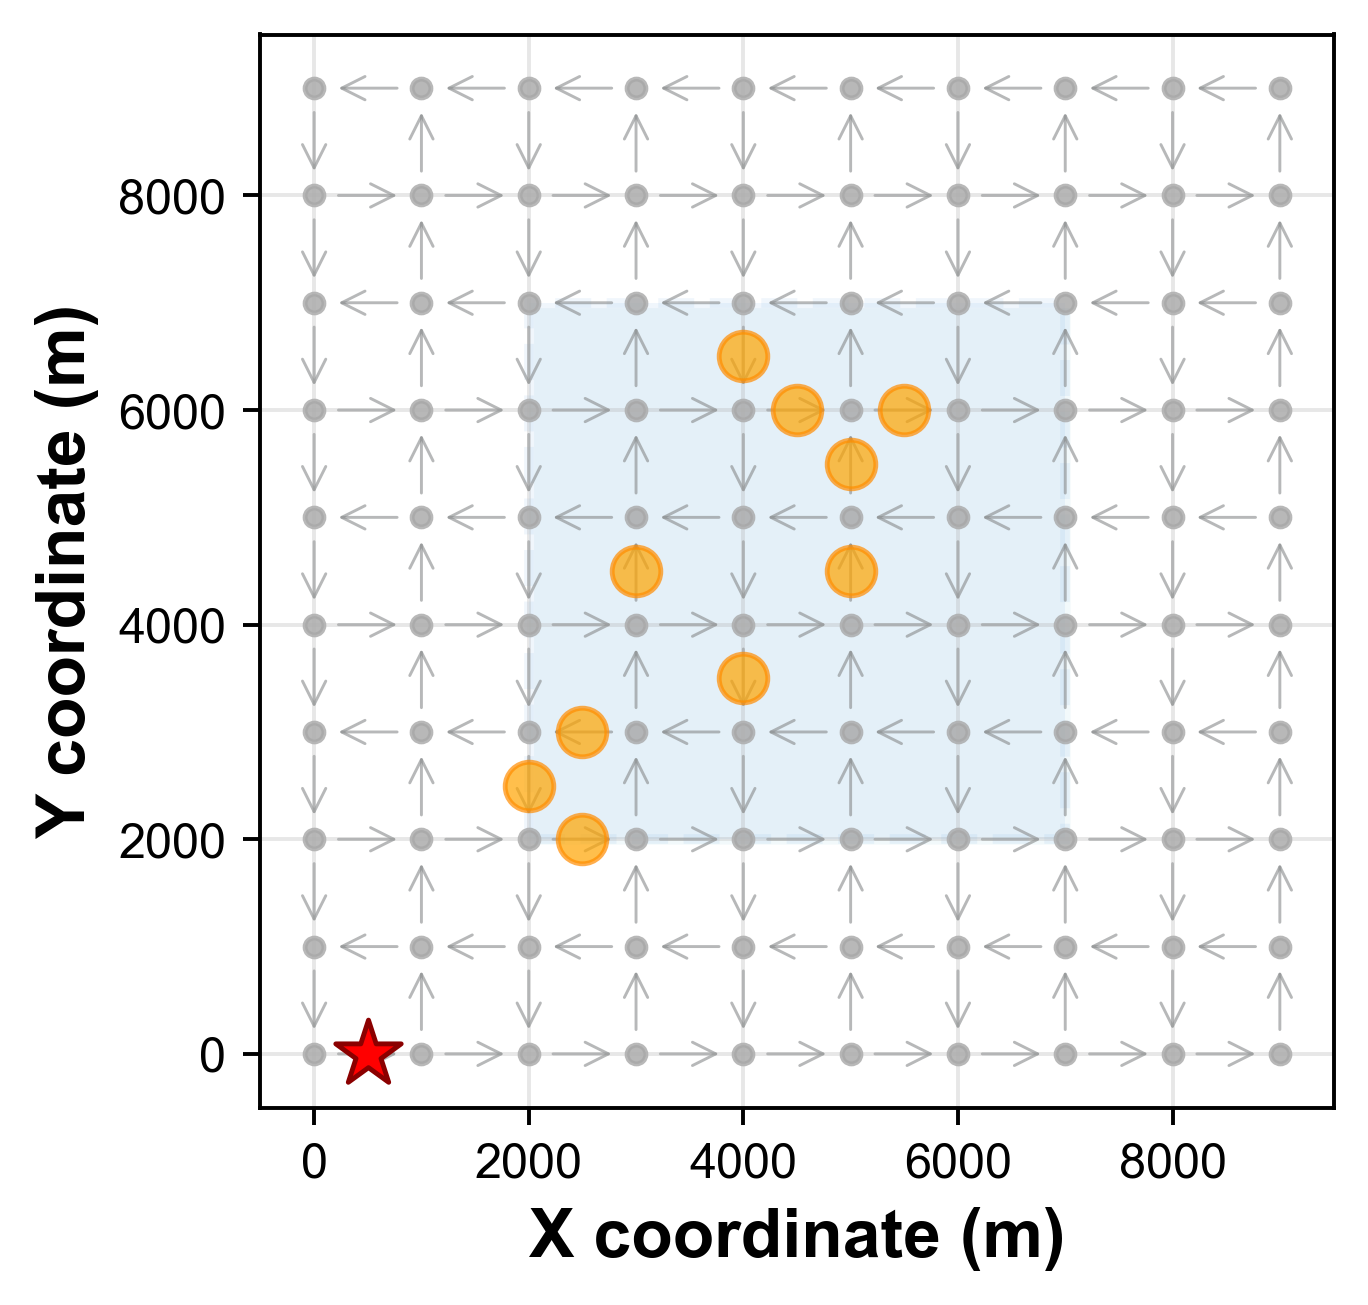

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [55]:
''' Plot receiver locations at link midpoints for high collaboration scenario'''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=high_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (High Collaboration)',
    figure_size=(4, 4),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_high_collab_outside_random_20euro.png'
)

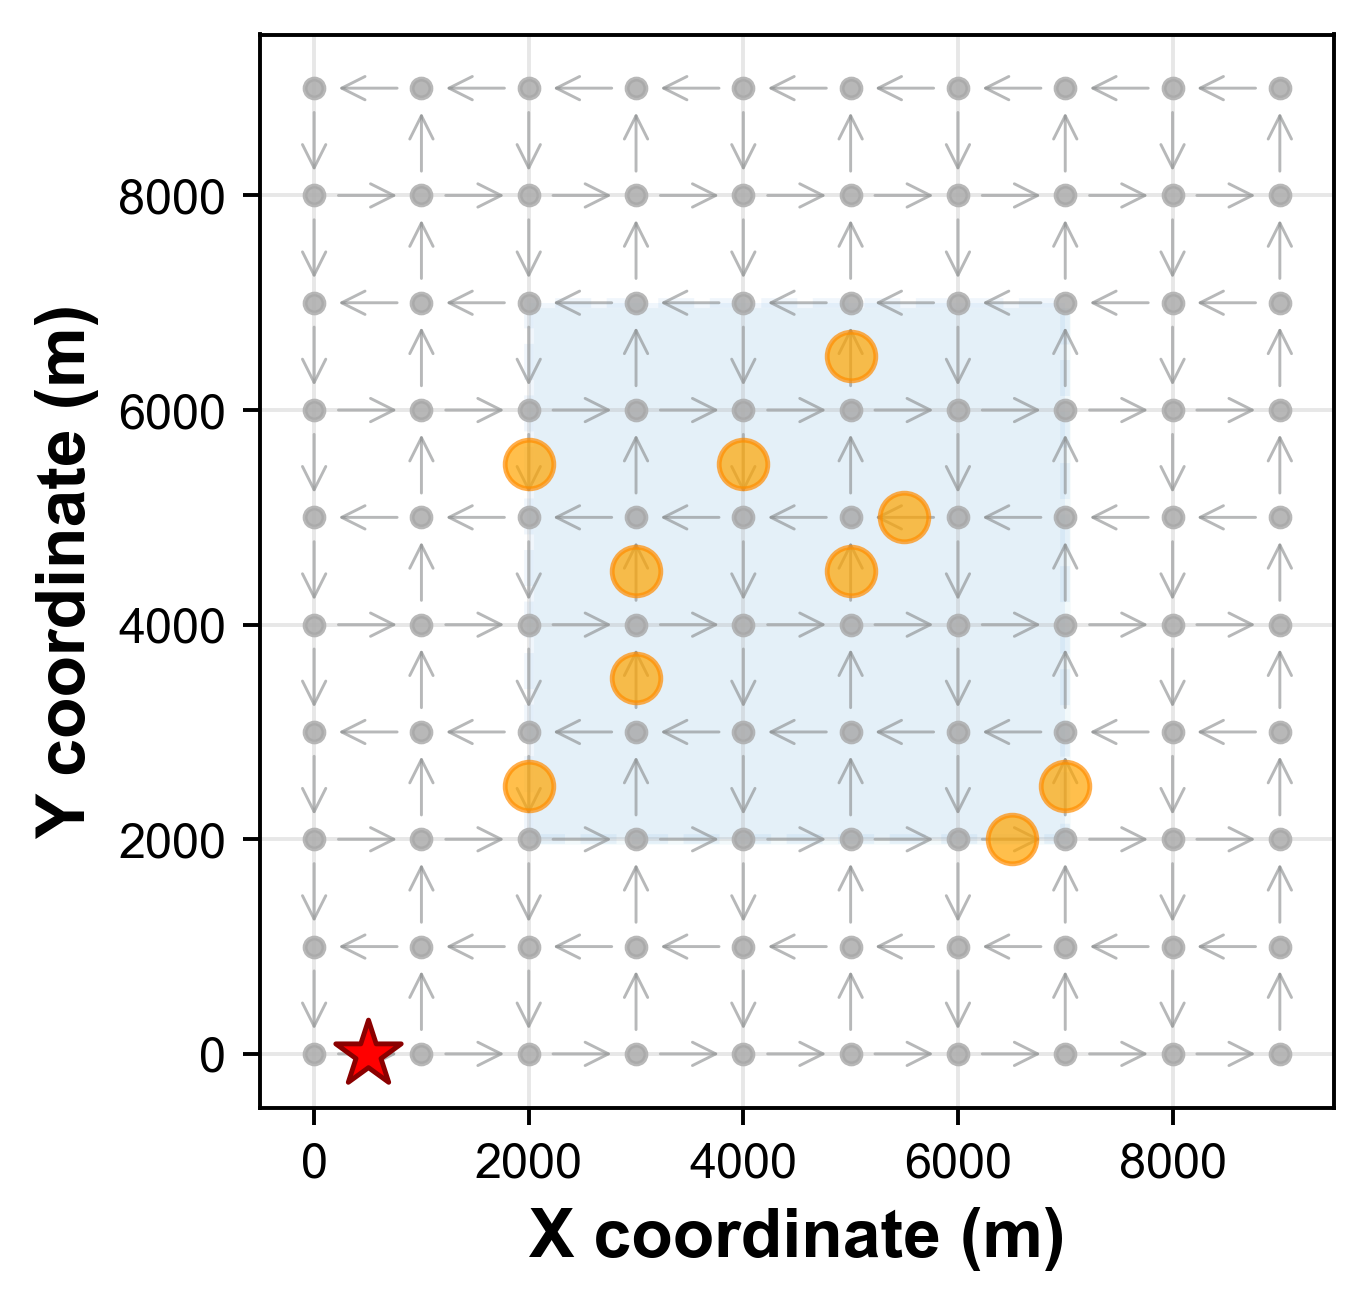

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [53]:
''' Plot receiver locations at link midpoints for medium collaboration scenario'''

figure_plot.network_locations_plot(
    network=network,
    locations_gdf=medium_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (High Collaboration)',
    figure_size=(4, 4),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_medium_collab_outside_random_20euro.png'
)

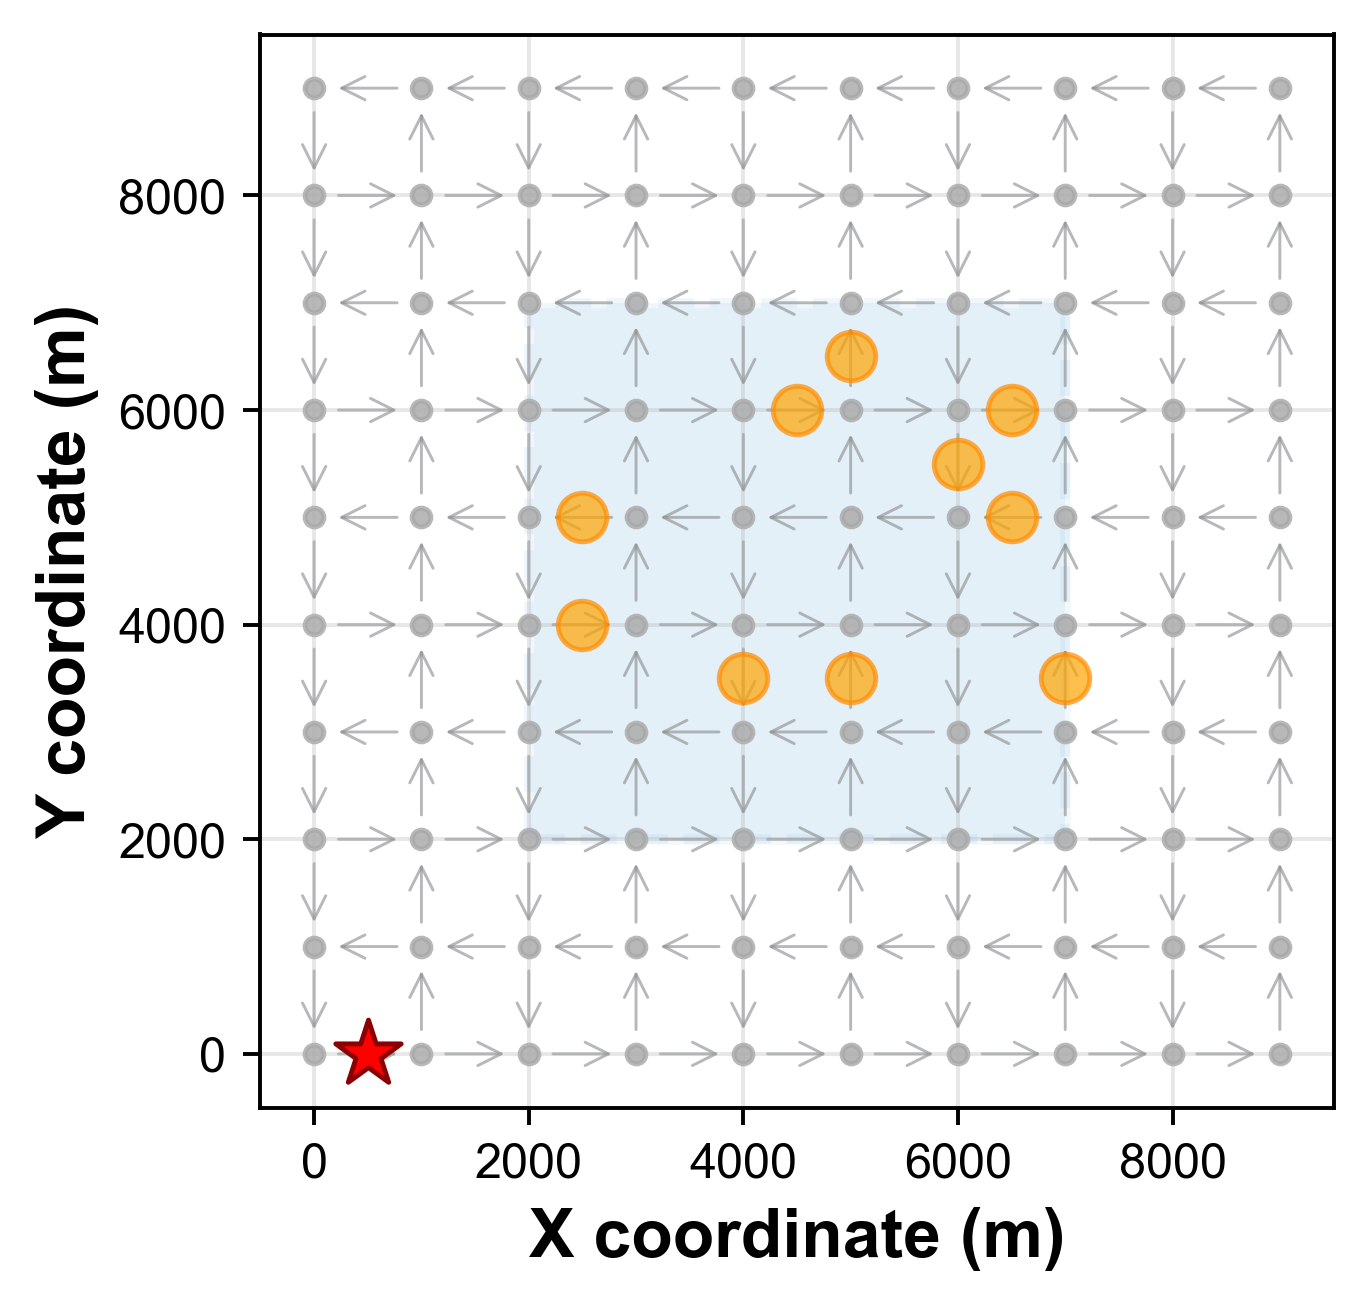

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [54]:
''' Plot receiver locations at link midpoints for low collaboration scenario '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=low_collab_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (High Collaboration)',
    figure_size=(4, 4),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_low_collab_outside_random_20euro.png'
)

### Agg statistics

<Axes: xlabel='collaboration_rate', ylabel='mean_receiver_dist_to_depot_euclidean_km'>

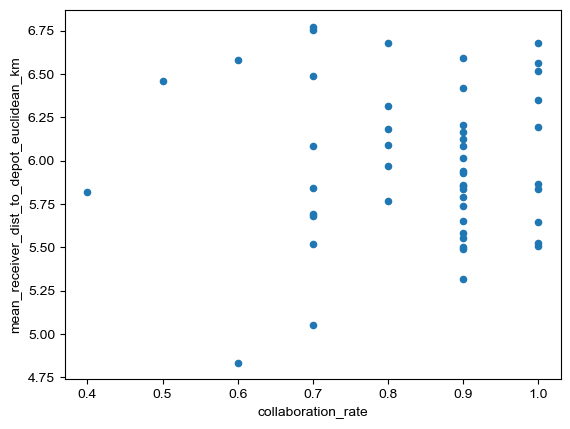

In [56]:
com_df.plot.scatter(x='collaboration_rate', y='mean_receiver_dist_to_depot_euclidean_km')


<Axes: xlabel='collaboration_rate', ylabel='clustering_index_euclidean_km'>

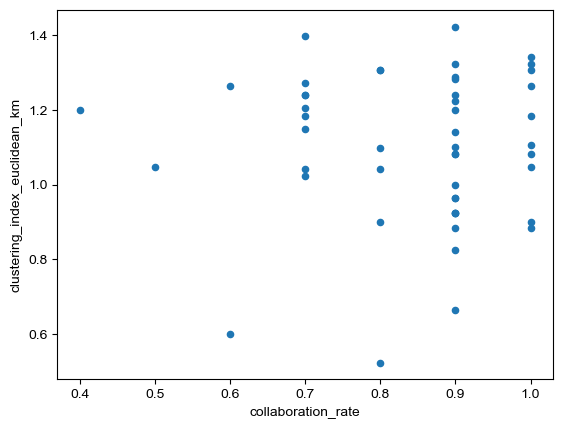

In [75]:
com_df.plot.scatter(x='collaboration_rate', y='clustering_index_euclidean_km')



In [70]:
com_df_collab_40_50 = com_df[
    (com_df['collaboration_rate'].between(0.4, 0.6))
]
com_df_collab_60_80 = com_df[
    (com_df['collaboration_rate'].between(0.7, 0.8))
]
com_df_collab_90_100 = com_df[
    (com_df['collaboration_rate'].between(0.7, 1.0))
]

In [71]:
## Print the mean receiver to depot euclidean distance for each subgroup
print("the mean receiver to depot euclidean distance for subgroup 40-50% is:", com_df_collab_40_50['mean_receiver_dist_to_depot_euclidean_km'].mean())
print("the mean receiver to depot euclidean distance for subgroup 60-80% is:", com_df_collab_60_80['mean_receiver_dist_to_depot_euclidean_km'].mean())
print("the mean receiver to depot euclidean distance for subgroup 90-100% is:", com_df_collab_90_100['mean_receiver_dist_to_depot_euclidean_km'].mean())

print()
## print the mean receiver to depot road distance for each subgroup
print("the mean receiver to depot road distance for subgroup 40-50% is:", com_df_collab_40_50['mean_receiver_dist_to_depot_network_km'].mean())
print("the mean receiver to depot road distance for subgroup 60-80% is:", com_df_collab_60_80['mean_receiver_dist_to_depot_network_km'].mean())
print("the mean receiver to depot road distance for subgroup 90-100% is:", com_df_collab_90_100['mean_receiver_dist_to_depot_network_km'].mean())

print()
## Print the mean clustering_index_euclidean_km for each subgroup
print("the mean clustering_index_euclidean_km for subgroup 40-50% is:", com_df_collab_40_50['clustering_index_euclidean_km'].mean())
print("the mean clustering_index_euclidean_km for subgroup 60-80% is:", com_df_collab_60_80['clustering_index_euclidean_km'].mean())
print("the mean clustering_index_euclidean_km for subgroup 90-100% is:", com_df_collab_90_100['clustering_index_euclidean_km'].mean())

print()
### Print the mean clustering_index_network_km for each subgroup
print("the mean clustering_index_network_km for subgroup 40-50% is:", com_df_collab_40_50['clustering_index_network_km'].mean())
print("the mean clustering_index_network_km for subgroup 60-80% is:", com_df_collab_60_80['clustering_index_network_km'].mean())
print("the mean clustering_index_network_km for subgroup 90-100% is:", com_df_collab_90_100['clustering_index_network_km'].mean())

the mean receiver to depot euclidean distance for subgroup 40-50% is: 5.924595653428342
the mean receiver to depot euclidean distance for subgroup 60-80% is: 6.05867820949528
the mean receiver to depot euclidean distance for subgroup 90-100% is: 5.982735252548693

the mean receiver to depot road distance for subgroup 40-50% is: 8.4
the mean receiver to depot road distance for subgroup 60-80% is: 8.646666666666667
the mean receiver to depot road distance for subgroup 90-100% is: 8.584444444444445

the mean clustering_index_euclidean_km for subgroup 40-50% is: 1.0283890728527862
the mean clustering_index_euclidean_km for subgroup 60-80% is: 1.1289262862118812
the mean clustering_index_euclidean_km for subgroup 90-100% is: 1.1076368703642507

the mean clustering_index_network_km for subgroup 40-50% is: 1.45
the mean clustering_index_network_km for subgroup 60-80% is: 1.76
the mean clustering_index_network_km for subgroup 90-100% is: 1.7444444444444447


{'whiskers': [<matplotlib.lines.Line2D at 0x117eef49390>,
 'caps': [<matplotlib.lines.Line2D at 0x117eef498d0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x117eef48fd0>,
 'medians': [<matplotlib.lines.Line2D at 0x117eef49e10>,
 'fliers': [<matplotlib.lines.Line2D at 0x117eef4a0b0>,
 'means': []}

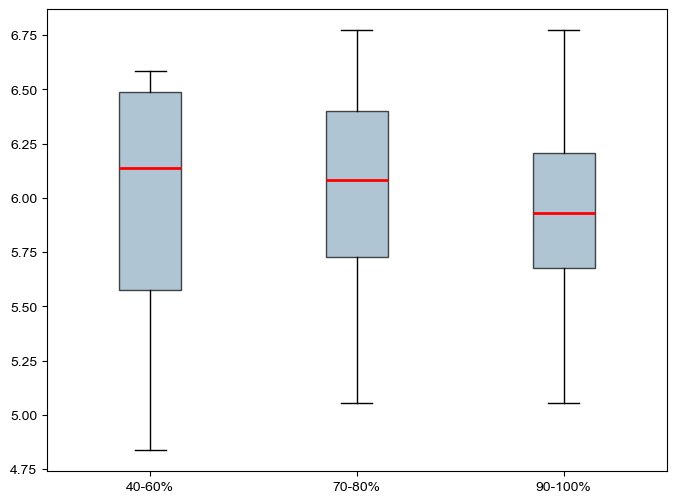

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [com_df_collab_40_50['mean_receiver_dist_to_depot_euclidean_km'],
     com_df_collab_60_80['mean_receiver_dist_to_depot_euclidean_km'],
     com_df_collab_90_100['mean_receiver_dist_to_depot_euclidean_km']],
    labels=['40-60%', '70-80%', '90-100%'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)

{'whiskers': [<matplotlib.lines.Line2D at 0x117ef2fe2f0>,
 'caps': [<matplotlib.lines.Line2D at 0x117ef2fe830>,
 'boxes': [<matplotlib.patches.PathPatch at 0x117ef2fdf00>,
 'medians': [<matplotlib.lines.Line2D at 0x117ef2fed40>,
 'fliers': [<matplotlib.lines.Line2D at 0x117ef2fefe0>,
 'means': []}

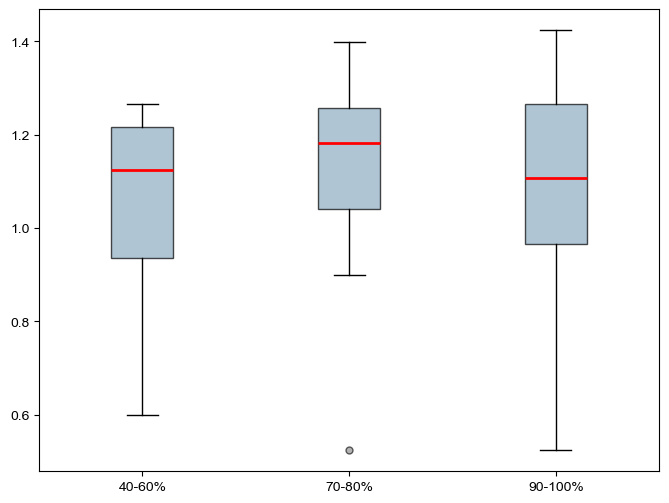

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [com_df_collab_40_50['clustering_index_euclidean_km'],
     com_df_collab_60_80['clustering_index_euclidean_km'],
     com_df_collab_90_100['clustering_index_euclidean_km']],
    labels=['40-60%', '70-80%', '90-100%'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)

#### Read and agg NNI metric

In [76]:
'''read all geo data from clean folder and aggregate NNI metrics'''
nni_df = agg_anls.aggregate_nni_from_clean_folder(
    str(clean_data_path),
    study_area_by_distribution={
        'CLUSTERED': 7000*7000,
        'DISPERSED': 5000*5000,
        'FULLY_RANDOM': 6000 * 6000,
    }
)
nni_df.head(10)

Found 11220 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\clean


Processing NNI: 100%|██████████| 11220/11220 [01:48<00:00, 103.77it/s]

Processed NNI for 11220 scenarios successfully.


,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,nni,mean_observed_distance,mean_expected_distance,z_score,p_value,pattern,n_receivers,study_area
0,center,CLUSTERED,0.5,0.0,0,0.850582,941.421356,1106.797181,-0.903930,0.366032,random,10,49000000
1,center,CLUSTERED,0.5,0.0,1,0.760231,841.421356,1106.797181,-1.450522,0.146913,clustered,10,49000000
2,center,CLUSTERED,0.5,0.0,2,0.669880,741.421356,1106.797181,-1.997113,0.045813,clustered,10,49000000
3,center,CLUSTERED,0.5,0.0,3,0.903508,1000.000000,1106.797181,-0.583744,0.559392,random,10,49000000
4,center,CLUSTERED,0.5,0.0,4,0.850582,941.421356,1106.797181,-0.903930,0.366032,random,10,49000000
5,center,CLUSTERED,0.5,0.0,5,0.542105,600.000000,1106.797181,-2.770110,0.005604,clustered,10,49000000
6,center,CLUSTERED,0.5,0.0,6,0.940932,1041.421356,1106.797181,-0.357339,0.720838,random,10,49000000
7,center,CLUSTERED,0.5,0.0,7,0.473083,523.606798,1106.797181,-3.187669,0.001434,clustered,10,49000000
8,center,CLUSTERED,0.5,0.0,8,0.542105,600.000000,1106.797181,-2.770110,0.005604,clustered,10,49000000
9,center,CLUSTERED,0.5,0.0,9,0.579529,641.421356,1106.797181,-2.543704,0.010968,clustered,10,49000000


In [82]:
outside_random_20_af80_nni_df = nni_df[
    (nni_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (nni_df['receiver_distribution'] == ReceiverDistribution.RANDOM.value) &
    (nni_df['penalty'] == 0.0056) &
    (nni_df['allocation_factor'] == 0.8)
]
# merge with all_metrics_outside_random_20euro_df to get collaboration rate, etc metrics
outside_random_20_af80_nni_df = pd.merge(
    outside_random_20_af80_nni_df,
    all_metrics_outside_random_20euro_af80_df,
    left_on=['instance_id', 'penalty', 'depot_location', 'receiver_distribution', 'allocation_factor'],
    right_on=['instance', 'penalty', 'depot_location', 'receiver_distribution', 'allocation_factor'],
    how='left'
)
outside_random_20_af80_nni_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,nni,mean_observed_distance,mean_expected_distance,z_score,p_value,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
0,left,FULLY_RANDOM,0.8,0.0056,0,0.973567,923.606798,948.683298,-0.159910,0.872952,...,109.0,22212.0,30502.0,81500.0,65500.0,5.500131,7.9,0.923607,1.4,0.9
1,left,FULLY_RANDOM,0.8,0.0056,1,1.097754,1041.421356,948.683298,0.591381,0.554265,...,129.0,24004.0,32972.0,83500.0,69500.0,6.950360,10.1,1.041421,1.5,1.0
2,left,FULLY_RANDOM,0.8,0.0056,2,1.290488,1224.264069,948.683298,1.757351,0.078858,...,117.0,22210.0,30996.0,75500.0,67500.0,5.938730,8.5,1.224264,2.1,0.9
3,left,FULLY_RANDOM,0.8,0.0056,3,1.352235,1282.842712,948.683298,2.130901,0.033097,...,125.0,23819.0,32068.0,82500.0,65500.0,6.415787,9.3,1.282843,2.1,0.9
4,left,FULLY_RANDOM,0.8,0.0056,4,0.868851,824.264069,948.683298,-0.793409,0.427540,...,113.0,23819.0,30812.0,86500.0,65500.0,6.015938,9.3,0.824264,1.2,0.9
5,left,FULLY_RANDOM,0.8,0.0056,5,1.395897,1324.264069,948.683298,2.395041,0.016619,...,109.0,22210.0,29552.0,79000.0,65000.0,5.643921,7.8,1.324264,1.9,1.0
6,left,FULLY_RANDOM,0.8,0.0056,6,0.930598,882.842712,948.683298,-0.419859,0.674589,...,101.0,19348.0,29125.0,92500.0,60500.0,5.319836,7.7,0.882843,1.2,0.9
7,left,FULLY_RANDOM,0.8,0.0056,7,1.246826,1182.842712,948.683298,1.493211,0.135382,...,121.0,22747.0,31876.0,88000.0,75000.0,6.192132,8.8,1.182843,1.9,1.0
8,left,FULLY_RANDOM,0.8,0.0056,8,1.159502,1100.000000,948.683298,0.964932,0.334579,...,113.0,22210.0,30644.0,85500.0,68500.0,5.585659,7.9,1.100000,1.9,0.9
9,left,FULLY_RANDOM,0.8,0.0056,9,1.017922,965.685425,948.683298,0.108421,0.913662,...,117.0,23282.0,33500.0,91500.0,62500.0,6.204712,9.1,0.965685,1.5,0.9


<Axes: xlabel='nni', ylabel='collaboration_rate'>

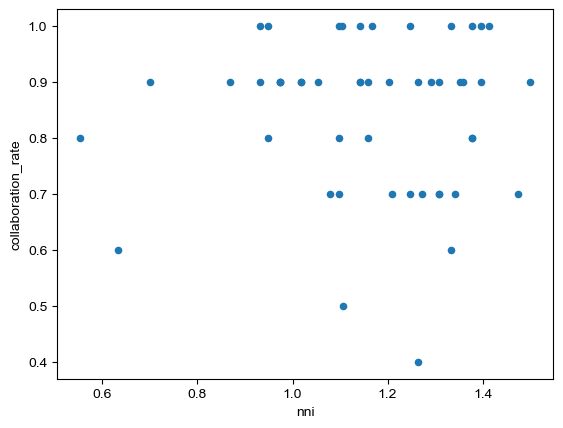

In [83]:
outside_random_20_af80_nni_df.plot.scatter(x='nni',
                                      y='collaboration_rate')

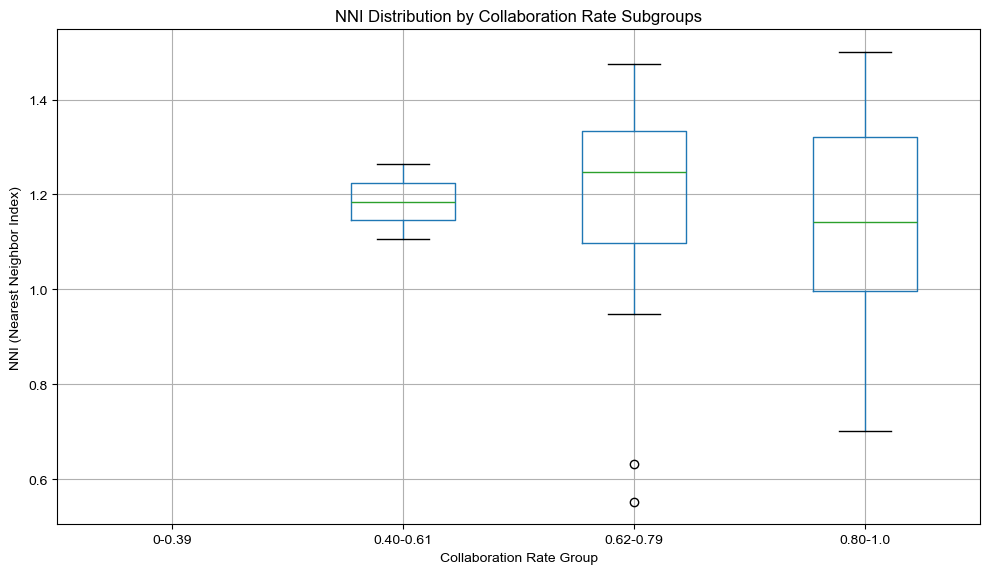

In [91]:
# Box plot NNI by collaboration_rate subgroups
bins = [0, 0.39, 0.51, 0.8, 1.1]
labels = ['0-0.39', '0.40-0.61', '0.62-0.79', '0.80-1.0']
outside_random_20_af80_nni_df['collab_group'] = pd.cut(
    outside_random_20_af80_nni_df['collaboration_rate'], 
    bins=bins, 
    labels=labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(10, 6))
outside_random_20_af80_nni_df.boxplot(column='nni', by='collab_group', ax=ax)
ax.set_xlabel('Collaboration Rate Group')
ax.set_ylabel('NNI (Nearest Neighbor Index)')
ax.set_title('NNI Distribution by Collaboration Rate Subgroups')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Behavioural sensitivity

## Spatial sensitivity

In [108]:
specific_anls_af = 0.8
specific_anls_penalty = 0.0056

In [253]:
ins_center_clustered_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_center_dispersed_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.INSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_outside_clustered_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]

ins_outside_dispersed_specific_anls_df = all_metrics_df[
    (all_metrics_df['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_metrics_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value) &
    (all_metrics_df['allocation_factor'] == specific_anls_af) &
    (all_metrics_df['penalty'] == specific_anls_penalty)
    ]


### Trial on Moran's I and Getis Ord 

In [193]:
link_data_path = repo_root / 'data/freightChessboardRC/cleanMoreDispersed'
all_stat_collab_links, all_stat_collab_links_agg = agg_anls.aggregate_collaborative_receivers_by_link(
    str(link_data_path),
    verbose=True
)

Found 2398 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\cleanMoreDispersed


Processing collaborative receivers: 100%|██████████| 2398/2398 [00:35<00:00, 67.40it/s]


Processed 13697 instance-link records from 29 unique instances.
Aggregated to 3969 scenario-link combinations.


In [194]:
ins_outside_dispersed_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

ins_outside_clustered_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)
]

ins_center_dispersed_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

ins_center_clustered_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value) &
    (all_stat_collab_links['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)
]

In [195]:
ins_center_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.INSIDE.value)
]

ins_outside_specific_stat_collab_links = all_stat_collab_links[
    (all_stat_collab_links['allocation_factor'] == specific_anls_af) &
    (all_stat_collab_links['penalty'] == specific_anls_penalty) &
    (all_stat_collab_links['depot_location'] == DepotLocation.OUTSIDE.value)
]

In [196]:
mean_collab_links_center_clustered = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_clustered_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_center_dispersed = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_dispersed_specific_stat_collab_links,
    full_network_gdf,)
mean_collab_links_outside_clustered = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_clustered_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_outside_dispersed = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_dispersed_specific_stat_collab_links,
    full_network_gdf,)

mean_collab_links_center = spatial_anls.compute_mean_collab_count_by_link(
    ins_center_specific_stat_collab_links,
    central_area_network_gdf,)
mean_collab_links_outside = spatial_anls.compute_mean_collab_count_by_link(
    ins_outside_specific_stat_collab_links,
    full_network_gdf,) 

<Axes: >

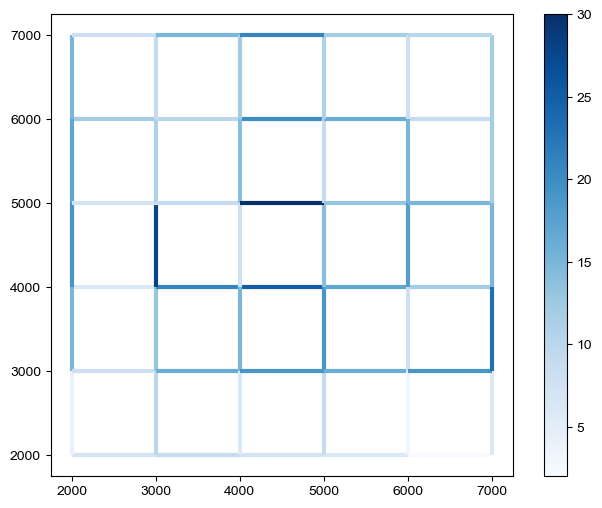

In [148]:
mean_collab_links_center.plot(column='total_collab_count',
                                        cmap='Blues',
                                        legend=True,
                                        figsize=(8, 6),
                                        # title='Mean Collaborative Receivers per Link\n(Center - Clustered)',
                                        # edgecolor='k',
                                        linewidth=3)

<Axes: >

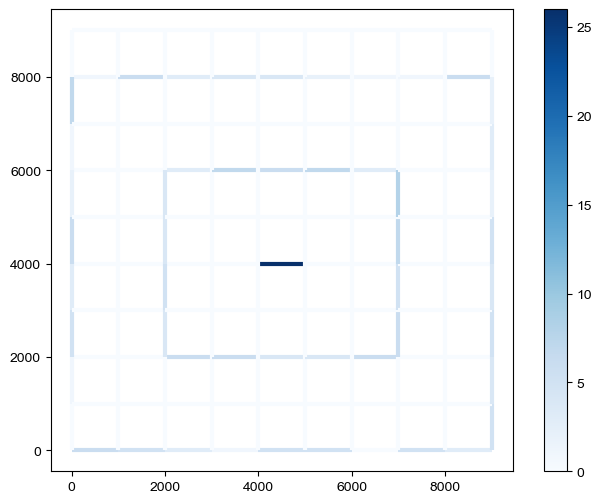

In [197]:
mean_collab_links_outside.plot(column='total_collab_count',
                                        cmap='Blues',
                                        legend=True,
                                        figsize=(8, 6),
                                        # title='Mean Collaborative Receivers per Link\n(Center - Clustered)',
                                        # edgecolor='k',
                                        linewidth=3)

f:\gitRepository\matsim-libs-2024\python\test\spatial_anls.py:467: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


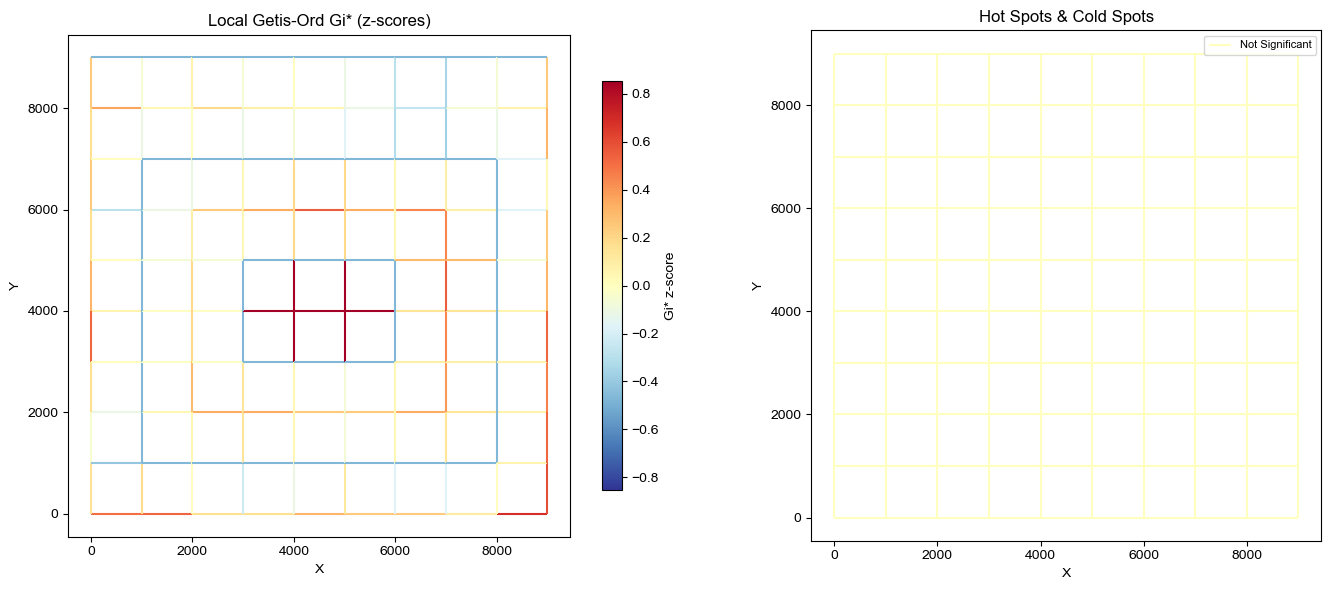


Getis-Ord Statistics Summary
Column analyzed: total_collab_count
Number of observations: 180
Weights type: queen

Global Getis-Ord G:
  G statistic: 0.031453
  Z-score: 0.2377
  P-value: 0.4061
  Interpretation: No significant global spatial clustering

Local Getis-Ord Gi*:
  Hot spots (z > 1.96): 0
  Cold spots (z < -1.96): 0



In [198]:
_result = spatial_anls.compute_getis_ord_statistics(
    mean_collab_links_outside, 
    col_name='total_collab_count',
    # weights_type='knn',
    # k_neighbors=5
    weights_type='queen',
    # distance_threshold=1500,
    # binary=True
)

f:\gitRepository\matsim-libs-2024\python\test\spatial_anls.py:467: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


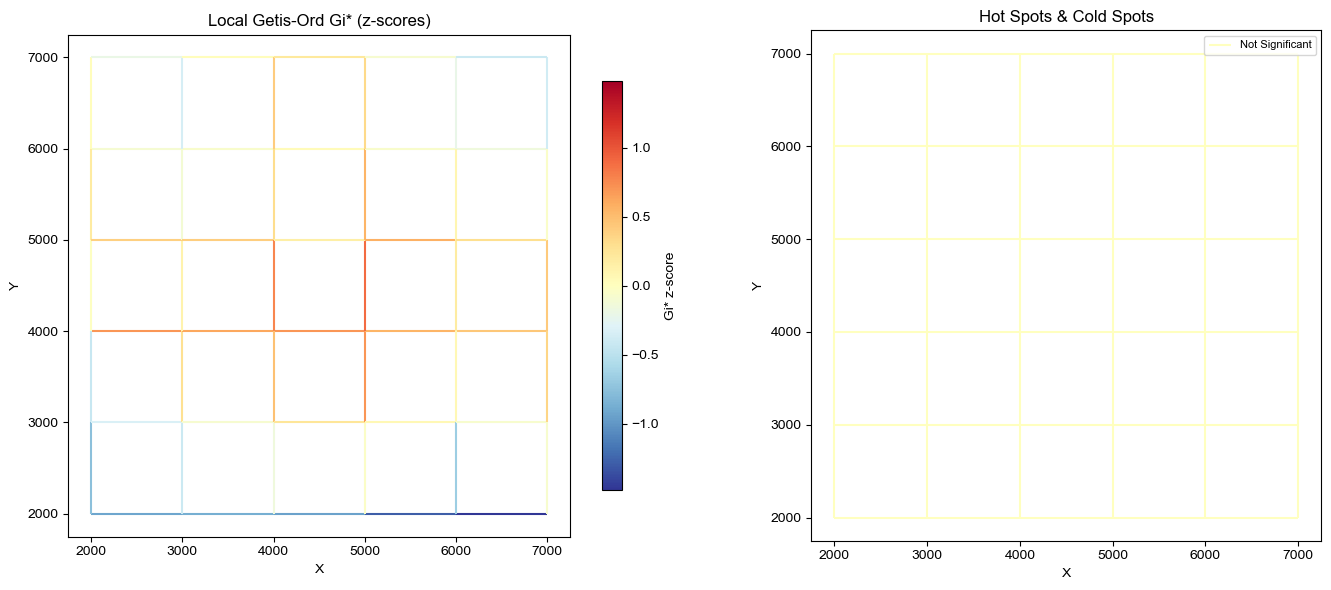


Getis-Ord Statistics Summary
Column analyzed: total_collab_count
Number of observations: 60
Weights type: queen

Global Getis-Ord G:
  G statistic: 0.090704
  Z-score: 2.8173
  P-value: 0.0024
  Interpretation: Significant clustering of HIGH values (hot spot clustering)

Local Getis-Ord Gi*:
  Hot spots (z > 1.96): 0
  Cold spots (z < -1.96): 0



{'global_G': 0.0907036567587681,
 'global_G_z': 2.8173205036633817,
 'global_G_p': 0.0024213087226860885,
 'global_interpretation': 'Significant clustering of HIGH values (hot spot clustering)',
 'local_Gi_star': array([0.00967742, 0.01096774, 0.02193548, 0.01341935, 0.01651613,
        0.01591398, 0.01806452, 0.01677419, 0.01006452, 0.01354839,
        0.01419355, 0.01880184, 0.02138249, 0.01751152, 0.01956989,
        0.01585253, 0.0162212 , 0.01397849, 0.01516129, 0.00954839,
        0.01603687, 0.01548387, 0.02193548, 0.0202765 , 0.0197235 ,
        0.02248848, 0.01695853, 0.01898618, 0.01677419, 0.01978495,
        0.00696774, 0.01634409, 0.01843318, 0.02193548, 0.02082949,
        0.02341014, 0.01788018, 0.02082949, 0.0162212 , 0.01913978,
        0.01832258, 0.00548387, 0.01714286, 0.0116129 , 0.02      ,
        0.01714286, 0.02101382, 0.01806452, 0.01548387, 0.01732719,
        0.016     , 0.01505376, 0.01612903, 0.01612903, 0.01935484,
        0.01987097, 0.01892473, 0.016258

In [177]:
spatial_anls.compute_getis_ord_statistics(
    mean_collab_links_center, 
    col_name='total_collab_count',
    # weights_type='knn',
    # k_neighbors=5
    weights_type='queen',
    # distance_threshold=1500,
    # binary=True
)

f:\gitRepository\matsim-libs-2024\python\test\spatial_anls.py:893: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning


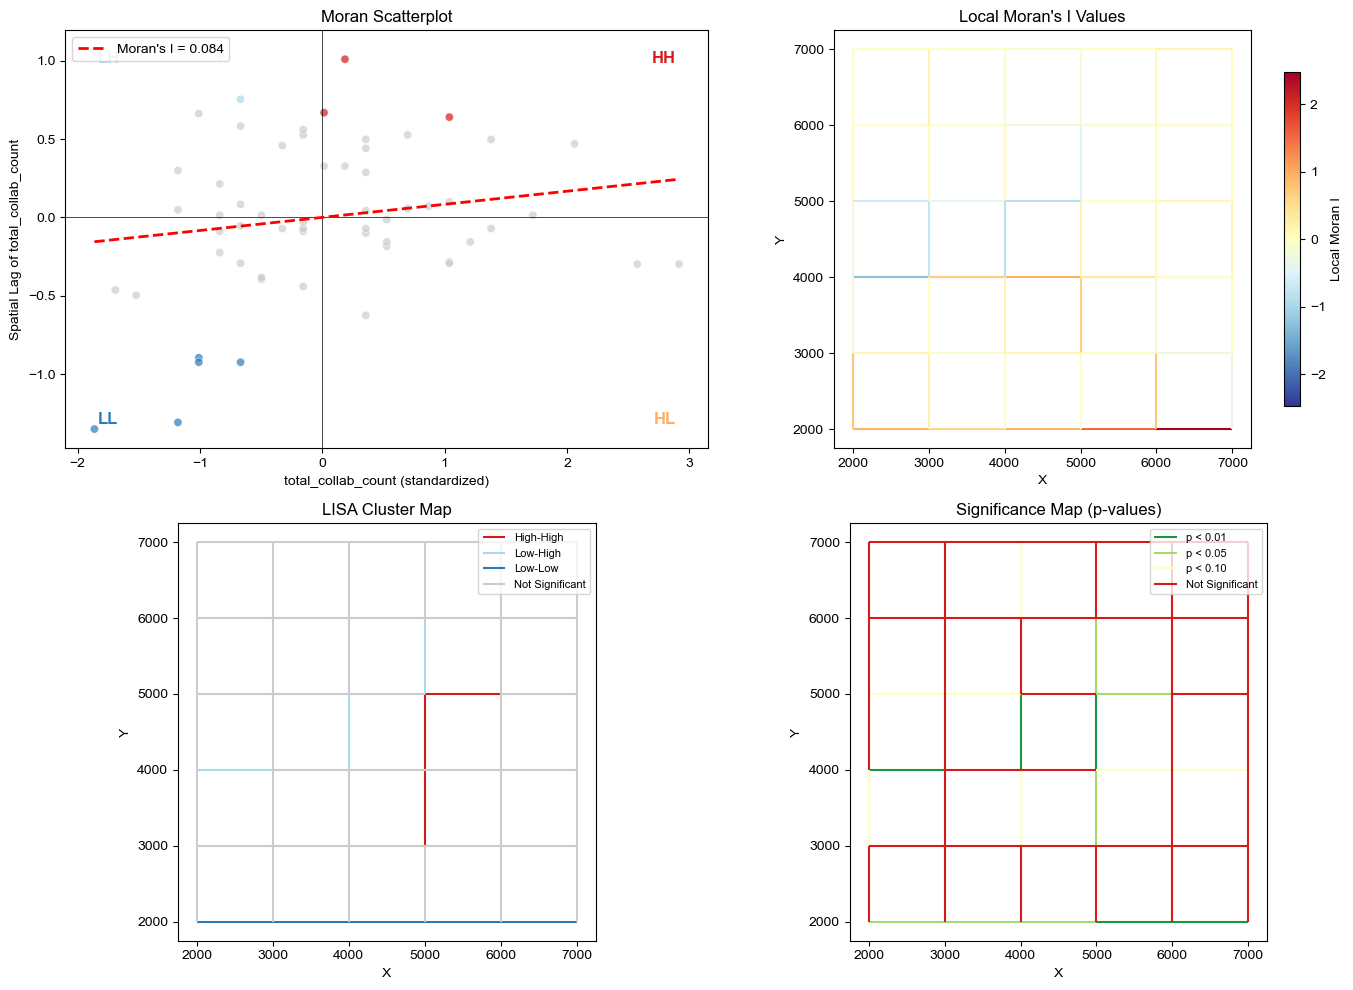


Moran's I Statistics Summary
Column analyzed: total_collab_count
Number of observations: 60
Weights type: queen

Global Moran's I:
  I statistic: 0.083515
  Expected I: -0.016949
  Z-score: 1.1819
  P-value: 0.1260
  Interpretation: No significant spatial autocorrelation (random pattern)

Local Moran's I (LISA) - Significant clusters:
  High-High (HH): 3
  Low-Low (LL): 5
  High-Low (HL): 0
  Low-High (LH): 3
  Not Significant: 49



In [182]:
result_moran_ = spatial_anls.compute_moran_statistics(
    mean_collab_links_center,
     weights_type='queen', 
    col_name='total_collab_count'
)

f:\gitRepository\matsim-libs-2024\python\test\spatial_anls.py:893: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning


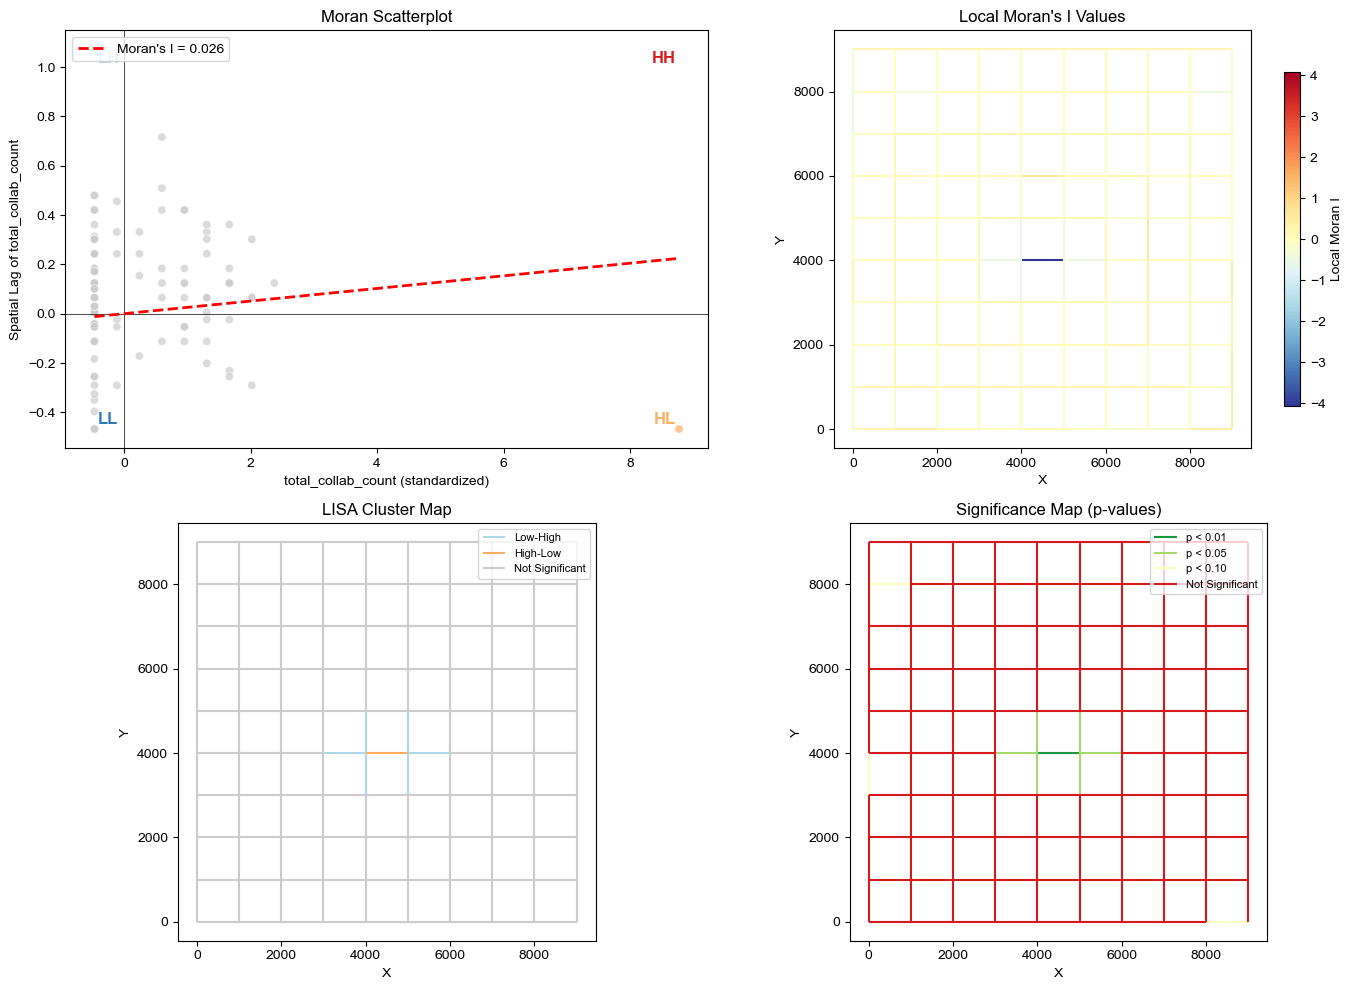


Moran's I Statistics Summary
Column analyzed: total_collab_count
Number of observations: 180
Weights type: queen

Global Moran's I:
  I statistic: 0.025599
  Expected I: -0.005587
  Z-score: 0.7229
  P-value: 0.2200
  Interpretation: No significant spatial autocorrelation (random pattern)

Local Moran's I (LISA) - Significant clusters:
  High-High (HH): 0
  Low-Low (LL): 0
  High-Low (HL): 1
  Low-High (LH): 6
  Not Significant: 173



In [199]:
result_moran_ = spatial_anls.compute_moran_statistics(
    mean_collab_links_outside,
     weights_type='queen', 
    col_name='total_collab_count'
)

### Map and locations

In [231]:
_sel_ins = 45
dispersed_ins_receiver_df = gpd.read_file(os.path.join(
    DISPERSED_OUTPUT_PATH, 
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.DISPERSED.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_sel_ins:02d}',
    'geo_data.geojson'))
clustered_ins_receiver_df = gpd.read_file(os.path.join(
    OUTPUT_PATH,
    f'{DepotLocation.OUTSIDE.value}-{ReceiverDistribution.CLUSTERED.value}-af{ALLOCATION_FACTOR:.02f}-p{0.0056}-i{_sel_ins:02d}',
    'geo_data.geojson'))

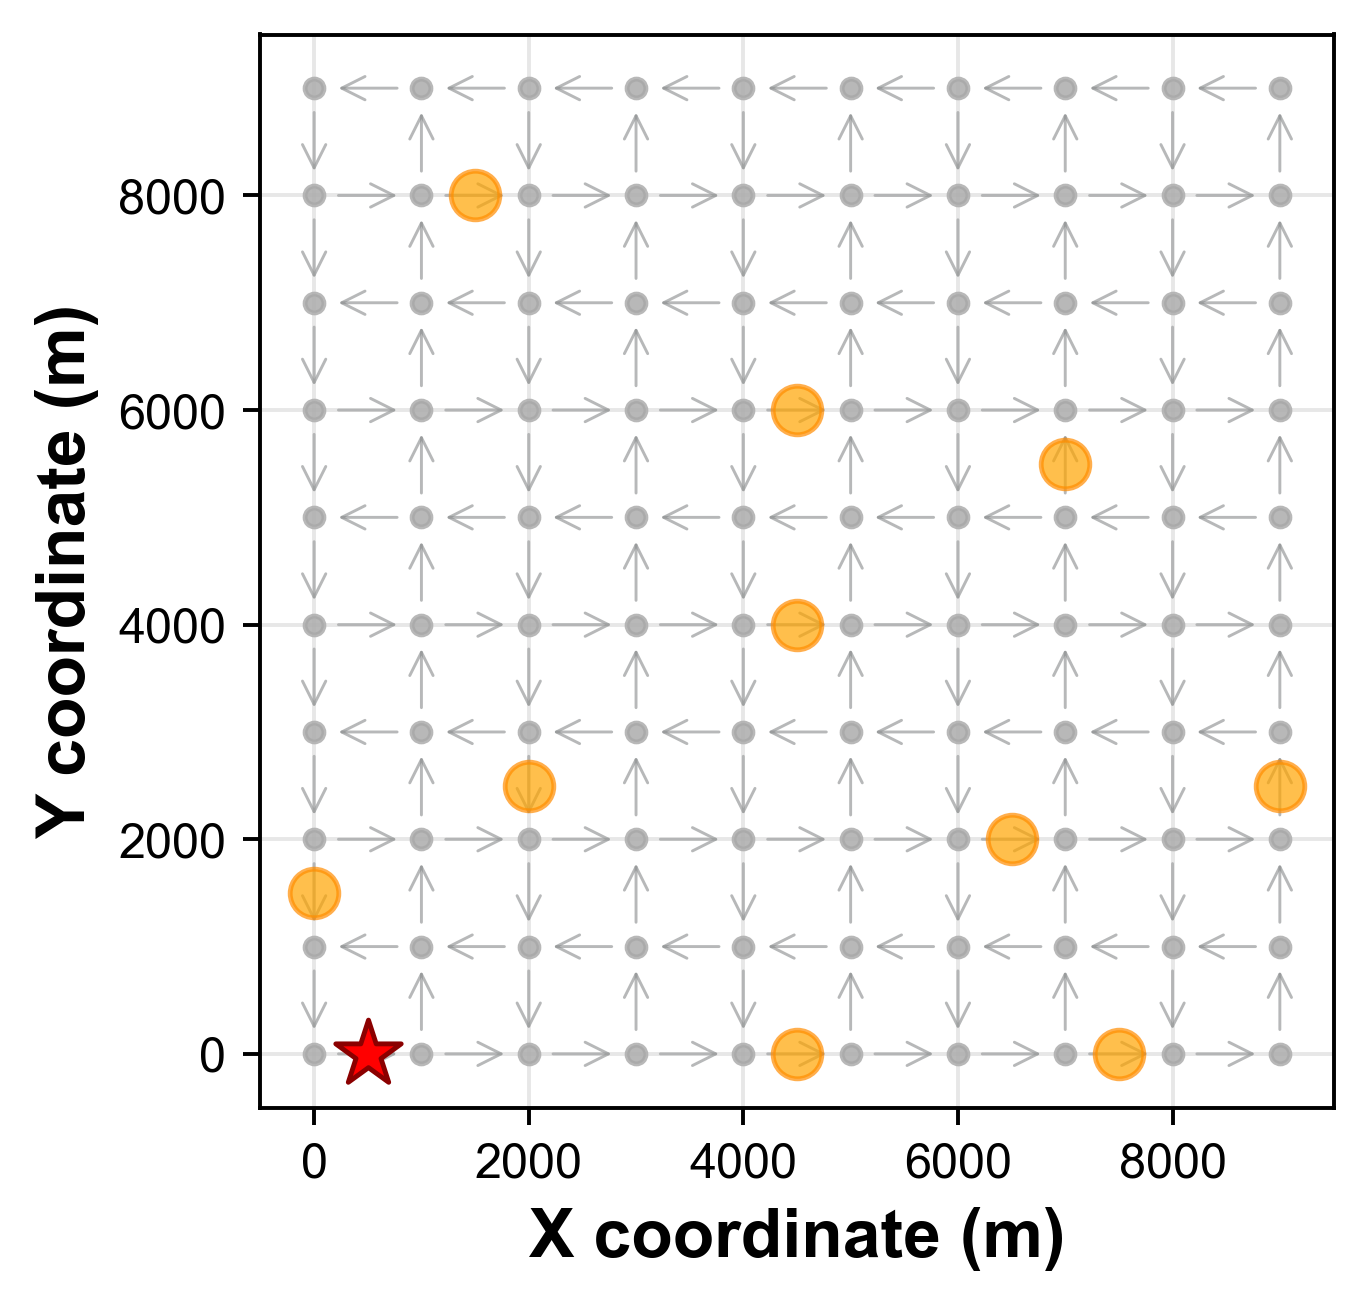

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [232]:
''' Plot the dispersed scenario receiver locations at link midpoints '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=dispersed_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=False,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Dispersed)',
    figure_size=(4, 4),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_dispersed_outside_random_20euro.png'
)

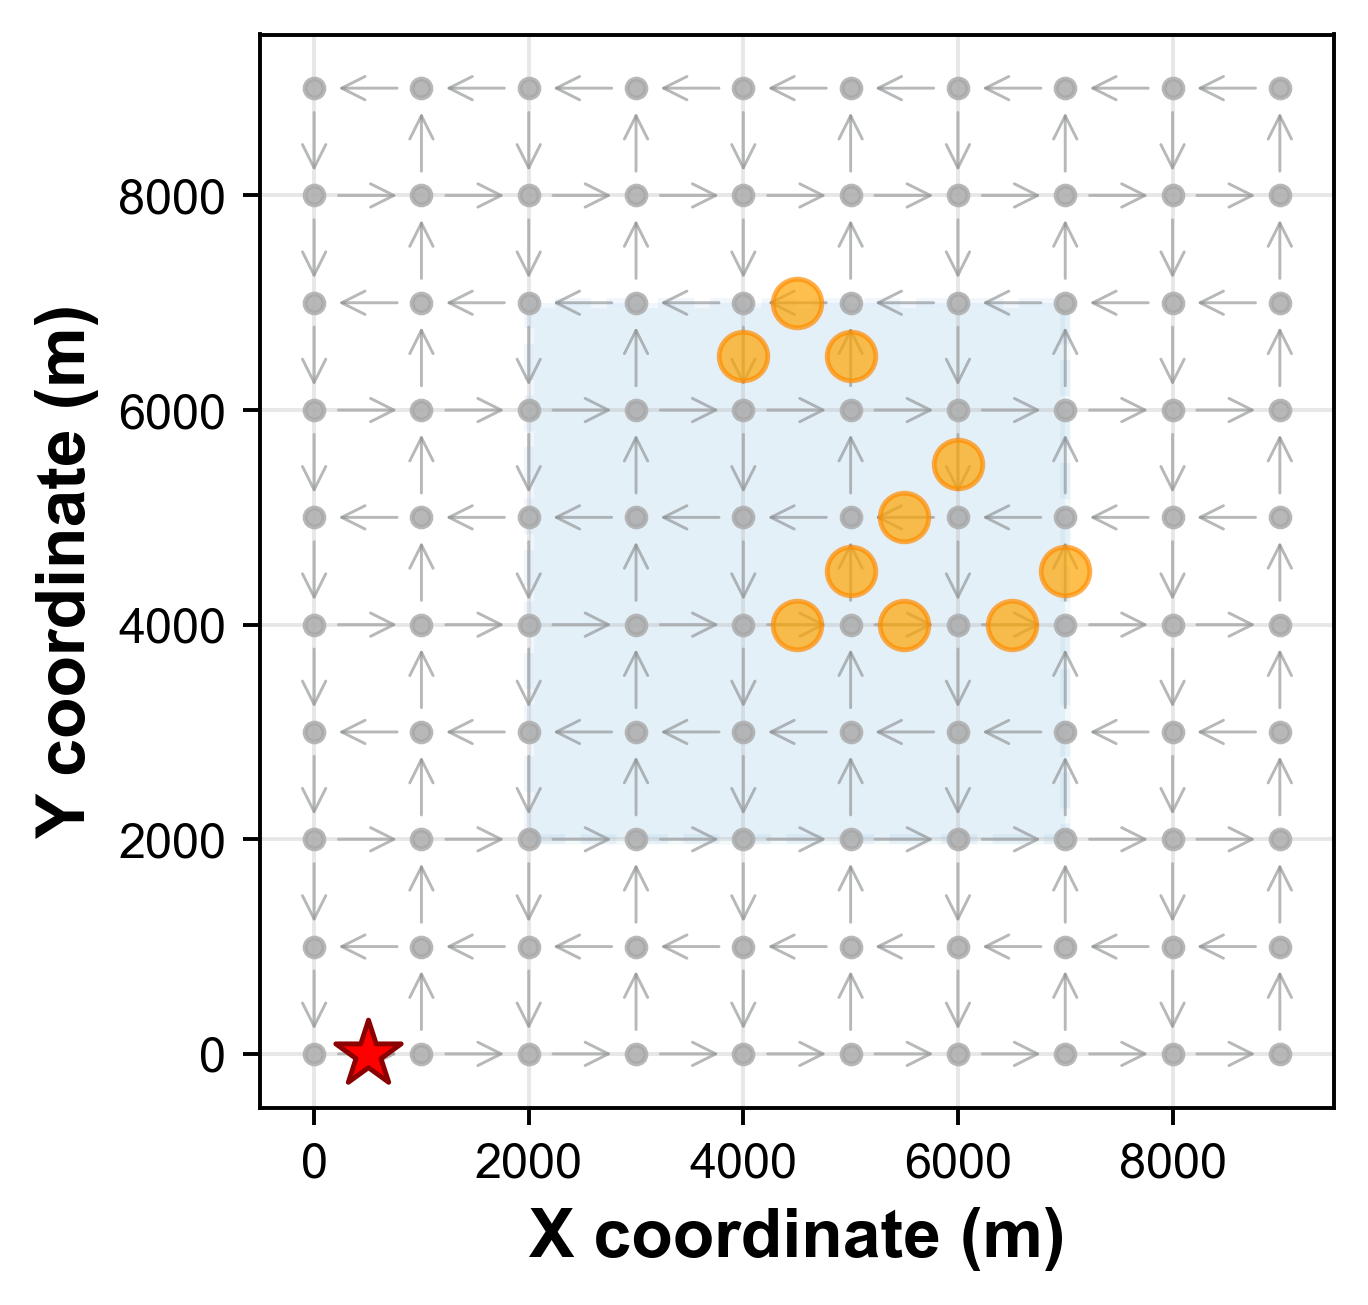

(<Figure size 1400x1400 with 1 Axes>,
 <Axes: xlabel='X coordinate (m)', ylabel='Y coordinate (m)'>)

In [233]:
''' Plot the clustered scenario receiver locations at link midpoints '''
figure_plot.network_locations_plot(
    network=network,
    locations_gdf=clustered_ins_receiver_df,
    # Links settings
    show_links=True,
    show_nodes=True,
    use_arrows=True,
    link_color="#878A8B",
    link_alpha=0.6,
    link_linewidth=0.6,
    arrow_scale=12,
    arrow_shrink=5,
    # Nodes settings
    node_size=15,
    node_color="#A7A7A7",
    node_alpha=0.8,
    # 使用link中点定位 (新功能)
    use_link_midpoint=True,
    link_id_col='link_id',
    # Central region
    show_central_region=True,
    central_region_bounds=(2000, 2000, 5000, 5000),
    central_region_label='Central Region (2000-7000)',
    #---X/Y labels---
    xlabel='X coordinate (m)',
    ylabel='Y coordinate (m)',
    label_size=14,

    # Axis limits
    xlim=(-500, 9500),
    ylim=(-500, 9500),
    #---Title and style---
    # title='Receiver Locations at Link Midpoints (Clustered)',
    figure_size=(4, 4),
    dpi=350,
    show_grid=True,
    show_legend=False,
    #---Output---
    figure_folder=OUTPUT_FIG_PATH,
    filename='receiver_locations_clustered_outside_random_20euro.png'
)

### Collaboration rate

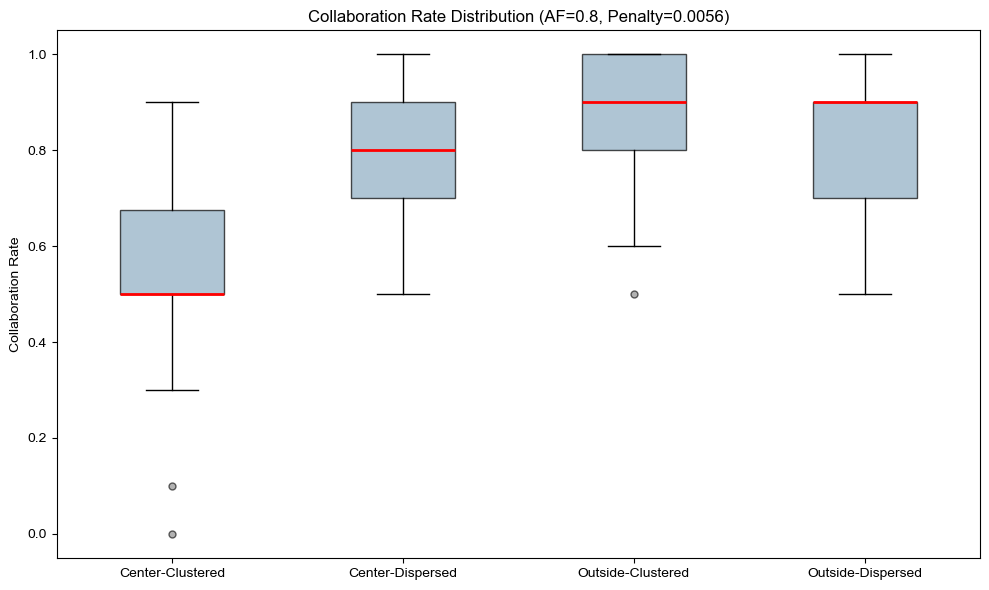

In [254]:
''' Box plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [ins_center_clustered_specific_anls_df['collaboration_rate'],
     ins_center_dispersed_specific_anls_df['collaboration_rate'],
     ins_outside_clustered_specific_anls_df['collaboration_rate'],
     ins_outside_dispersed_specific_anls_df['collaboration_rate']],
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)
ax.set_title(f'Collaboration Rate Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})')
ax.set_ylabel('Collaboration Rate')
plt.tight_layout()

plt.show()

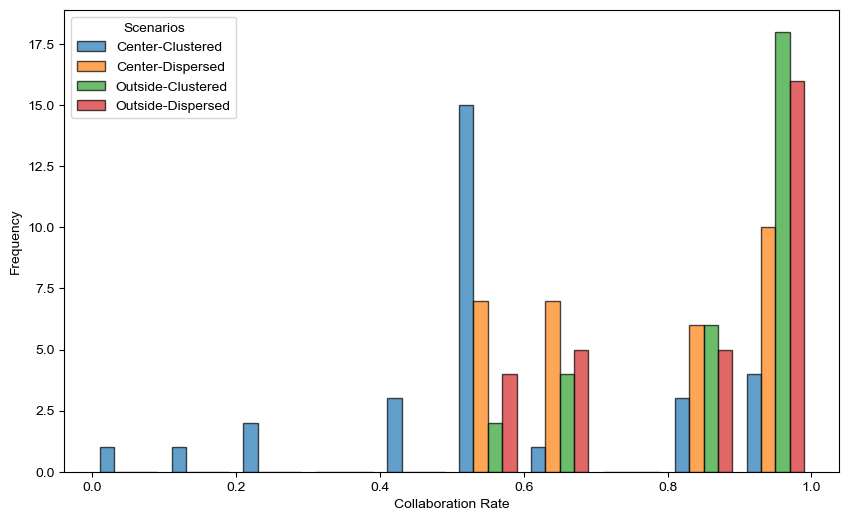

In [257]:
''' hist plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist([ins_center_clustered_specific_anls_df['collaboration_rate'],
         ins_center_dispersed_specific_anls_df['collaboration_rate'],
         ins_outside_clustered_specific_anls_df['collaboration_rate'],
         ins_outside_dispersed_specific_anls_df['collaboration_rate']],
        label=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
        alpha=0.7,
        bins=10,
        edgecolor='black')
ax.set_ylabel('Frequency')
ax.set_xlabel('Collaboration Rate')
ax.legend(title='Scenarios')
# plt.tight_layout()
plt.show()

It seems not necessary to compare VKT, TT and TKT, 
since the scenarios with the outside depot have way higher values than others.

### VKT

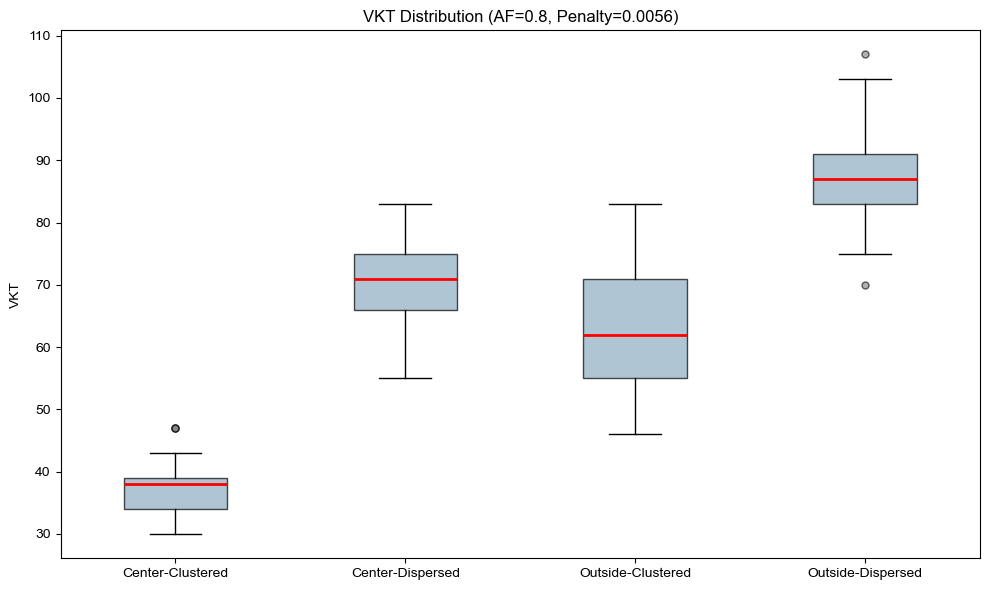

In [208]:
''' Box plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [ins_center_clustered_specific_anls_df['VKT_km'],
     ins_center_dispersed_specific_anls_df['VKT_km'],
     ins_outside_clustered_specific_anls_df['VKT_km'],
     ins_outside_dispersed_specific_anls_df['VKT_km']],
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)
ax.set_title(f'VKT Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})')
ax.set_ylabel('VKT')
plt.tight_layout()

plt.show()

### VTT

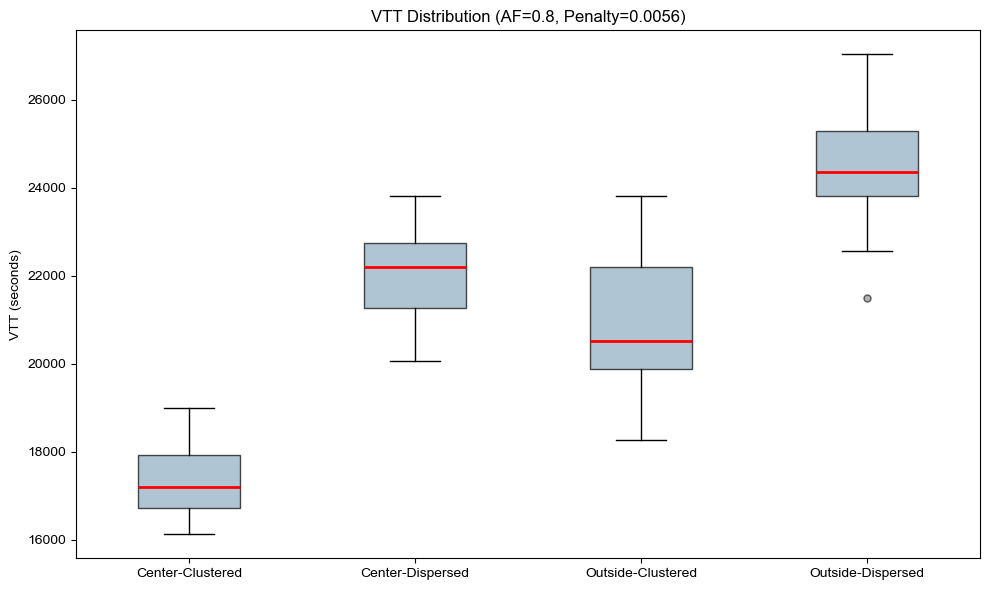

In [399]:
''' Box plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [ins_center_clustered_specific_anls_df['VTT_seconds'],
     ins_center_dispersed_specific_anls_df['VTT_seconds'],
     ins_outside_clustered_specific_anls_df['VTT_seconds'],
     ins_outside_dispersed_specific_anls_df['VTT_seconds']],
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)
ax.set_title(f'VTT Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})')
ax.set_ylabel('VTT (seconds)')
plt.tight_layout()

plt.show()

### TKT

In [175]:
ins_center_clustered_specific_anls_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
1240,center,CLUSTERED,0.8,0.0056,0,2,2,409.814400,316.8858,9,...,48.0,16132.0,20861.0,59000.0,46000.0,1.744697,3.0,0.941421,1.2,0.9
1241,center,CLUSTERED,0.8,0.0056,1,2,2,412.967480,334.0498,9,...,52.0,16668.0,20610.0,64000.0,47000.0,2.351147,4.6,0.841421,1.0,0.9
1242,center,CLUSTERED,0.8,0.0056,2,2,2,454.039741,374.0863,5,...,52.0,17204.0,19892.0,66500.0,39500.0,1.629127,2.5,0.741421,1.4,0.5
1243,center,CLUSTERED,0.8,0.0056,3,2,2,424.957485,351.1722,5,...,48.0,17204.0,19170.0,61500.0,45000.0,1.932033,2.8,1.000000,1.4,0.5
1244,center,CLUSTERED,0.8,0.0056,4,2,2,217.186960,218.8755,9,...,57.0,18458.0,22771.0,61000.0,46000.0,1.849190,2.8,0.941421,1.6,0.9
1245,center,CLUSTERED,0.8,0.0056,5,2,2,460.962750,386.3973,6,...,40.0,16308.0,17924.0,57500.0,43500.0,1.353663,2.9,0.600000,1.0,0.6
1246,center,CLUSTERED,0.8,0.0056,6,2,2,319.450760,354.9000,9,...,48.0,17923.0,20074.0,55000.0,47000.0,1.677927,3.0,1.041421,1.5,0.9
1247,center,CLUSTERED,0.8,0.0056,7,2,2,446.173326,347.0440,8,...,48.0,16667.0,20260.0,60500.0,40000.0,1.688363,2.6,0.523607,0.7,0.8
1248,center,CLUSTERED,0.8,0.0056,8,2,2,448.172960,364.8246,8,...,44.0,16668.0,19961.0,60000.0,36000.0,1.848528,2.4,0.600000,1.1,0.8
1249,center,CLUSTERED,0.8,0.0056,9,2,2,378.212437,354.8531,5,...,52.0,18644.0,19890.0,58000.0,42000.0,1.507107,2.4,0.641421,1.0,0.5


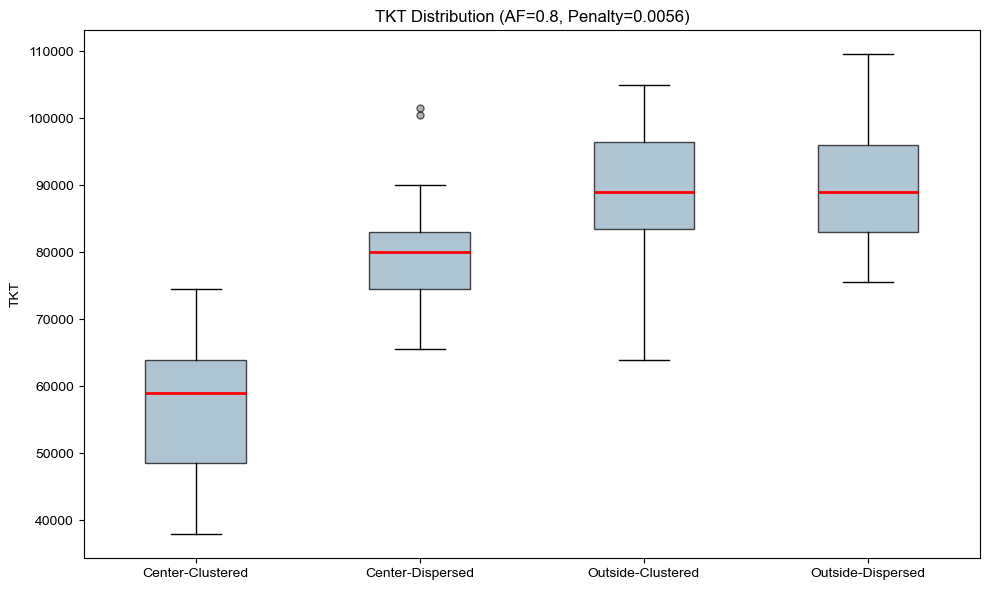

In [209]:
''' Box plot '''
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    [ins_center_clustered_specific_anls_df['TKT_tonkm'],
     ins_center_dispersed_specific_anls_df['TKT_tonkm'],
     ins_outside_clustered_specific_anls_df['TKT_tonkm'],
     ins_outside_dispersed_specific_anls_df['TKT_tonkm']],
    labels=['Center-Clustered', 'Center-Dispersed', 'Outside-Clustered', 'Outside-Dispersed'],
    patch_artist=True,
    boxprops=dict(facecolor='#8dadc3', color='black', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5, alpha=0.6)
)
ax.set_title(f'TKT Distribution (AF={specific_anls_af}, Penalty={specific_anls_penalty})')
ax.set_ylabel('TKT')
plt.tight_layout()

plt.show()

### Fleet size

In [261]:
ins_center_clustered_specific_anls_df

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
1140,center,CLUSTERED,0.8,0.0056,0,2,2,409.814400,316.8858,9,...,48.0,16132.0,20861.0,59000.0,46000.0,1.744697,3.0,0.941421,1.2,0.9
1141,center,CLUSTERED,0.8,0.0056,1,2,2,412.967480,334.0498,9,...,52.0,16668.0,20610.0,64000.0,47000.0,2.351147,4.6,0.841421,1.0,0.9
1142,center,CLUSTERED,0.8,0.0056,2,2,2,454.039741,374.0863,5,...,52.0,17204.0,19892.0,66500.0,39500.0,1.629127,2.5,0.741421,1.4,0.5
1143,center,CLUSTERED,0.8,0.0056,3,2,2,424.957485,351.1722,5,...,48.0,17204.0,19170.0,61500.0,45000.0,1.932033,2.8,1.000000,1.4,0.5
1144,center,CLUSTERED,0.8,0.0056,4,2,2,217.186960,218.8755,9,...,57.0,18458.0,22771.0,61000.0,46000.0,1.849190,2.8,0.941421,1.6,0.9
1145,center,CLUSTERED,0.8,0.0056,5,2,2,460.962750,386.3973,6,...,40.0,16308.0,17924.0,57500.0,43500.0,1.353663,2.9,0.600000,1.0,0.6
1146,center,CLUSTERED,0.8,0.0056,6,2,2,319.450760,354.9000,9,...,48.0,17923.0,20074.0,55000.0,47000.0,1.677927,3.0,1.041421,1.5,0.9
1147,center,CLUSTERED,0.8,0.0056,7,2,2,446.173326,347.0440,8,...,48.0,16667.0,20260.0,60500.0,40000.0,1.688363,2.6,0.523607,0.7,0.8
1148,center,CLUSTERED,0.8,0.0056,8,2,2,448.172960,364.8246,8,...,44.0,16668.0,19961.0,60000.0,36000.0,1.848528,2.4,0.600000,1.1,0.8
1149,center,CLUSTERED,0.8,0.0056,9,2,2,378.212437,354.8531,5,...,52.0,18644.0,19890.0,58000.0,42000.0,1.507107,2.4,0.641421,1.0,0.5


In [260]:
dispersed_shipment_metrics_df = agg_anls.aggregate_shipment_metrics_from_clean_folder(str(DISPERSED_OUTPUT_PATH), verbose=True)
dispersed_shipment_metrics_df

Found 3300 scenario folders in f:\gitRepository\matsim-libs-2024\data\freightChessboardRC\cleanMoreDispersed


Processing scenarios: 100%|██████████| 3300/3300 [00:11<00:00, 278.07it/s]


Processed 3300 scenarios successfully.


,depot_location,receiver_distribution,allocation_factor,penalty,instance_id,iter0_mean_delivery_deviation_min,final_mean_delivery_deviation_min,iter0_early_arrival_count,iter0_late_arrival_count,final_early_arrival_count,final_late_arrival_count,iter0_total_travel_distance_km,final_total_travel_distance_km,iter0_fleet_size,final_fleet_size
0,center,DISPERSED,0.5,0.000,0,-133.868333,-99.478333,0,0,0,0,111.0,191.0,5,2
1,center,DISPERSED,0.5,0.000,1,-134.091667,-85.398333,0,0,0,0,110.0,254.0,5,2
2,center,DISPERSED,0.5,0.000,2,-121.868333,-93.601667,0,0,0,0,111.0,177.0,5,3
3,center,DISPERSED,0.5,0.000,3,-115.645000,-75.885000,0,0,0,0,112.0,216.0,5,2
4,center,DISPERSED,0.5,0.000,4,-146.538333,-104.991667,0,0,0,1,108.0,220.0,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,left,DISPERSED,0.9,0.028,55,-12.945000,-12.945000,0,2,0,3,142.0,142.0,5,5
3296,left,DISPERSED,0.9,0.028,56,-15.450000,-14.955000,0,2,0,3,129.0,133.0,5,5
3297,left,DISPERSED,0.9,0.028,57,-15.401667,-15.200000,0,4,0,3,131.0,131.0,5,5
3298,left,DISPERSED,0.9,0.028,58,-18.463333,-11.381667,0,2,0,3,135.0,149.0,5,5


In [262]:
ins_center_clustered_specific_anls_df = pd.merge(
    ins_center_clustered_specific_anls_df,
    shipment_metrics_df[['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'final_fleet_size']],
    left_on=['instance', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    right_on=['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    how='left'
)

ins_outside_clustered_specific_anls_df = pd.merge(
    ins_outside_clustered_specific_anls_df,
    shipment_metrics_df[['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'final_fleet_size']],
    left_on=['instance', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    right_on=['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    how='left'
)

ins_outside_dispersed_specific_anls_df = pd.merge(
    ins_outside_dispersed_specific_anls_df,
    dispersed_shipment_metrics_df[['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'final_fleet_size']],
    left_on=['instance', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    right_on=['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    how='left'
)

ins_center_dispersed_specific_anls_df = pd.merge(
    ins_center_dispersed_specific_anls_df,
    shipment_metrics_df[['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty', 'final_fleet_size']],
    left_on=['instance', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    right_on=['instance_id', 'depot_location', 'receiver_distribution', 'allocation_factor', 'penalty'],
    how='left'
)

In [270]:
''' print the count of instances and the mean of each final fleet size for each scenario '''
ins_center_clustered_specific_anls_df.groupby('final_fleet_size').agg({'instance': 'count'})

,instance
final_fleet_size,
2,15
3,14
4,1


In [266]:
_fleet_size_df = pd.concat([
    ins_center_clustered_specific_anls_df,
    ins_center_dispersed_specific_anls_df,
    ins_outside_clustered_specific_anls_df,
    ins_outside_dispersed_specific_anls_df
], ignore_index=True)



In [286]:
ins_center_clustered_specific_anls_df.groupby('final_fleet_size').agg({'instance': 'count'})

,instance
final_fleet_size,
2,15
3,14
4,1


In [291]:
ins_outside_dispersed_specific_anls_df.groupby('final_fleet_size').agg({'instance': 'count'})

,instance
final_fleet_size,
2,1
3,29


In [294]:
ins_center_dispersed_specific_anls_df.groupby('final_fleet_size').agg({'instance': 'count'})

,instance
final_fleet_size,
2,6
3,23
5,1


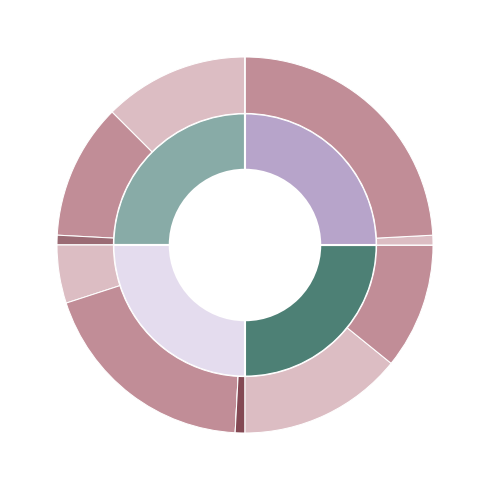

In [397]:
data_dict = {
    'Center-Clustered': ins_center_clustered_specific_anls_df,
    'Center-Dispersed': ins_center_dispersed_specific_anls_df,
    'Outside-Clustered': ins_outside_clustered_specific_anls_df,
    'Outside-Dispersed': ins_outside_dispersed_specific_anls_df
}

fig, ax = figure_plot.nested_donut_chart(
    data_dict,
    group_col='final_fleet_size',
    # title='Fleet Size Distribution by Scenario',
    inner_colors=["#88ABA7", "#ddd2e9c4", "#4d8075", "#b7a4ca"],
    outer_color_list=["#dcbdc3", "#c18d97", "#844954CF", "#844954"],
    outer_cmap='coolwarm',
    show_inner_labels=False,
    show_inner_pct=False,
    show_outer_count=False,
    show_outer_labels=False,
    hole_radius=0.4,
    inner_label_size=5,
    dpi=350,
    outer_label_size=10,
    figsize=(5, 5),
    show_legend=False,
    figure_folder=OUTPUT_FIG_PATH,
    filename='nested_donut_fleet_size_by_scenario.png',
     transparent_bg=True
)

### Spatial index
Relations: (mean-dist-to-depot; clustering index; ) <-> (VKT, TT, TKT, Cost savings, scores, etc)

## Penalty sensitivity

In [99]:
all_metrics_af80_df = all_metrics_df[
    (all_metrics_df['allocation_factor'] == 0.8)
]

all_metric_af80_dispersed_df = all_metrics_af80_df[
    (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

all_metrics_af80_clustered_df = all_metrics_af80_df[
    (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)
]

all_metric_af80_center_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.INSIDE.value)
]

all_metrics_af80_outside_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.OUTSIDE.value)
]

all_metrics_af80_center_dispersed_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.INSIDE.value
    ) & (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

all_metrics_af80_outside_dispersed_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.OUTSIDE.value
    ) & (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.DISPERSED.value)
]

all_metrics_af80_center_clustered_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.INSIDE.value
    ) & (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)  
]

all_metrics_af80_outside_clustered_df = all_metrics_af80_df[
    (all_metrics_af80_df['depot_location'] == DepotLocation.OUTSIDE.value
    ) & (all_metrics_af80_df['receiver_distribution'] == ReceiverDistribution.CLUSTERED.value)  
]


In [98]:
all_metrics_af80_center_clustered_df.groupby('penalty')['collaboration_rate'].mean()

penalty
0.0000    0.994
0.0003    0.994
0.0008    0.984
0.0014    0.976
0.0028    0.910
0.0056    0.544
0.0098    0.152
0.0140    0.062
0.0167    0.056
0.0222    0.036
0.0280    0.018
Name: collaboration_rate, dtype: float64

In [105]:
all_metrics_af80_center_dispersed_df.query("penalty == 0.0056")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
3110,center,DISPERSED,0.8,0.0056,0,2,2,377.205920,342.5509,5,...,52.0,18995.0,20622.0,56000.0,44000.0,2.160770,3.4,1.024264,1.9,0.5
3111,center,DISPERSED,0.8,0.0056,1,2,2,373.908559,320.5747,2,...,60.0,19884.0,21147.0,61500.0,50500.0,2.011312,3.1,1.206450,2.0,0.2
3112,center,DISPERSED,0.8,0.0056,2,2,2,272.032040,182.3877,9,...,69.0,18275.0,23171.0,78500.0,50500.0,1.977927,2.9,1.282843,2.2,0.9
3113,center,DISPERSED,0.8,0.0056,3,2,2,387.905049,339.2249,3,...,56.0,18635.0,20427.0,57500.0,46500.0,1.852076,3.5,1.224264,1.8,0.3
3114,center,DISPERSED,0.8,0.0056,4,2,2,388.437454,342.4844,5,...,56.0,17739.0,20068.0,67500.0,48500.0,1.952734,3.5,1.123607,2.1,0.5
3115,center,DISPERSED,0.8,0.0056,5,2,2,375.774750,349.5387,3,...,56.0,20068.0,20427.0,55500.0,46500.0,1.894155,3.5,1.182843,1.9,0.3
3116,center,DISPERSED,0.8,0.0056,6,2,2,313.997645,328.5423,7,...,60.0,17740.0,21323.0,67500.0,49500.0,1.955640,3.1,1.441421,2.0,0.7
3117,center,DISPERSED,0.8,0.0056,7,2,2,377.411080,322.5046,5,...,60.0,18995.0,21508.0,54000.0,46500.0,2.117104,3.3,0.882843,1.7,0.5
3118,center,DISPERSED,0.8,0.0056,8,2,2,374.495690,328.3385,6,...,60.0,19531.0,20833.0,61000.0,47500.0,1.977927,3.1,1.224264,2.0,0.6
3119,center,DISPERSED,0.8,0.0056,9,2,2,431.045150,366.5052,6,...,48.0,16668.0,19900.0,74500.0,44500.0,1.955640,4.1,1.307107,1.8,0.6


In [104]:
all_metrics_af80_center_dispersed_df.query("penalty == 0.0098")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
3160,center,DISPERSED,0.8,0.0098,0,2,2,334.765200,359.3406,0,...,52.0,20066.0,19530.0,46000.0,44000.0,2.160770,3.4,1.024264,1.9,0.0
3161,center,DISPERSED,0.8,0.0098,1,2,2,307.496400,333.2203,0,...,56.0,21162.0,20801.0,45000.0,47500.0,2.011312,3.1,1.206450,2.0,0.0
3162,center,DISPERSED,0.8,0.0098,2,2,2,155.409300,315.9827,0,...,64.0,25447.0,21323.0,52500.0,50500.0,1.977927,2.9,1.282843,2.2,0.0
3163,center,DISPERSED,0.8,0.0098,3,2,2,216.936370,329.9042,2,...,56.0,20970.0,20794.0,49500.0,47500.0,1.852076,3.5,1.224264,1.8,0.2
3164,center,DISPERSED,0.8,0.0098,4,2,2,372.556983,339.1924,2,...,60.0,18812.0,20658.0,59500.0,49500.0,1.952734,3.5,1.123607,2.1,0.2
3165,center,DISPERSED,0.8,0.0098,5,2,2,354.385671,322.8421,2,...,60.0,19172.0,21323.0,54500.0,44500.0,1.894155,3.5,1.182843,1.9,0.2
3166,center,DISPERSED,0.8,0.0098,6,2,2,369.624170,334.0387,2,...,60.0,19530.0,21193.0,56500.0,46500.0,1.955640,3.1,1.441421,2.0,0.2
3167,center,DISPERSED,0.8,0.0098,7,2,2,337.163500,318.5885,0,...,64.0,20197.0,21139.0,46500.0,48500.0,2.117104,3.3,0.882843,1.7,0.0
3168,center,DISPERSED,0.8,0.0098,8,2,2,347.389700,359.1555,0,...,56.0,20788.0,20429.0,47500.0,43500.0,1.977927,3.1,1.224264,2.0,0.0
3169,center,DISPERSED,0.8,0.0098,9,2,2,273.009673,356.8321,1,...,48.0,18633.0,19171.0,48500.0,45500.0,1.955640,4.1,1.307107,1.8,0.1


In [106]:
all_metrics_af80_center_dispersed_df.query("penalty == 0.014")

,depot_location,receiver_distribution,allocation_factor,penalty,instance,fleet_size,iter0_fleet_size,final_carrier_score,iter0_carrier_score,num_collaborative_receivers,...,iter0_VKT_km,VTT_seconds,iter0_VTT_seconds,TKT_tonkm,iter0_TKT_tonkm,mean_receiver_dist_to_depot_euclidean_km,mean_receiver_dist_to_depot_network_km,clustering_index_euclidean_km,clustering_index_network_km,collaboration_rate
3210,center,DISPERSED,0.8,0.014,0,2,2,357.711100,353.9635,0,...,52.0,20069.0,19890.0,43000.0,45000.0,2.160770,3.4,1.024264,1.9,0.0
3211,center,DISPERSED,0.8,0.014,1,2,2,320.482700,333.3675,0,...,56.0,21323.0,20787.0,47500.0,46500.0,2.011312,3.1,1.206450,2.0,0.0
3212,center,DISPERSED,0.8,0.014,2,2,2,219.766761,198.2450,1,...,73.0,22220.0,23528.0,51500.0,46500.0,1.977927,2.9,1.282843,2.2,0.1
3213,center,DISPERSED,0.8,0.014,3,2,2,332.286300,311.4494,0,...,56.0,20612.0,21146.0,45500.0,51500.0,1.852076,3.5,1.224264,1.8,0.0
3214,center,DISPERSED,0.8,0.014,4,2,2,348.338500,342.4844,0,...,56.0,20067.0,20068.0,47500.0,48500.0,1.952734,3.5,1.123607,2.1,0.0
3215,center,DISPERSED,0.8,0.014,5,2,2,344.892500,340.6984,0,...,60.0,20787.0,20658.0,47500.0,45500.0,1.894155,3.5,1.182843,1.9,0.0
3216,center,DISPERSED,0.8,0.014,6,2,2,357.068847,309.4746,2,...,60.0,19347.0,21690.0,51000.0,49500.0,1.955640,3.1,1.441421,2.0,0.2
3217,center,DISPERSED,0.8,0.014,7,2,2,342.367500,337.9078,0,...,56.0,20787.0,20786.0,48500.0,48500.0,2.117104,3.3,0.882843,1.7,0.0
3218,center,DISPERSED,0.8,0.014,8,2,2,338.457800,339.8232,0,...,60.0,20786.0,20834.0,47500.0,47500.0,1.977927,3.1,1.224264,2.0,0.0
3219,center,DISPERSED,0.8,0.014,9,2,2,356.832100,355.8010,0,...,52.0,19171.0,19540.0,45500.0,44500.0,1.955640,4.1,1.307107,1.8,0.0


In [ ]:
agg_metrics_center_random_df = agg_random_df_across_instances(all_metrics_center_random_df)
agg_metrics_outside_random_df = agg_random_df_across_instances(all_metrics_outside_random_df)

### collaboration rate

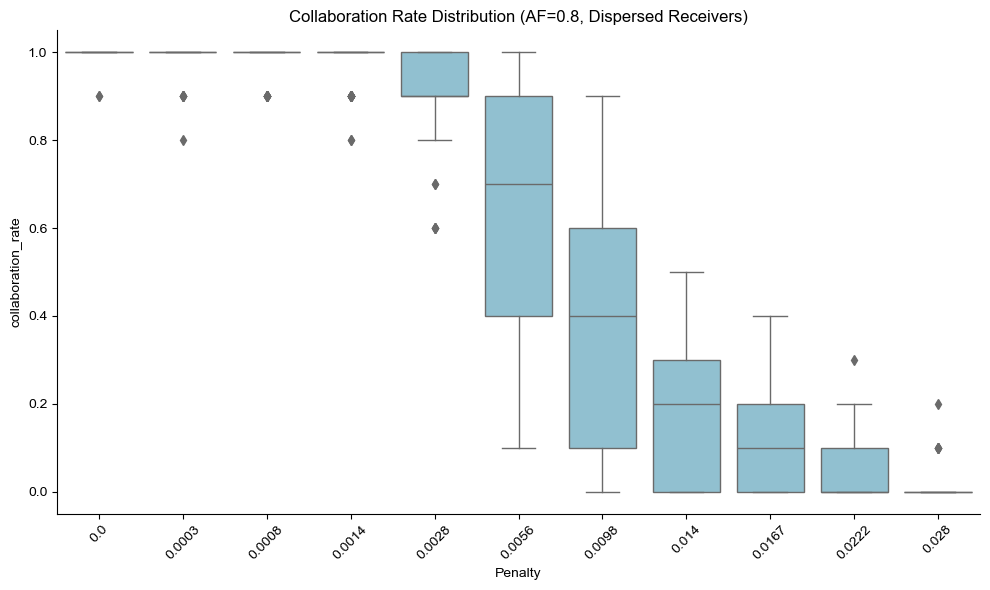

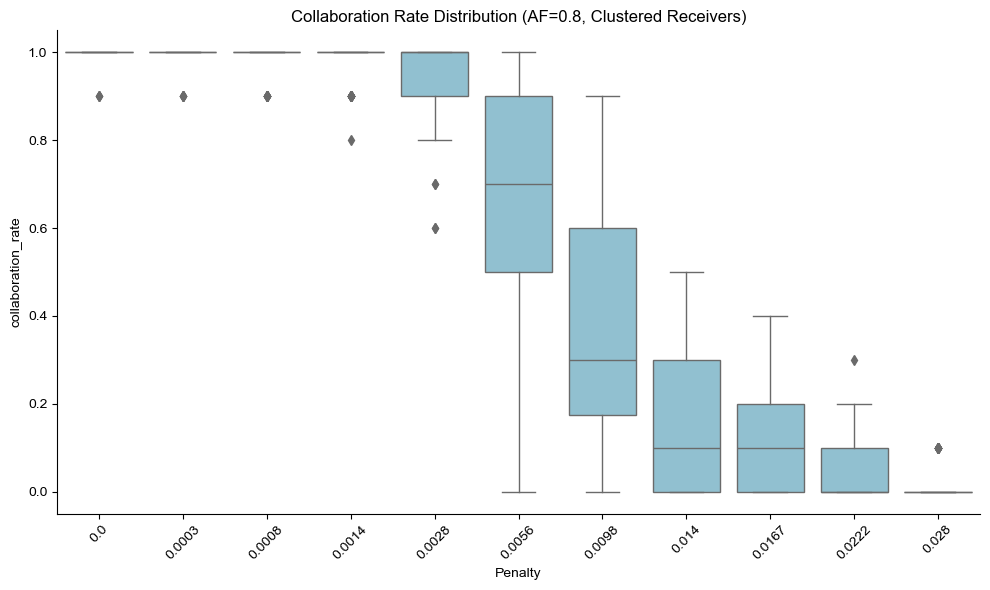

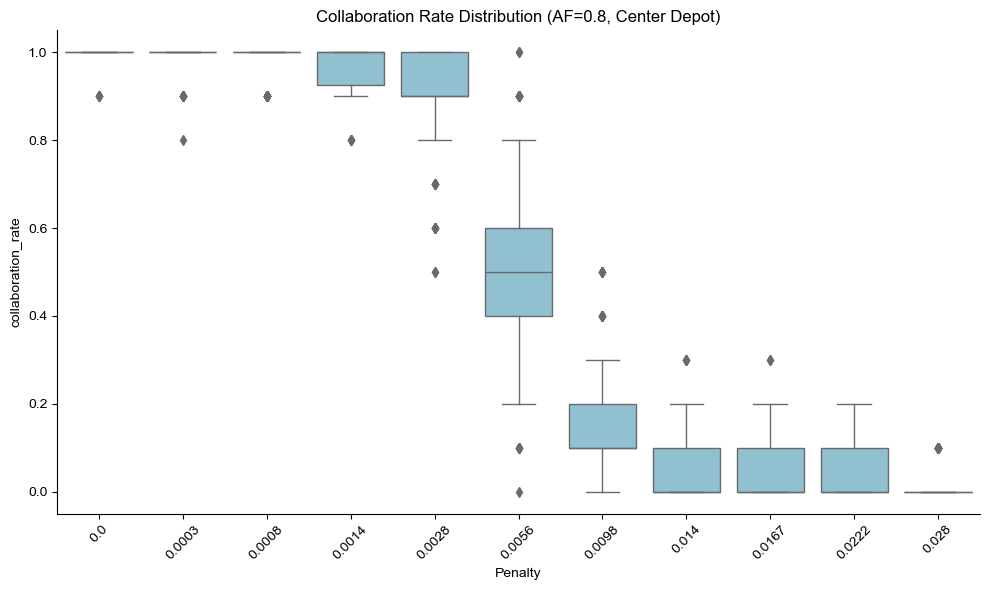

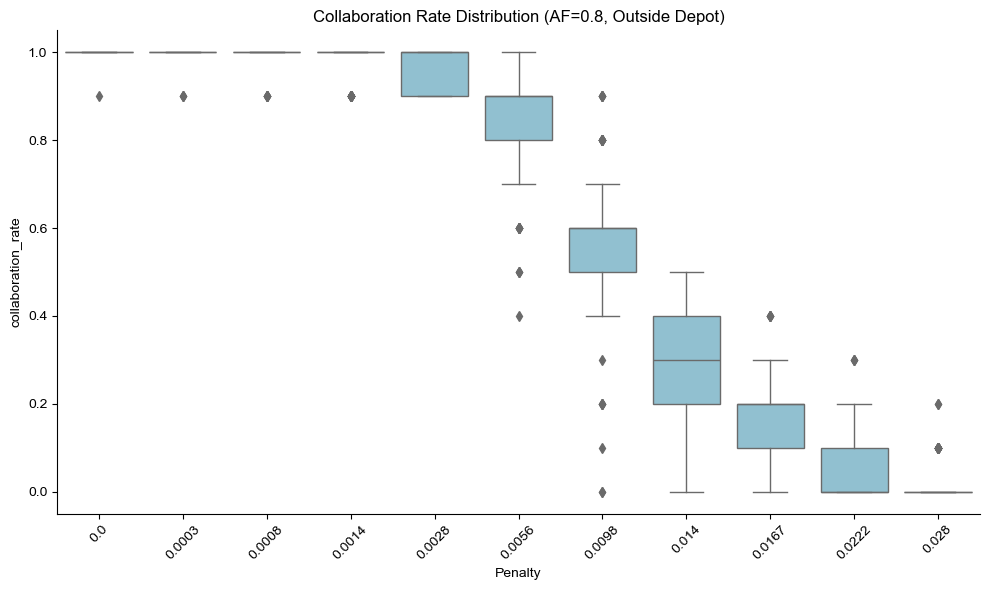

In [101]:
boxplot_metric(all_metric_af80_dispersed_df,
               metric='collaboration_rate',
               title='Collaboration Rate Distribution (AF=0.8, Dispersed Receivers)',
)

boxplot_metric(all_metrics_af80_clustered_df,
                metric='collaboration_rate',
                title='Collaboration Rate Distribution (AF=0.8, Clustered Receivers)',
    )   

boxplot_metric(all_metric_af80_center_df,
                metric='collaboration_rate',
                title='Collaboration Rate Distribution (AF=0.8, Center Depot)',
    )

boxplot_metric(all_metrics_af80_outside_df,
                metric='collaboration_rate',
                title='Collaboration Rate Distribution (AF=0.8, Outside Depot)',
    )

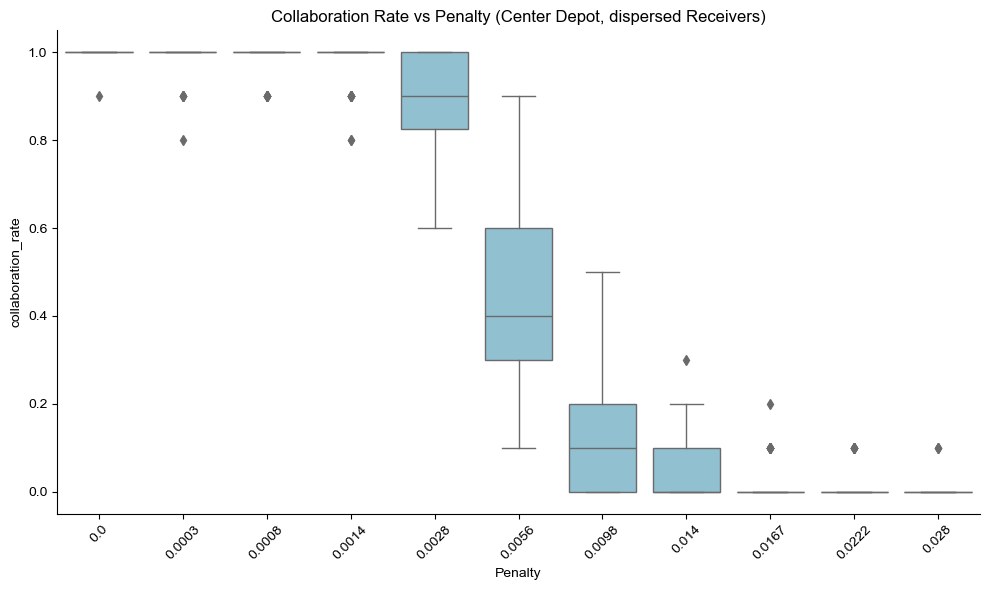

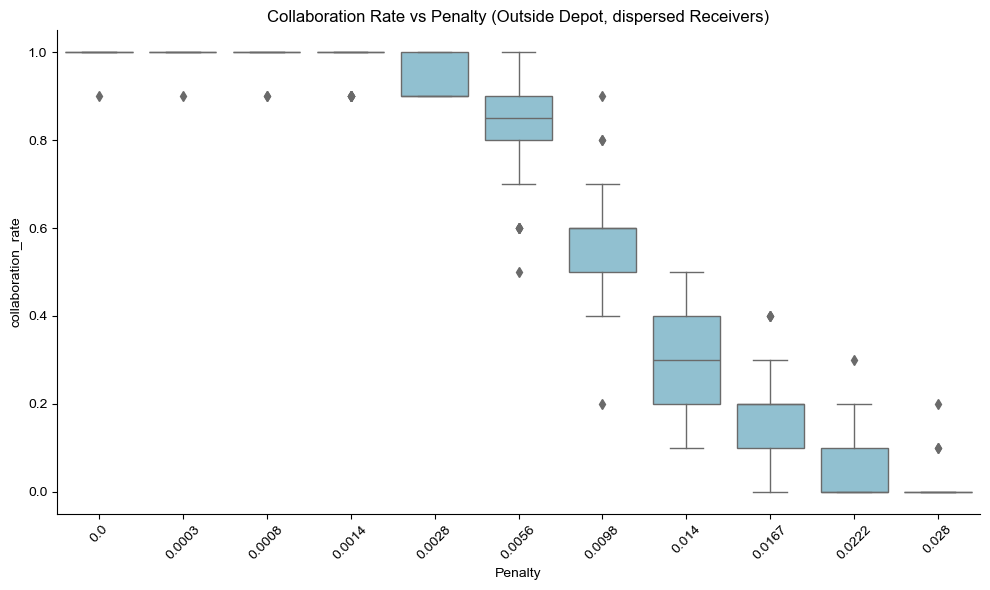

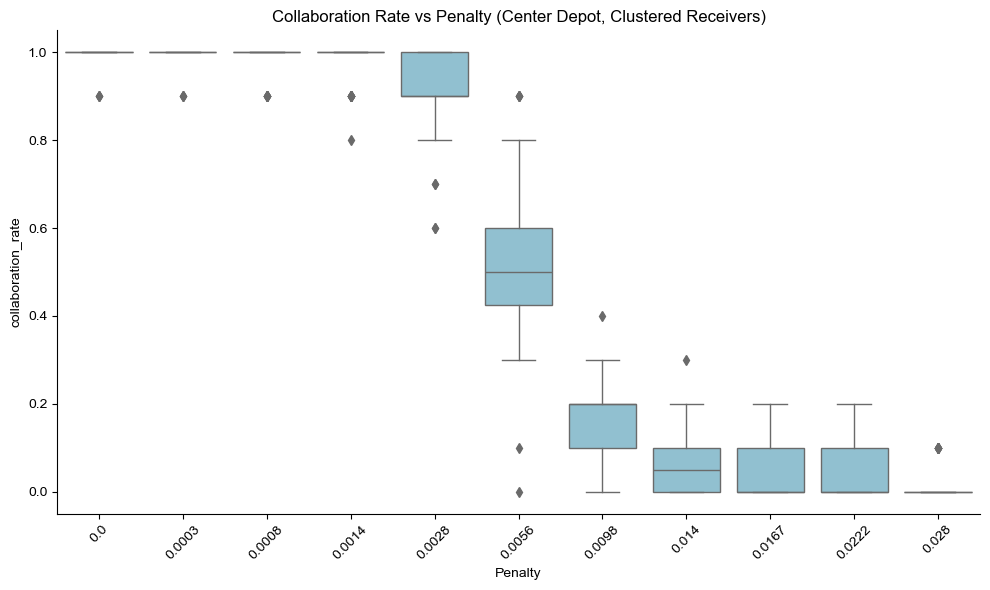

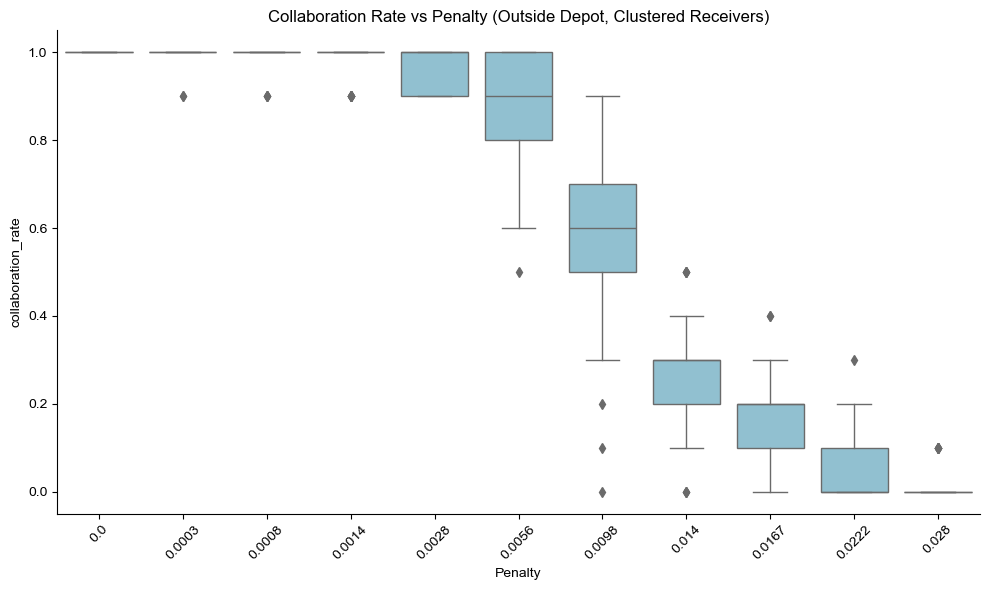

In [96]:
boxplot_metric(all_metrics_af80_center_dispersed_df ,
               metric='collaboration_rate',
               title='Collaboration Rate vs Penalty (Center Depot, dispersed Receivers)',  
               compare_iter0=False)
boxplot_metric(all_metrics_af80_outside_dispersed_df,
               metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, dispersed Receivers)',
                compare_iter0=False)
boxplot_metric(all_metrics_af80_center_clustered_df,
               metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Center Depot, Clustered Receivers)',
                compare_iter0=False)
boxplot_metric(all_metrics_af80_outside_clustered_df,
               metric='collaboration_rate',
                title='Collaboration Rate vs Penalty (Outside Depot, Clustered Receivers)',
                compare_iter0=False)


In [ ]:
# boxplot_metric(shrink_group_variance(all_metrics_center_random_df,
#                                      group_col='penalty',
#                                      value_col='collaboration_rate',
#                                      alpha=0.6,
#                                      center='median',
#                                      groups=[0.0003, 0.0008],
#                                      value_step=0.1),
#                metric='collaboration_rate',
#                title='Collaboration Rate vs Penalty (Center Depot, Random Receivers)',  
#                compare_iter0=False)
# boxplot_metric(shrink_group_variance(all_metrics_outside_random_df,
#                                      group_col='penalty',
#                                      value_col='collaboration_rate',
#                                      alpha=0.6,
#                                      center='median',
#                                      groups=[0.0003, 0.0008],
#                                      value_step=0.1),
#                metric='collaboration_rate',
#                 title='Collaboration Rate vs Penalty (Outside Depot, Random Receivers)',
#                 compare_iter0=False)

### VKT

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='VKT_km', 
               title='Total Freight VKT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='VKT_km', 
                title='Total Freight VKT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### VTT (travel time)

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='VTT_seconds', 
               title='Total Freight VTT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='VTT_seconds', 
                title='Total Freight VTT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Ton-km travelled (tkt)

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='TKT_tonkm', 
               title='Total Freight TKT (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='TKT_tonkm', 
                title='Total Freight TKT (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Fleet size

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='fleet_size', 
               title='Total Freight Fleet Size (Center Depot, Random Receivers)', 
               compare_iter0=True)
boxplot_metric(all_metrics_outside_random_df,
                metric='fleet_size', 
                title='Total Freight Fleet Size (Outside Depot, Random Receivers)', 
                compare_iter0=True)

### Carrier score

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='final_carrier_score', 
               title='Carrier Score (Center Depot, Random Receivers)', 
               iter0_metric='iter0_carrier_score')
boxplot_metric(all_metrics_outside_random_df,
                metric='final_carrier_score', 
                title='Carrier Score (Outside Depot, Random Receivers)', 
                iter0_metric='iter0_carrier_score')

### Receiver score

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='total_receiver_scores', 
               title='Total Freight Receiver Scores (Center Depot, Random Receivers)', 
               compare_iter0=False)
boxplot_metric(all_metrics_outside_random_df,
                metric='total_receiver_scores', 
                title='Total Freight Receiver Scores (Outside Depot, Random Receivers)', 
                compare_iter0=False)

### extended TWs

In [ ]:
boxplot_metric(all_metrics_center_random_df, 
               metric='total_extended_tw_hours', 
               title='Total Extended TW Hours (Center Depot, Random Receivers)', 
               compare_iter0=False)
boxplot_metric(all_metrics_outside_random_df,
                metric='total_extended_tw_hours', 
                title='Total Extended TW Hours (Outside Depot, Random Receivers)', 
                compare_iter0=False)

### Mean receiver distance to the depot
This should be set as the X , exporing the correlations with other variables (like collaboration rate, scores, etc.)

In [ ]:
scatter_3d(all_metrics_center_random_df,
           x_col='mean_receiver_dist_to_depot_euclidean_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='center-random-Mean receiver euclidean dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_center_random_df,
                      x_col='mean_receiver_dist_to_depot_euclidean_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='center-random-Mean receiver euclidean dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_center_random_df,
                   x_col='mean_receiver_dist_to_depot_euclidean_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high']
                   )

In [ ]:
scatter_3d(all_metrics_center_random_df,
           x_col='mean_receiver_dist_to_depot_network_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='center-random-Mean receiver nx dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_center_random_df,
                      x_col='mean_receiver_dist_to_depot_network_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='center-random-Mean receiver nx dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_center_random_df,
                   x_col='mean_receiver_dist_to_depot_network_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high'],
                    
                   )

In [ ]:
scatter_3d(all_metrics_outside_random_df,
           x_col='mean_receiver_dist_to_depot_network_km',
           y_col='collaboration_rate',
           z_col='penalty',
           color_col=None,
           title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
           )
scatter_color_encoded(all_metrics_outside_random_df,
                      x_col='mean_receiver_dist_to_depot_network_km',
                      y_col='collaboration_rate',
                      z_color_col='penalty',
                      title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
                      )
group_scatter_plot(all_metrics_outside_random_df,
                   x_col='mean_receiver_dist_to_depot_network_km',
                   y_col='collaboration_rate',
                   z_col='penalty',
                   group_of_z_col=[[0], [0.0003, 0.0008, 0.0014, 0.0028], [0.0056,
                        0.0098, 0.014], [0.0167, 0.0222, 0.028]],
                    group_labels=['None', 'low', 'medium', 'high'],
                    title='outside-random-Mean receiver nx dist to depot-collab rate-penalty'
                   )
basic_scatter_plot(all_metrics_outside_random_df,
                     x_col='mean_receiver_dist_to_depot_network_km',
                     y_col='collaboration_rate',
                    #  penalty_value=0.0056,
                     title='outside-random-Mean receiver nx dist to depot-collab rate at penalty=0.0056'
                     )

## Allocation sensitivity